In [1]:
# ============================================================
# CELDA 1: Importaciones y Configuración Global
# ============================================================

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from dataclasses import dataclass, field
from typing import Optional

warnings.filterwarnings("ignore")

# ── Configuración estética global ───────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 120, "figure.facecolor": "white"})

# ── Mapeo de etiquetas de actividad ─────────────────────────
ACTIVITY_MAP = {
    1:   "Walking",
    2:   "Running",
    3:   "Shuffling",
    4:   "Stairs (up)",
    5:   "Stairs (down)",
    6:   "Standing",
    7:   "Sitting",
    8:   "Lying",
    13:  "Cycling (sit)",
    14:  "Cycling (stand)",
    130: "Cycling (sit, inact.)",
    140: "Cycling (stand, inact.)"
}

# ── Columnas de señal por sensor ────────────────────────────
BACK_COLS  = ["back_x",  "back_y",  "back_z"]
THIGH_COLS = ["thigh_x", "thigh_y", "thigh_z"]
SIGNAL_COLS = BACK_COLS + THIGH_COLS
SAMPLING_RATE_HZ = 50

print("✔ Celda 1 ejecutada: importaciones y configuración cargadas.")

✔ Celda 1 ejecutada: importaciones y configuración cargadas.


In [2]:
# ============================================================
# CELDA 2: Clases Orientadas a Objetos para EDA
# ============================================================


@dataclass
class SubjectEDAResult:
    """
    Contenedor de resultados EDA para un único sujeto.
    Agrupa todas las métricas calculadas para facilitar
    el análisis posterior o la agregación entre sujetos.
    """
    subject_id:      str
    n_rows:          int
    n_cols:          int
    duration_sec:    float
    duration_min:    float
    missing_values:  pd.Series
    duplicate_rows:  int
    label_counts:    pd.Series
    label_pct:       pd.Series
    stats_summary:   pd.DataFrame
    neg_values:      pd.Series
    out_of_range:    pd.DataFrame
    timestamp_gaps:  pd.DataFrame
    has_timestamp:   bool


# ────────────────────────────────────────────────────────────
class SubjectEDA:
    """
    Realiza el análisis exploratorio completo de un único
    archivo CSV del dataset HARTH.

    Parámetros
    ----------
    filepath : str | Path
        Ruta al archivo CSV del sujeto.
    output_dir : str | Path
        Directorio donde se guardarán las figuras generadas.
    sampling_rate : int
        Frecuencia de muestreo en Hz (por defecto 50 Hz).
    """

    def __init__(
        self,
        filepath: str | Path,
        output_dir: str | Path = "eda_outputs",
        sampling_rate: int = SAMPLING_RATE_HZ,
    ):
        self.filepath      = Path(filepath)
        self.output_dir    = Path(output_dir)
        self.sampling_rate = sampling_rate
        self.subject_id    = self.filepath.stem          # e.g. "S006"
        self.df: Optional[pd.DataFrame] = None
        self.result: Optional[SubjectEDAResult] = None

        # Crear directorio de salida por sujeto
        self.subject_dir = self.output_dir / self.subject_id
        self.subject_dir.mkdir(parents=True, exist_ok=True)

    # ── Carga ────────────────────────────────────────────────
    def load(self) -> "SubjectEDA":
        """Carga el CSV y parsea el timestamp si existe."""
        self.df = pd.read_csv(self.filepath)
        if "timestamp" in self.df.columns:
            self.df["timestamp"] = pd.to_datetime(
                self.df["timestamp"], errors="coerce"
            )
        return self

    # ── Análisis de valores faltantes ────────────────────────
    def _check_missing(self) -> pd.Series:
        """Retorna conteo de nulos por columna."""
        return self.df.isnull().sum()

    # ── Análisis de duplicados ───────────────────────────────
    def _check_duplicates(self) -> int:
        """Retorna número de filas completamente duplicadas."""
        return int(self.df.duplicated().sum())

    # ── Duración de la sesión ────────────────────────────────
    def _compute_duration(self) -> tuple[float, float]:
        """
        Calcula la duración de la sesión en segundos y minutos
        usando el timestamp si está disponible; en caso contrario,
        estima a partir del conteo de filas y la frecuencia de muestreo.
        """
        if "timestamp" in self.df.columns and self.df["timestamp"].notna().any():
            delta = (
                self.df["timestamp"].dropna().iloc[-1]
                - self.df["timestamp"].dropna().iloc[0]
            ).total_seconds()
        else:
            delta = len(self.df) / self.sampling_rate
        return delta, delta / 60

    # ── Distribución de etiquetas ────────────────────────────
    def _label_distribution(self) -> tuple[pd.Series, pd.Series]:
        """Retorna conteos absolutos y porcentajes por actividad."""
        counts = self.df["label"].value_counts().sort_index()
        counts.index = counts.index.map(
            lambda x: ACTIVITY_MAP.get(int(x), f"Label {x}")
        )
        pct = (counts / counts.sum() * 100).round(2)
        return counts, pct

    # ── Estadísticas descriptivas de señales ─────────────────
    def _signal_stats(self) -> pd.DataFrame:
        """
        Retorna un DataFrame con estadísticas descriptivas
        (mean, std, min, max, skewness, kurtosis) para cada
        canal de acelerómetro.
        """
        available = [c for c in SIGNAL_COLS if c in self.df.columns]
        stats = self.df[available].agg(["mean", "std", "min", "max"])
        skew  = self.df[available].skew().rename("skewness")
        kurt  = self.df[available].kurt().rename("kurtosis")
        return pd.concat([stats, skew.to_frame().T, kurt.to_frame().T]).round(4)

    # ── Valores negativos y fuera de rango ───────────────────
    def _check_signal_quality(self) -> tuple[pd.Series, pd.DataFrame]:
        """
        Comprueba la calidad de la señal:
        - Valores negativos (válidos en acelerómetros, pero se documenta).
        - Valores fuera del rango típico ±8 g para Axivity AX3.
        """
        available = [c for c in SIGNAL_COLS if c in self.df.columns]
        neg_counts = (self.df[available] < 0).sum()

        threshold = 8.0
        out_rows = {}
        for col in available:
            mask = self.df[col].abs() > threshold
            out_rows[col] = int(mask.sum())
        out_df = pd.DataFrame.from_dict(
            out_rows, orient="index", columns=["rows_out_of_range_8g"]
        )
        return neg_counts, out_df

    # ── Gaps en el timestamp ─────────────────────────────────
    def _check_timestamp_gaps(self, threshold_ms: float = 25.0) -> pd.DataFrame:
        """
        Detecta saltos temporales mayores al umbral esperado
        entre muestras consecutivas (20 ms a 50 Hz).

        Parámetros
        ----------
        threshold_ms : float
            Umbral en milisegundos para considerar un gap anómalo.
        """
        if "timestamp" not in self.df.columns or self.df["timestamp"].isna().all():
            return pd.DataFrame(columns=["index", "gap_ms"])

        ts = self.df["timestamp"].dropna()
        diffs = ts.diff().dt.total_seconds() * 1000      # convertir a ms
        gaps  = diffs[diffs > threshold_ms].reset_index()
        gaps.columns = ["index", "gap_ms"]
        gaps["gap_ms"] = gaps["gap_ms"].round(3)
        return gaps

    # ── Generación de figuras ────────────────────────────────
    def _plot_label_distribution(self) -> None:
        """Guarda un gráfico de barras con la distribución de etiquetas."""
        counts, pct = self.result.label_counts, self.result.label_pct
        fig, ax = plt.subplots(figsize=(10, 5))
        bars = ax.barh(counts.index, counts.values, color=sns.color_palette("muted"))
        ax.set_xlabel("Número de muestras")
        ax.set_title(f"{self.subject_id} — Distribución de actividades")
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(
            lambda x, _: f"{int(x):,}"
        ))
        for bar, p in zip(bars, pct.values):
            ax.text(
                bar.get_width() + counts.max() * 0.01,
                bar.get_y() + bar.get_height() / 2,
                f"{p:.1f}%", va="center", fontsize=9
            )
        plt.tight_layout()
        fig.savefig(self.subject_dir / "label_distribution.png")
        plt.close(fig)

    def _plot_signal_overview(self, n_seconds: int = 30) -> None:
        """
        Guarda un gráfico de las señales de ambos sensores
        durante los primeros `n_seconds` segundos de la sesión.
        """
        n_samples = n_seconds * self.sampling_rate
        subset = self.df.head(n_samples)
        time_axis = np.arange(len(subset)) / self.sampling_rate

        fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
        sensor_pairs = [
            (BACK_COLS,  "Sensor: Espalda (back)",  axes[0]),
            (THIGH_COLS, "Sensor: Muslo (thigh)",   axes[1]),
        ]
        for cols, title, ax in sensor_pairs:
            for col in cols:
                if col in subset.columns:
                    ax.plot(time_axis, subset[col], label=col, linewidth=0.8)
            ax.set_ylabel("Aceleración (g)")
            ax.set_title(title)
            ax.legend(loc="upper right", fontsize=8)

        axes[1].set_xlabel("Tiempo (s)")
        fig.suptitle(
            f"{self.subject_id} — Primeros {n_seconds}s de señal", fontsize=13
        )
        plt.tight_layout()
        fig.savefig(self.subject_dir / "signal_overview.png")
        plt.close(fig)

    def _plot_missing_heatmap(self) -> None:
        """
        Guarda un heatmap de valores nulos si existen;
        en caso contrario, guarda un aviso textual.
        """
        if self.result.missing_values.sum() == 0:
            fig, ax = plt.subplots(figsize=(6, 2))
            ax.text(
                0.5, 0.5,
                "✔ Sin valores nulos",
                ha="center", va="center",
                fontsize=14, color="green",
                transform=ax.transAxes
            )
            ax.axis("off")
            ax.set_title(f"{self.subject_id} — Análisis de nulos")
        else:
            fig, ax = plt.subplots(figsize=(10, 4))
            sns.heatmap(
                self.df.isnull(),
                cbar=False, yticklabels=False,
                cmap="viridis", ax=ax
            )
            ax.set_title(f"{self.subject_id} — Mapa de valores nulos")
        plt.tight_layout()
        fig.savefig(self.subject_dir / "missing_heatmap.png")
        plt.close(fig)

    def _plot_boxplots(self) -> None:
        """Guarda boxplots de cada canal para detectar outliers."""
        available = [c for c in SIGNAL_COLS if c in self.df.columns]
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        for ax, (cols, title) in zip(
            axes,
            [(BACK_COLS, "Espalda (back)"), (THIGH_COLS, "Muslo (thigh)")]
        ):
            data = [self.df[c].dropna().values for c in cols if c in self.df.columns]
            ax.boxplot(data, labels=[c for c in cols if c in self.df.columns],
                       patch_artist=True, notch=False)
            ax.set_ylabel("Aceleración (g)")
            ax.set_title(f"{self.subject_id} — Boxplot: {title}")
            ax.axhline(0, color="red", linestyle="--", linewidth=0.8, alpha=0.6)
        plt.tight_layout()
        fig.savefig(self.subject_dir / "boxplots.png")
        plt.close(fig)

    # ── Pipeline completo ────────────────────────────────────
    def run(self, verbose: bool = True) -> SubjectEDAResult:
        """
        Ejecuta el pipeline EDA completo y almacena el resultado
        en `self.result`. Genera todas las figuras y el reporte
        de texto para el sujeto.

        Parámetros
        ----------
        verbose : bool
            Si True, imprime el resumen en consola (ideal para Jupyter).
        """
        if self.df is None:
            self.load()

        # ── Cálculos ─────────────────────────────────────────
        missing      = self._check_missing()
        duplicates   = self._check_duplicates()
        dur_s, dur_m = self._compute_duration()
        counts, pct  = self._label_distribution()
        stats        = self._signal_stats()
        neg, oor     = self._check_signal_quality()
        ts_gaps      = self._check_timestamp_gaps()
        has_ts       = "timestamp" in self.df.columns

        self.result = SubjectEDAResult(
            subject_id     = self.subject_id,
            n_rows         = len(self.df),
            n_cols         = self.df.shape[1],
            duration_sec   = round(dur_s, 2),
            duration_min   = round(dur_m, 2),
            missing_values = missing,
            duplicate_rows = duplicates,
            label_counts   = counts,
            label_pct      = pct,
            stats_summary  = stats,
            neg_values     = neg,
            out_of_range   = oor,
            timestamp_gaps = ts_gaps,
            has_timestamp  = has_ts,
        )

        # ── Visualizaciones ───────────────────────────────────
        self._plot_label_distribution()
        self._plot_signal_overview()
        self._plot_missing_heatmap()
        self._plot_boxplots()

        # ── Reporte en texto ──────────────────────────────────
        self._save_text_report()

        if verbose:
            self._print_summary()

        return self.result

    # ── Reporte de texto ─────────────────────────────────────
    def _save_text_report(self) -> None:
        """Guarda un archivo .txt con el reporte EDA del sujeto."""
        r = self.result
        lines = [
            "=" * 60,
            f"  REPORTE EDA — {r.subject_id}",
            "=" * 60,
            f"  Filas totales     : {r.n_rows:,}",
            f"  Columnas          : {r.n_cols}",
            f"  Duración          : {r.duration_sec:,.1f} s  "
            f"({r.duration_min:.1f} min)",
            f"  Filas duplicadas  : {r.duplicate_rows}",
            "",
            "── Valores faltantes por columna ──────────────────",
            r.missing_values.to_string(),
            "",
            "── Distribución de actividades ────────────────────",
        ]
        for act, cnt in r.label_counts.items():
            lines.append(f"  {act:<25} {cnt:>8,}  ({r.label_pct[act]:.1f}%)")
        lines += [
            "",
            "── Estadísticas descriptivas de señales ───────────",
            r.stats_summary.to_string(),
            "",
            "── Valores fuera de rango ±8 g ────────────────────",
            r.out_of_range.to_string(),
            "",
            f"── Gaps temporales anómalos detectados: "
            f"{len(r.timestamp_gaps)} ──",
            r.timestamp_gaps.to_string() if len(r.timestamp_gaps) > 0
            else "  Ninguno detectado.",
            "=" * 60,
        ]
        report_path = self.subject_dir / "eda_report.txt"
        report_path.write_text("\n".join(lines), encoding="utf-8")

    # ── Impresión en consola ──────────────────────────────────
    def _print_summary(self) -> None:
        """Imprime un resumen visual del EDA en el notebook."""
        r = self.result
        print(f"\n{'=' * 60}")
        print(f"  📂  SUJETO: {r.subject_id}")
        print(f"{'=' * 60}")
        print(f"  📊  Filas         : {r.n_rows:,}")
        print(f"  ⏱️   Duración       : {r.duration_min:.1f} min")
        print(f"  ❌  Nulos totales  : {r.missing_values.sum()}")
        print(f"  🔁  Duplicados     : {r.duplicate_rows}")
        print(f"  ⚠️   Gaps timestamp : {len(r.timestamp_gaps)}")
        print(f"\n  Actividades presentes ({len(r.label_counts)}):")
        for act, p in r.label_pct.items():
            bar = "█" * int(p / 2)
            print(f"    {act:<25} {bar} {p:.1f}%")
        print(f"\n  ✅  Figuras y reporte guardados en: {self.subject_dir}/")


print("✔ Celda 2 ejecutada: clases SubjectEDA y SubjectEDAResult definidas.")

✔ Celda 2 ejecutada: clases SubjectEDA y SubjectEDAResult definidas.


In [3]:
# ============================================================
# CELDA 3: Clase Maestra y Ejecución del EDA Completo
# ============================================================


class HARTHDatasetEDA:
    """
    Orquesta el análisis exploratorio de todo el dataset HARTH,
    iterando sobre cada archivo CSV de forma individual y
    generando un resumen agregado al finalizar.

    Parámetros
    ----------
    dataset_dir : str | Path
        Directorio raíz que contiene los 22 archivos CSV
        (e.g. la carpeta 'harth/' descargada desde UCI).
    output_dir : str | Path
        Directorio donde se guardarán todos los outputs.
    sampling_rate : int
        Frecuencia de muestreo en Hz.
    """

    def __init__(
        self,
        dataset_dir: str | Path,
        output_dir:  str | Path = "eda_outputs",
        sampling_rate: int = SAMPLING_RATE_HZ,
    ):
        self.dataset_dir   = Path(dataset_dir)
        self.output_dir    = Path(output_dir)
        self.sampling_rate = sampling_rate
        self.results: dict[str, SubjectEDAResult] = {}

        # Verificar que el directorio existe
        if not self.dataset_dir.exists():
            raise FileNotFoundError(
                f"No se encontró el directorio: {self.dataset_dir}\n"
                "Asegúrate de apuntar a la carpeta 'harth/' con los CSV."
            )

        # Listar archivos CSV disponibles
        self.csv_files = sorted(self.dataset_dir.glob("*.csv"))
        print(f"📁 Dataset dir   : {self.dataset_dir.resolve()}")
        print(f"📄 Archivos CSV  : {len(self.csv_files)} encontrados")
        print(f"💾 Output dir    : {self.output_dir.resolve()}")

    # ── Ejecutar EDA en todos los sujetos ────────────────────
    def run_all(self, verbose: bool = True) -> "HARTHDatasetEDA":
        """
        Itera sobre cada CSV y ejecuta el pipeline EDA completo.

        Parámetros
        ----------
        verbose : bool
            Si True, imprime el resumen de cada sujeto en el notebook.
        """
        total = len(self.csv_files)
        print(f"\n🚀 Iniciando EDA para {total} sujetos...\n")

        for i, csv_path in enumerate(self.csv_files, start=1):
            subject_id = csv_path.stem
            print(f"[{i:02d}/{total}] Procesando {subject_id}...", end=" ")
            try:
                eda = SubjectEDA(
                    filepath      = csv_path,
                    output_dir    = self.output_dir,
                    sampling_rate = self.sampling_rate,
                )
                result = eda.run(verbose=verbose)
                self.results[subject_id] = result
                print(f"✔ ({result.duration_min:.1f} min, "
                      f"{result.n_rows:,} filas)")
            except Exception as e:
                print(f"✗ ERROR: {e}")

        print(f"\n✅ EDA completado para {len(self.results)}/{total} sujetos.")
        self._generate_global_summary()
        return self

    # ── Resumen global agregado ──────────────────────────────
    def _generate_global_summary(self) -> None:
        """
        Genera y guarda un CSV con las métricas agregadas
        de todos los sujetos para facilitar la comparación.
        """
        rows = []
        for sid, r in self.results.items():
            rows.append({
                "subject":          sid,
                "n_rows":           r.n_rows,
                "duration_min":     r.duration_min,
                "missing_total":    int(r.missing_values.sum()),
                "duplicate_rows":   r.duplicate_rows,
                "n_activities":     len(r.label_counts),
                "ts_gaps_detected": len(r.timestamp_gaps),
            })

        summary_df = pd.DataFrame(rows).set_index("subject")
        summary_path = self.output_dir / "global_summary.csv"
        self.output_dir.mkdir(parents=True, exist_ok=True)
        summary_df.to_csv(summary_path)

        print("\n" + "=" * 60)
        print("  📊  RESUMEN GLOBAL DEL DATASET HARTH")
        print("=" * 60)
        print(summary_df.to_string())
        print(f"\n  💾 Resumen guardado en: {summary_path}")

    # ── Acceso rápido a resultado individual ─────────────────
    def get_result(self, subject_id: str) -> SubjectEDAResult:
        """Retorna el resultado EDA de un sujeto específico."""
        if subject_id not in self.results:
            raise KeyError(f"Sujeto '{subject_id}' no encontrado.")
        return self.results[subject_id]

    # ── Analizar un único sujeto de forma aislada ────────────
    def run_single(
        self, subject_id: str, verbose: bool = True
    ) -> SubjectEDAResult:
        """
        Ejecuta el EDA únicamente para el sujeto indicado.
        Útil para inspeccionar o reanalizar un sujeto específico.

        Parámetros
        ----------
        subject_id : str
            Nombre del archivo sin extensión, e.g. 'S006'.
        """
        csv_path = self.dataset_dir / f"{subject_id}.csv"
        if not csv_path.exists():
            raise FileNotFoundError(
                f"No se encontró el archivo: {csv_path}"
            )
        eda = SubjectEDA(
            filepath      = csv_path,
            output_dir    = self.output_dir,
            sampling_rate = self.sampling_rate,
        )
        result = eda.run(verbose=verbose)
        self.results[subject_id] = result
        return result


# ════════════════════════════════════════════════════════════
# EJECUCIÓN
# ════════════════════════════════════════════════════════════

# ── 1. Ajusta esta ruta a donde tengas los CSV del dataset ──
DATASET_DIR = "harth/harth"        # ← Cambiar si es necesario
OUTPUT_DIR  = "./eda_outputs"

# ── 2. Instanciar el orquestador ────────────────────────────
harth_eda = HARTHDatasetEDA(
    dataset_dir   = DATASET_DIR,
    output_dir    = OUTPUT_DIR,
    sampling_rate = SAMPLING_RATE_HZ,
)

# ── 3a. Analizar TODOS los sujetos (recomendado) ─────────────
harth_eda.run_all(verbose=True)

# ── 3b. Analizar UN solo sujeto (opcional, para inspección) ─
# harth_eda.run_single("S006", verbose=True)

# ── 4. Acceder al resultado de un sujeto en particular ───────
# result_s006 = harth_eda.get_result("S006")
# print(result_s006.stats_summary)

print("\n✔ Celda 3 ejecutada: pipeline EDA HARTH completo.")

📁 Dataset dir   : C:\Users\chomb\harth\harth
📄 Archivos CSV  : 22 encontrados
💾 Output dir    : C:\Users\chomb\eda_outputs

🚀 Iniciando EDA para 22 sujetos...

[01/22] Procesando S006... 
  📂  SUJETO: S006
  📊  Filas         : 408,709
  ⏱️   Duración       : 69.5 min
  ❌  Nulos totales  : 0
  🔁  Duplicados     : 0
  ⚠️   Gaps timestamp : 38

  Actividades presentes (10):
    Walking                   ███ 6.1%
    Shuffling                 █ 3.1%
    Stairs (up)                0.3%
    Stairs (down)              0.4%
    Standing                  ███████ 15.3%
    Sitting                   ██████████████████████████████ 61.9%
    Lying                     █ 3.2%
    Cycling (sit)             ███ 6.1%
    Cycling (stand)            0.8%
    Cycling (sit, inact.)     █ 2.8%

  ✅  Figuras y reporte guardados en: eda_outputs\S006/
✔ (69.5 min, 408,709 filas)
[02/22] Procesando S008... 
  📂  SUJETO: S008
  📊  Filas         : 418,989
  ⏱️   Duración       : 143.6 min
  ❌  Nulos totales  : 0
 

📊 Generando análisis cruzado entre sujetos...



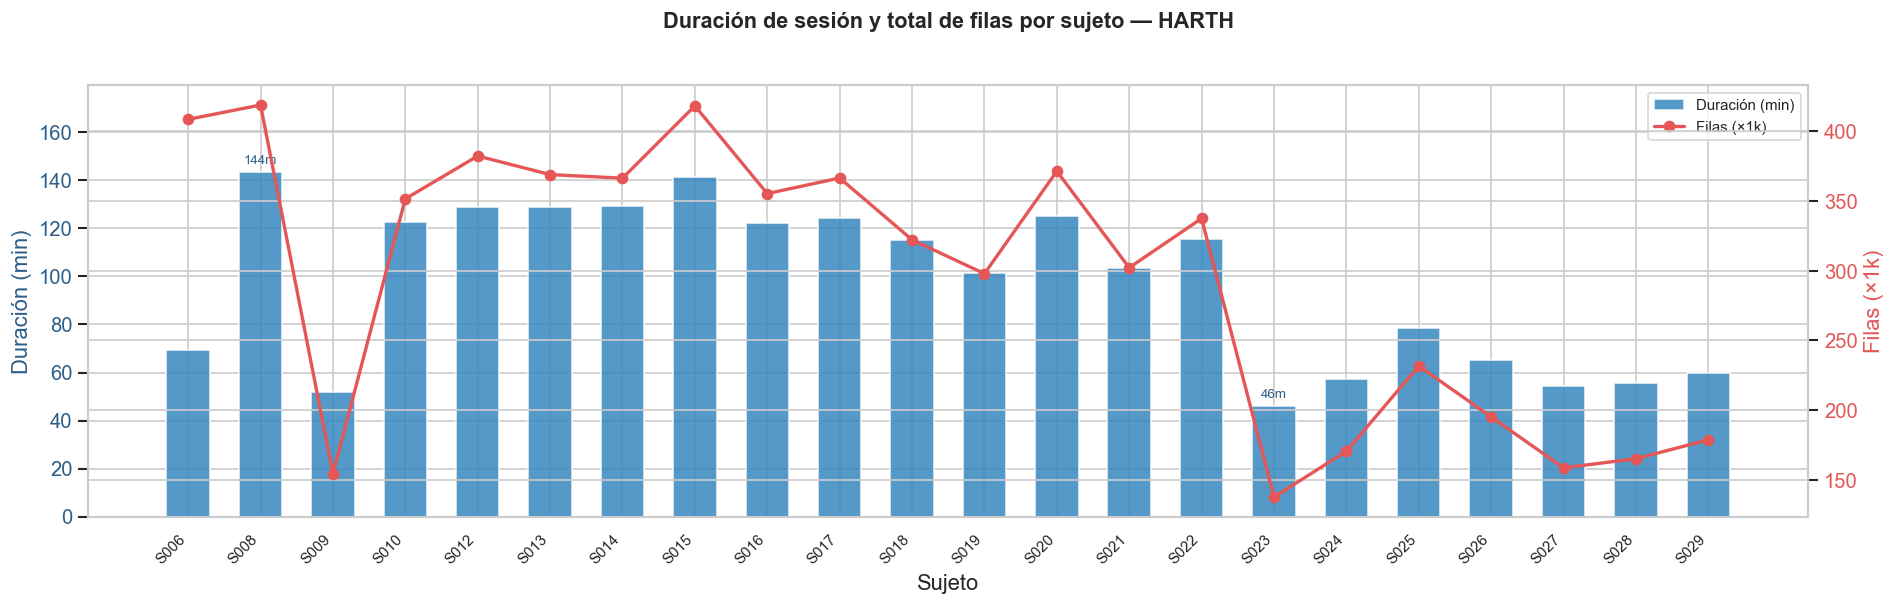

  💾 Guardado: eda_outputs\cross_duration_rows.png


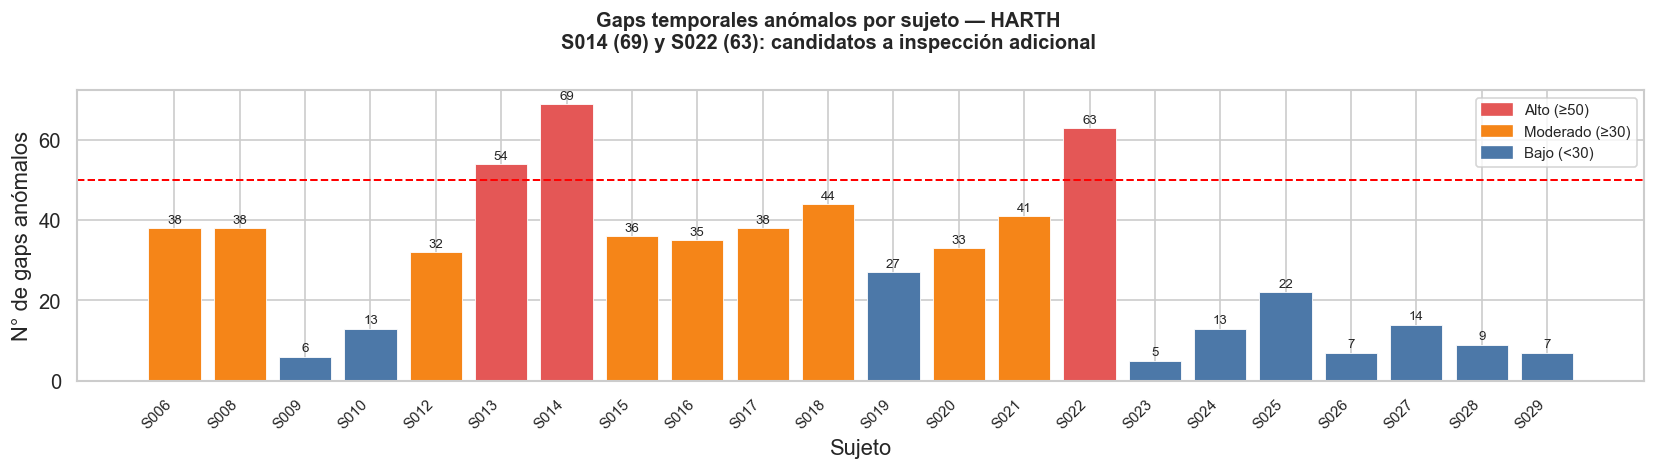

  💾 Guardado: eda_outputs\cross_ts_gaps.png


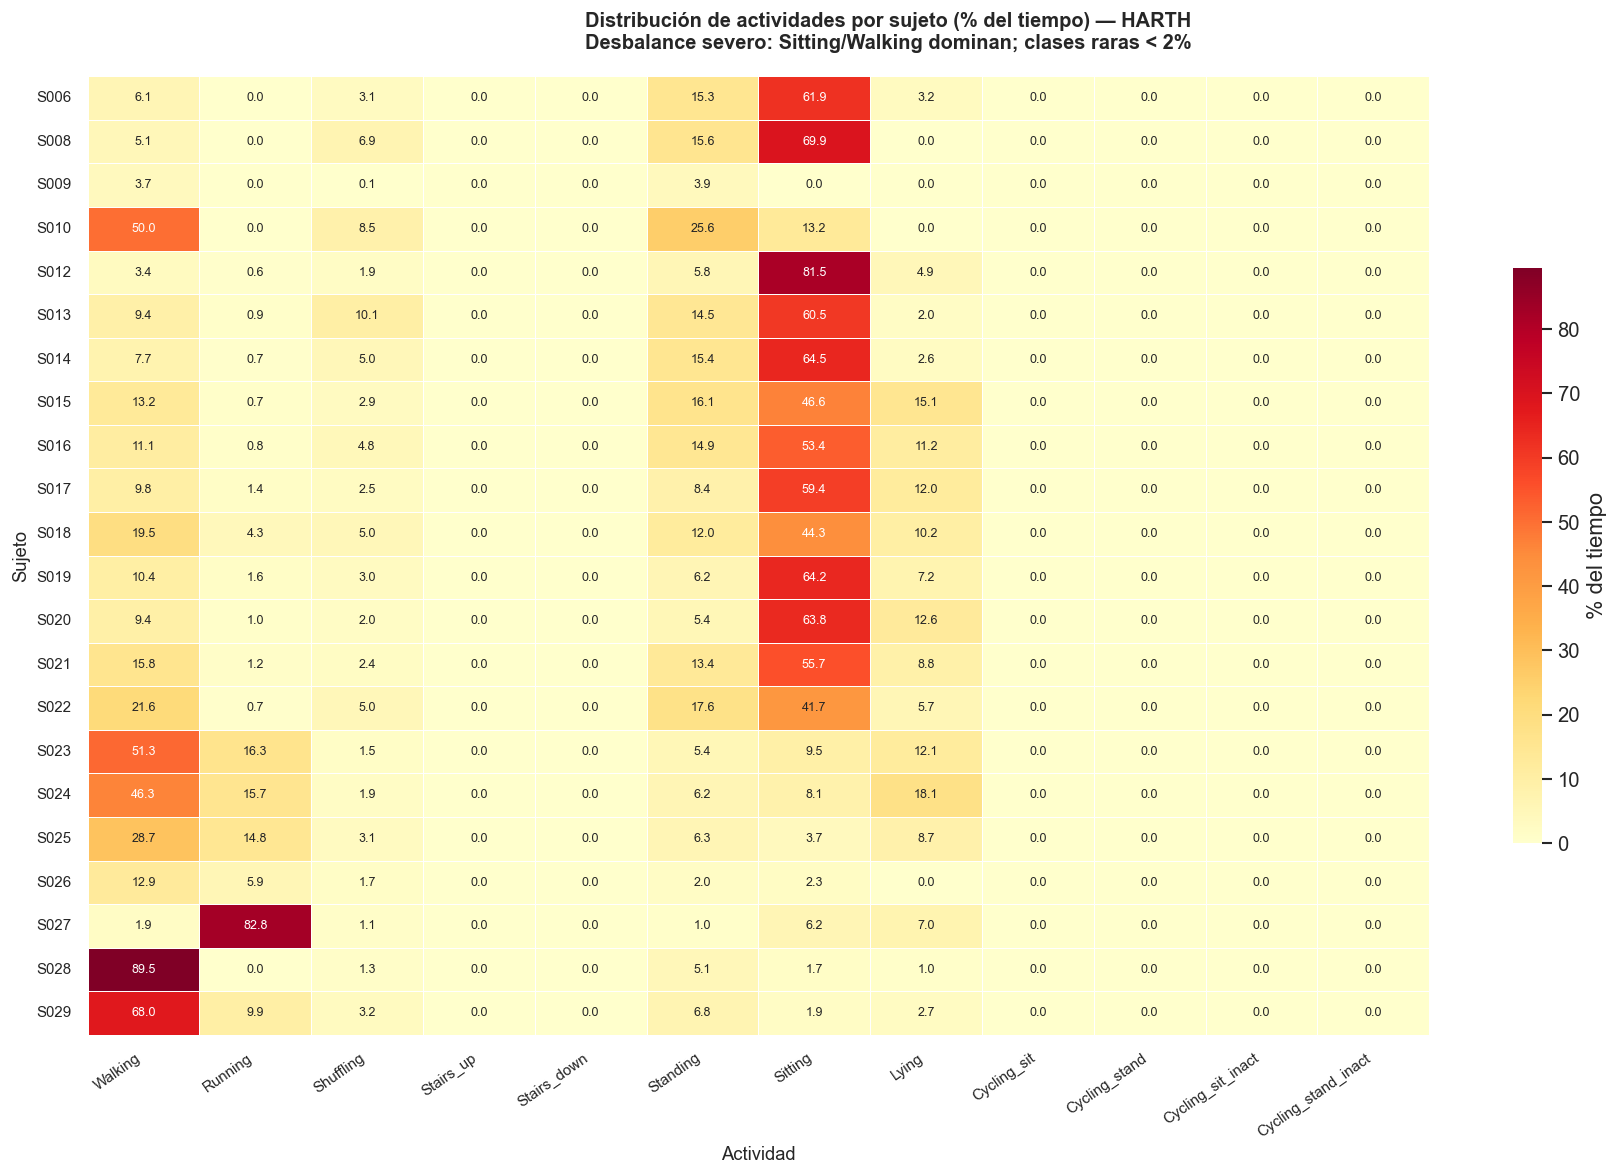

  💾 Guardado: eda_outputs\cross_activity_heatmap.png


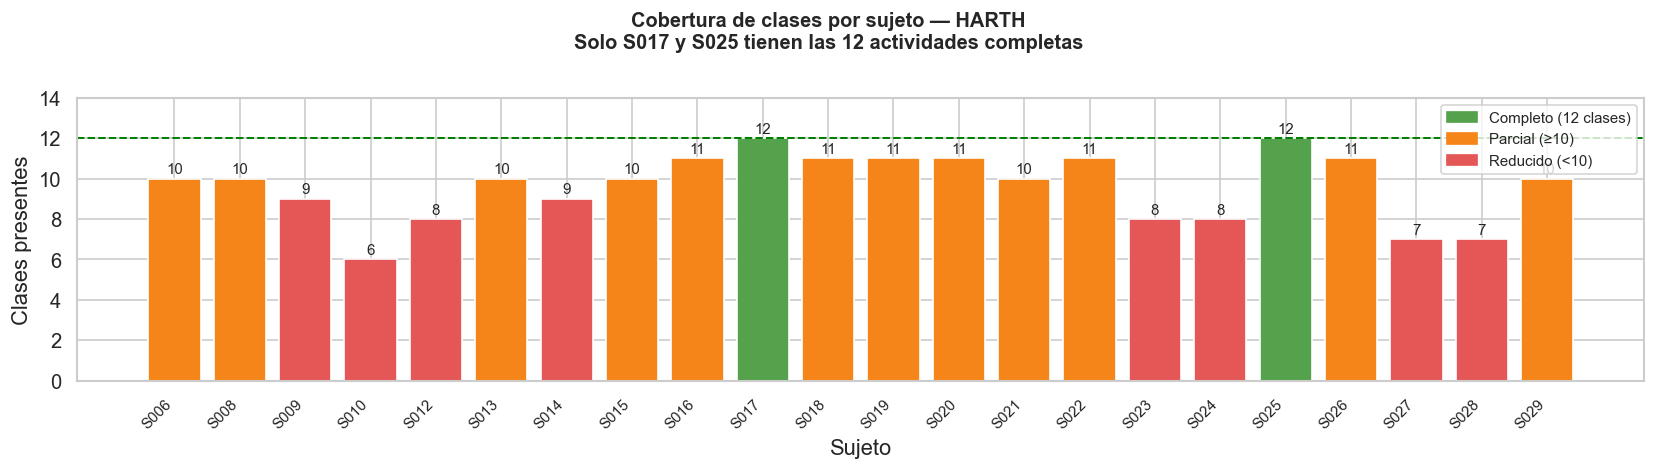

  💾 Guardado: eda_outputs\cross_class_coverage.png

✅ Análisis cruzado completado.
✔ Celda 4 ejecutada.


In [4]:
# ============================================================
# CELDA 4: Análisis Cruzado Entre Sujetos (Cross-Subject EDA)
# ============================================================
# Requiere que la Celda 3 ya haya sido ejecutada y que
# harth_eda.results esté disponible.

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import pandas as pd
import numpy as np
from IPython.display import display, Image as IPImage
from pathlib import Path

# ── Constantes de actividades para reconstruir DataFrame ────
ACT_COLS = [
    "Walking", "Running", "Shuffling", "Stairs_up", "Stairs_down",
    "Standing", "Sitting", "Lying", "Cycling_sit", "Cycling_stand",
    "Cycling_sit_inact", "Cycling_stand_inact"
]


class CrossSubjectAnalyzer:
    """
    Genera visualizaciones comparativas entre todos los sujetos
    a partir de los resultados EDA almacenados en HARTHDatasetEDA.

    Parámetros
    ----------
    harth_eda : HARTHDatasetEDA
        Objeto con atributo `results` ya populado por run_all().
    output_dir : str | Path
        Directorio donde se guardarán las figuras globales.
    """

    def __init__(self, harth_eda, output_dir: str = "eda_outputs"):
        self.harth_eda  = harth_eda
        self.output_dir = Path(output_dir)
        self.output_dir.mkdir(parents=True, exist_ok=True)
        self.df_summary  = self._build_summary_df()
        self.df_activity = self._build_activity_df()

    # ── Construcción de DataFrames agregados ─────────────────
    def _build_summary_df(self) -> pd.DataFrame:
        """
        Construye un DataFrame con las métricas globales
        de cada sujeto a partir de SubjectEDAResult.
        """
        rows = []
        for sid, r in self.harth_eda.results.items():
            rows.append({
                "subject":       sid,
                "n_rows":        r.n_rows,
                "duration_min":  r.duration_min,
                "n_activities":  len(r.label_counts),
                "ts_gaps":       len(r.timestamp_gaps),
            })
        return pd.DataFrame(rows).set_index("subject")

    def _build_activity_df(self) -> pd.DataFrame:
        """
        Construye una tabla sujeto × actividad con porcentajes.
        Las actividades ausentes se rellenan con 0.
        """
        rows = {}
        for sid, r in self.harth_eda.results.items():
            pct_dict = r.label_pct.to_dict()
            rows[sid] = {act: pct_dict.get(act, 0.0) for act in ACT_COLS}
        df = pd.DataFrame(rows, index=ACT_COLS).T
        return df

    # ── Fig 1: Duración y número de filas ────────────────────
    def plot_duration_rows(self) -> None:
        """
        Genera un gráfico de doble eje con:
        - Barras: duración de sesión por sujeto
        - Línea: total de filas (×1000) por sujeto
        Muestra inline en el notebook y guarda como PNG.
        """
        df = self.df_summary.reset_index()
        subjects = df["subject"]
        x = np.arange(len(subjects))
        bar_w = 0.6

        fig, ax1 = plt.subplots(figsize=(16, 5))
        bars = ax1.bar(x, df["duration_min"], bar_w,
                       color=sns.color_palette("Blues_d", 1)[0],
                       alpha=0.85, label="Duración (min)")
        ax1.set_ylabel("Duración (min)", color="#2C5F8A")
        ax1.set_ylim(0, df["duration_min"].max() * 1.25)
        ax1.tick_params(axis="y", labelcolor="#2C5F8A")

        ax2 = ax1.twinx()
        ax2.plot(x, df["n_rows"] / 1000, "o-",
                 color="#E45756", linewidth=2, markersize=6,
                 label="Filas (×1k)")
        ax2.set_ylabel("Filas (×1k)", color="#E45756")
        ax2.tick_params(axis="y", labelcolor="#E45756")

        ax1.set_xticks(x)
        ax1.set_xticklabels(subjects, rotation=45, ha="right", fontsize=9)
        ax1.set_xlabel("Sujeto")

        # Anotación de valores extremos
        for i, (dur, row) in enumerate(
            zip(df["duration_min"], df["n_rows"] / 1000)
        ):
            if dur == df["duration_min"].max() or dur == df["duration_min"].min():
                ax1.annotate(f"{dur:.0f}m", (x[i], dur),
                             textcoords="offset points", xytext=(0, 5),
                             ha="center", fontsize=8, color="#2C5F8A")

        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2,
                   loc="upper right", fontsize=9)
        fig.suptitle(
            "Duración de sesión y total de filas por sujeto — HARTH",
            fontsize=13, fontweight="bold", y=1.01
        )
        plt.tight_layout()
        path = self.output_dir / "cross_duration_rows.png"
        fig.savefig(path, bbox_inches="tight", dpi=120)
        plt.show()   # ← visualización inline en Jupyter
        print(f"  💾 Guardado: {path}")

    # ── Fig 2: Gaps temporales por sujeto ────────────────────
    def plot_ts_gaps(self, threshold: int = 50) -> None:
        """
        Barras coloreadas por severidad de gaps temporales.
        Rojo ≥ threshold, naranja ≥ 30, azul < 30.
        """
        df = self.df_summary.reset_index()
        colors = [
            "#E45756" if g >= threshold
            else "#F58518" if g >= 30
            else "#4C78A8"
            for g in df["ts_gaps"]
        ]
        fig, ax = plt.subplots(figsize=(14, 4))
        bars = ax.bar(df["subject"], df["ts_gaps"],
                      color=colors, edgecolor="white", linewidth=0.5)
        ax.axhline(threshold, color="red", linestyle="--", linewidth=1.2,
                   label=f"Umbral crítico ({threshold})")
        for bar in bars:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                    str(int(bar.get_height())), ha="center", va="bottom",
                    fontsize=8)

        legend_patches = [
            mpatches.Patch(color="#E45756", label=f"Alto (≥{threshold})"),
            mpatches.Patch(color="#F58518", label="Moderado (≥30)"),
            mpatches.Patch(color="#4C78A8", label="Bajo (<30)"),
        ]
        ax.legend(handles=legend_patches, fontsize=9, loc="upper right")
        ax.set_ylabel("N° de gaps anómalos")
        ax.set_xlabel("Sujeto")
        plt.xticks(rotation=45, ha="right", fontsize=9)
        fig.suptitle(
            "Gaps temporales anómalos por sujeto — HARTH\n"
            "S014 (69) y S022 (63): candidatos a inspección adicional",
            fontsize=12, fontweight="bold"
        )
        plt.tight_layout()
        path = self.output_dir / "cross_ts_gaps.png"
        fig.savefig(path, bbox_inches="tight", dpi=120)
        plt.show()
        print(f"  💾 Guardado: {path}")

    # ── Fig 3: Heatmap de actividades ─────────────────────────
    def plot_activity_heatmap(self) -> None:
        """
        Heatmap sujeto × actividad con porcentaje de tiempo.
        Permite identificar de un vistazo los perfiles de
        comportamiento y el desbalance por clase.
        """
        fig, ax = plt.subplots(figsize=(15, 10))
        sns.heatmap(
            self.df_activity,
            annot=True, fmt=".1f",
            cmap="YlOrRd",
            linewidths=0.3, linecolor="white",
            cbar_kws={"label": "% del tiempo", "shrink": 0.6},
            ax=ax,
            annot_kws={"size": 7.5}
        )
        ax.set_xlabel("Actividad", fontsize=11)
        ax.set_ylabel("Sujeto", fontsize=11)
        ax.set_xticklabels(ax.get_xticklabels(),
                           rotation=35, ha="right", fontsize=9)
        ax.set_yticklabels(ax.get_yticklabels(), fontsize=9)
        fig.suptitle(
            "Distribución de actividades por sujeto (% del tiempo) — HARTH\n"
            "Desbalance severo: Sitting/Walking dominan; clases raras < 2%",
            fontsize=12, fontweight="bold"
        )
        plt.tight_layout()
        path = self.output_dir / "cross_activity_heatmap.png"
        fig.savefig(path, bbox_inches="tight", dpi=120)
        plt.show()
        print(f"  💾 Guardado: {path}")

    # ── Fig 4: Clases presentes por sujeto ───────────────────
    def plot_class_coverage(self) -> None:
        """
        Barras con número de actividades distintas por sujeto,
        coloreadas según cobertura respecto al máximo (12).
        """
        df = self.df_summary.reset_index()
        n_max = len(ACT_COLS)
        colors = [
            "#54A24B" if n == n_max
            else "#F58518" if n >= 10
            else "#E45756"
            for n in df["n_activities"]
        ]
        fig, ax = plt.subplots(figsize=(14, 4))
        bars = ax.bar(df["subject"], df["n_activities"],
                      color=colors, edgecolor="white")
        ax.axhline(n_max, color="green", linestyle="--",
                   linewidth=1.2, label=f"Máximo ({n_max} clases)")
        for bar in bars:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.1, str(int(bar.get_height())),
                    ha="center", va="bottom", fontsize=9)

        legend_patches = [
            mpatches.Patch(color="#54A24B", label="Completo (12 clases)"),
            mpatches.Patch(color="#F58518", label="Parcial (≥10)"),
            mpatches.Patch(color="#E45756", label="Reducido (<10)"),
        ]
        ax.legend(handles=legend_patches, fontsize=9)
        ax.set_ylim(0, n_max + 2)
        ax.set_ylabel("Clases presentes")
        ax.set_xlabel("Sujeto")
        plt.xticks(rotation=45, ha="right", fontsize=9)
        fig.suptitle(
            "Cobertura de clases por sujeto — HARTH\n"
            "Solo S017 y S025 tienen las 12 actividades completas",
            fontsize=12, fontweight="bold"
        )
        plt.tight_layout()
        path = self.output_dir / "cross_class_coverage.png"
        fig.savefig(path, bbox_inches="tight", dpi=120)
        plt.show()
        print(f"  💾 Guardado: {path}")

    # ── Pipeline completo ─────────────────────────────────────
    def run_all_plots(self) -> None:
        """Genera y muestra las 4 visualizaciones comparativas."""
        print("📊 Generando análisis cruzado entre sujetos...\n")
        self.plot_duration_rows()
        self.plot_ts_gaps()
        self.plot_activity_heatmap()
        self.plot_class_coverage()
        print("\n✅ Análisis cruzado completado.")


# ── Ejecución ────────────────────────────────────────────────
analyzer = CrossSubjectAnalyzer(harth_eda, output_dir=OUTPUT_DIR)
analyzer.run_all_plots()

print("✔ Celda 4 ejecutada.")

⚖️  Analizando desbalance de clases...

                     mean_%  std_%  min_%  max_%  presence_%
Sitting               37.00  28.46   0.00  81.51       95.45
Walking               22.48  23.61   1.86  89.51      100.00
Standing              10.14   6.20   1.03  25.64      100.00
Running                7.24  17.72   0.00  82.80       77.27
Lying                  6.61   5.43   0.00  18.10       81.82
Shuffling              3.50   2.47   0.12  10.11      100.00
Stairs_up              0.00   0.00   0.00   0.00        0.00
Stairs_down            0.00   0.00   0.00   0.00        0.00
Cycling_sit            0.00   0.00   0.00   0.00        0.00
Cycling_stand          0.00   0.00   0.00   0.00        0.00
Cycling_sit_inact      0.00   0.00   0.00   0.00        0.00
Cycling_stand_inact    0.00   0.00   0.00   0.00        0.00



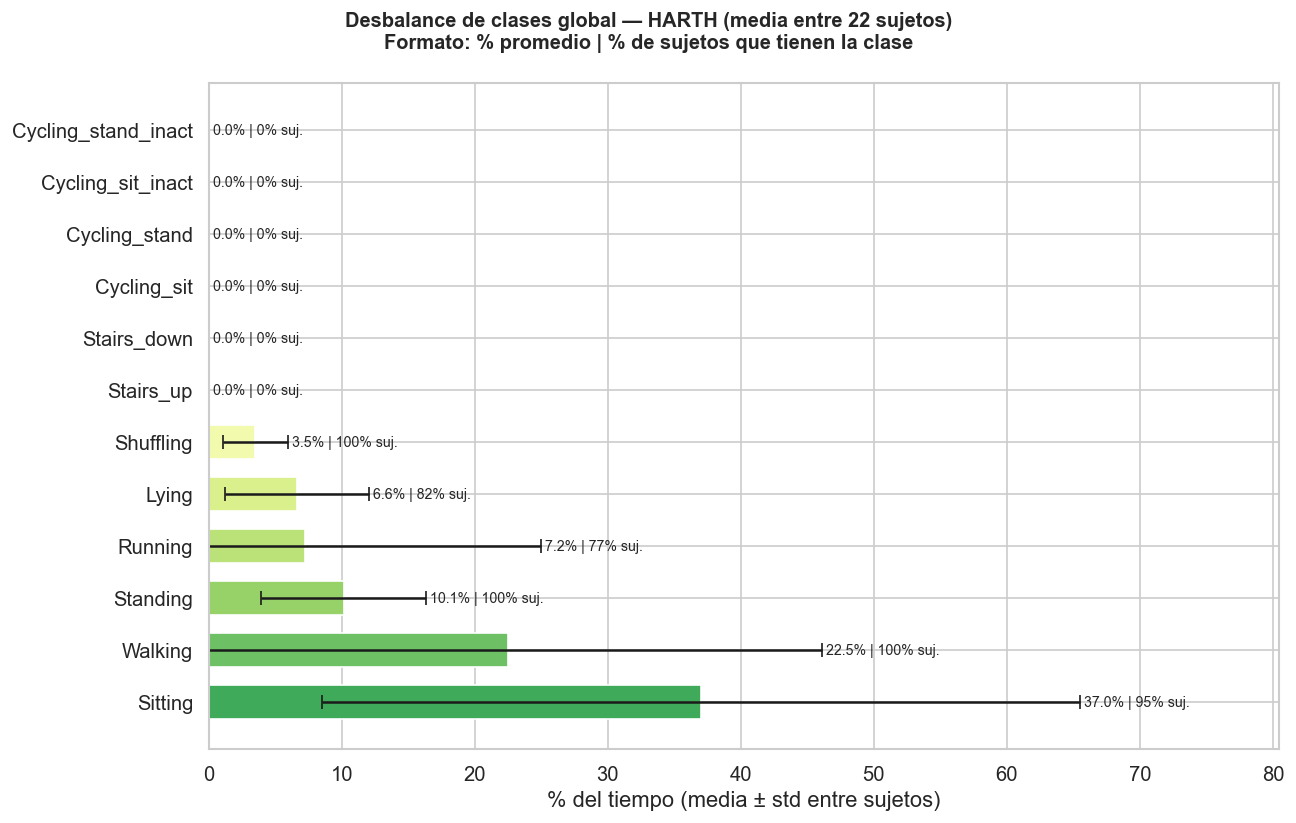

  💾 Guardado: eda_outputs\global_class_imbalance.png


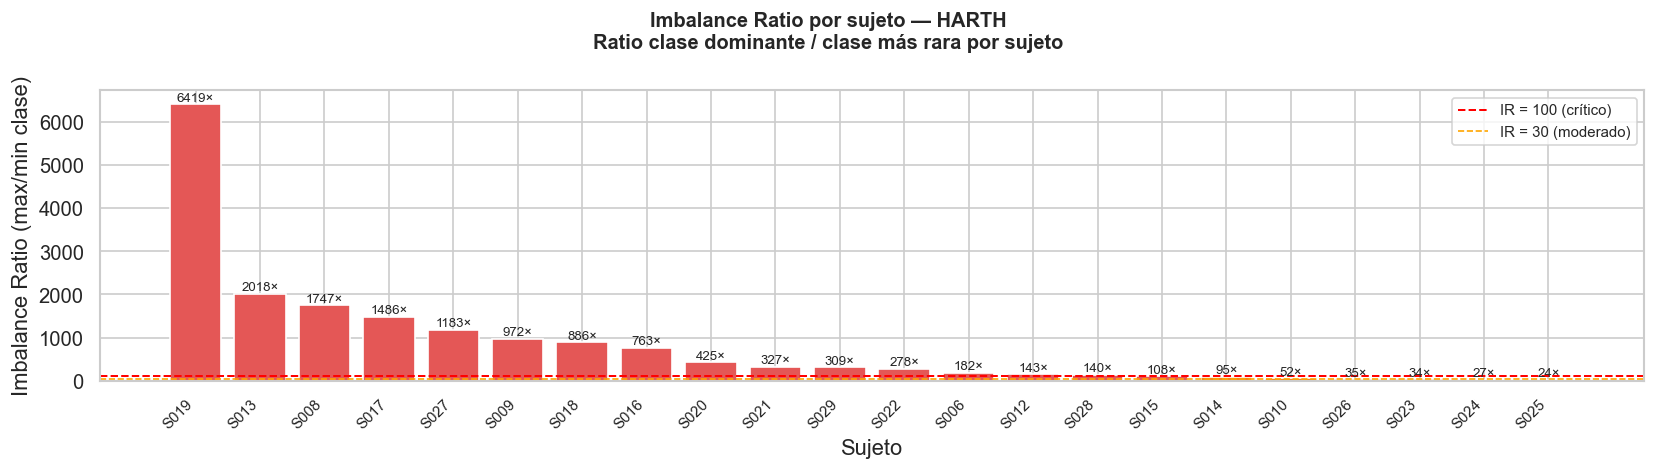

  💾 Guardado: eda_outputs\imbalance_ratio.png

  🧠  RECOMENDACIONES PARA LA RED NEURONAL (HARTH EDA)

  📌 DESBALANCE DE CLASES
     Clases dominantes (>30% media): ['Sitting']
     Clases raras (<60% presencia):  ['Stairs_up', 'Stairs_down', 'Cycling_sit', 'Cycling_stand', 'Cycling_sit_inact', 'Cycling_stand_inact']
     → Usar class_weight='balanced' o Focal Loss (γ=2)
     → Considerar oversampling de ventanas de clases raras

  📌 GAPS TEMPORALES
     Sujetos con gaps ≥ 50: ['S013', 'S014', 'S022']
     → Revisar si los gaps coinciden con transiciones de clase
     → Descartar ventanas que contengan un gap en su interior

  📌 SUJETOS ATÍPICOS PARA LOSO
     Sesiones cortas (<60 min): ['S009', 'S023', 'S024', 'S027', 'S028', 'S029']
     Pocas clases (≤7):          ['S010', 'S027', 'S028']
     → Cuando sean sujetos de prueba LOSO, el F1 macro
       puede estar artificialmente inflado o deflado.

  📌 VENTANA DE SEGMENTACIÓN
     → Recomendado: 2–5 s (100–250 muestras a 50 Hz)
     → 

In [5]:
# ============================================================
# CELDA 5: Análisis de Desbalance y Recomendaciones LOSO
# ============================================================

class ImbalanceAnalyzer:
    """
    Cuantifica el desbalance de clases a nivel global del dataset
    y genera recomendaciones específicas para el entrenamiento
    de la red neuronal bajo validación LOSO.

    Parámetros
    ----------
    cross_analyzer : CrossSubjectAnalyzer
        Objeto con df_activity y df_summary ya construidos.
    output_dir : str | Path
        Directorio de salida para figuras y reportes.
    """

    def __init__(self, cross_analyzer: CrossSubjectAnalyzer,
                 output_dir: str = "eda_outputs"):
        self.ca         = cross_analyzer
        self.output_dir = Path(output_dir)

    # ── Media global de cada clase ────────────────────────────
    def global_class_stats(self) -> pd.DataFrame:
        """
        Retorna estadísticas globales por clase:
        media, std, min, max y presencia (% de sujetos que la tienen).
        """
        df = self.ca.df_activity
        stats = df.agg(["mean", "std", "min", "max"]).T
        stats["presence_pct"] = (df > 0).mean(axis=0) * 100
        stats.columns = ["mean_%", "std_%", "min_%", "max_%", "presence_%"]
        return stats.round(2).sort_values("mean_%", ascending=False)

    # ── Fig 5: Desbalance global (media ± std) ────────────────
    def plot_global_imbalance(self) -> None:
        """
        Gráfico de barras horizontales con la media de cada actividad
        a nivel de dataset (promediada entre los 22 sujetos),
        con banda de error (std) y porcentaje de presencia.
        """
        stats = self.global_class_stats()
        fig, ax = plt.subplots(figsize=(11, 7))
        colors = plt.cm.RdYlGn(
            np.linspace(0.15, 0.85, len(stats))[::-1]
        )
        bars = ax.barh(stats.index, stats["mean_%"],
                       xerr=stats["std_%"], capsize=4,
                       color=colors, edgecolor="white", height=0.65)
        for bar, (_, row) in zip(bars, stats.iterrows()):
            ax.text(bar.get_width() + row["std_%"] + 0.3,
                    bar.get_y() + bar.get_height() / 2,
                    f"{row['mean_%']:.1f}% | {row['presence_%']:.0f}% suj.",
                    va="center", fontsize=8.5)
        ax.set_xlabel("% del tiempo (media ± std entre sujetos)")
        ax.set_xlim(0, stats["mean_%"].max() + stats["std_%"].max() + 15)
        fig.suptitle(
            "Desbalance de clases global — HARTH (media entre 22 sujetos)\n"
            "Formato: % promedio | % de sujetos que tienen la clase",
            fontsize=12, fontweight="bold"
        )
        plt.tight_layout()
        path = self.output_dir / "global_class_imbalance.png"
        fig.savefig(path, bbox_inches="tight", dpi=120)
        plt.show()
        print(f"  💾 Guardado: {path}")

    # ── Fig 6: Imbalance ratio por clase ─────────────────────
    def plot_imbalance_ratio(self) -> None:
        """
        Calcula el Imbalance Ratio (clase mayoritaria / clase minoritaria)
        por sujeto y lo visualiza. Ratio alto → mayor necesidad de
        ponderación en loss function.
        """
        ratios = {}
        for sid, r in self.ca.harth_eda.results.items():
            pct = r.label_pct
            if len(pct) >= 2:
                ratios[sid] = pct.max() / (pct[pct > 0].min() + 1e-9)

        df_ratio = pd.DataFrame.from_dict(
            ratios, orient="index", columns=["imbalance_ratio"]
        ).sort_values("imbalance_ratio", ascending=False)

        fig, ax = plt.subplots(figsize=(14, 4))
        colors = [
            "#E45756" if r > 100 else "#F58518" if r > 30 else "#4C78A8"
            for r in df_ratio["imbalance_ratio"]
        ]
        bars = ax.bar(df_ratio.index, df_ratio["imbalance_ratio"],
                      color=colors, edgecolor="white")
        ax.axhline(100, color="red", linestyle="--",
                   linewidth=1.2, label="IR = 100 (crítico)")
        ax.axhline(30, color="orange", linestyle="--",
                   linewidth=1.0, label="IR = 30 (moderado)")
        for bar in bars:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 1.5, f"{bar.get_height():.0f}×",
                    ha="center", va="bottom", fontsize=8)
        ax.set_ylabel("Imbalance Ratio (max/min clase)")
        ax.set_xlabel("Sujeto")
        ax.legend(fontsize=9)
        plt.xticks(rotation=45, ha="right", fontsize=9)
        fig.suptitle(
            "Imbalance Ratio por sujeto — HARTH\n"
            "Ratio clase dominante / clase más rara por sujeto",
            fontsize=12, fontweight="bold"
        )
        plt.tight_layout()
        path = self.output_dir / "imbalance_ratio.png"
        fig.savefig(path, bbox_inches="tight", dpi=120)
        plt.show()
        print(f"  💾 Guardado: {path}")

    # ── Reporte de recomendaciones ────────────────────────────
    def print_recommendations(self) -> None:
        """
        Imprime recomendaciones de preprocesamiento y arquitectura
        derivadas del análisis de desbalance para la red neuronal.
        """
        stats = self.global_class_stats()
        rare = stats[stats["presence_%"] < 60].index.tolist()
        dominant = stats[stats["mean_%"] > 30].index.tolist()

        print("\n" + "=" * 65)
        print("  🧠  RECOMENDACIONES PARA LA RED NEURONAL (HARTH EDA)")
        print("=" * 65)

        print("\n  📌 DESBALANCE DE CLASES")
        print(f"     Clases dominantes (>30% media): {dominant}")
        print(f"     Clases raras (<60% presencia):  {rare}")
        print("     → Usar class_weight='balanced' o Focal Loss (γ=2)")
        print("     → Considerar oversampling de ventanas de clases raras")

        print("\n  📌 GAPS TEMPORALES")
        high_gaps = [s for s, r in self.ca.harth_eda.results.items()
                     if len(r.timestamp_gaps) >= 50]
        print(f"     Sujetos con gaps ≥ 50: {high_gaps}")
        print("     → Revisar si los gaps coinciden con transiciones de clase")
        print("     → Descartar ventanas que contengan un gap en su interior")

        print("\n  📌 SUJETOS ATÍPICOS PARA LOSO")
        short = [s for s, r in self.ca.harth_eda.results.items()
                 if r.duration_min < 60]
        few_class = [s for s, r in self.ca.harth_eda.results.items()
                     if len(r.label_counts) <= 7]
        print(f"     Sesiones cortas (<60 min): {short}")
        print(f"     Pocas clases (≤7):          {few_class}")
        print("     → Cuando sean sujetos de prueba LOSO, el F1 macro")
        print("       puede estar artificialmente inflado o deflado.")

        print("\n  📌 VENTANA DE SEGMENTACIÓN")
        print("     → Recomendado: 2–5 s (100–250 muestras a 50 Hz)")
        print("     → Solapamiento: 50% para aumentar datos en clases raras")
        print("     → Etiqueta de ventana: mayoría temporal (mode)")

        print("\n  📌 NORMALIZACIÓN")
        print("     → StandardScaler por canal, ajustado SOLO en train")
        print("     → Calcular media/std por fold LOSO (22 iteraciones)")
        print("=" * 65)

    # ── Pipeline completo ─────────────────────────────────────
    def run(self) -> None:
        """Ejecuta el análisis de desbalance completo."""
        print("⚖️  Analizando desbalance de clases...\n")
        print(self.global_class_stats().to_string())
        print()
        self.plot_global_imbalance()
        self.plot_imbalance_ratio()
        self.print_recommendations()


# ── Ejecución ────────────────────────────────────────────────
imbalance = ImbalanceAnalyzer(analyzer, output_dir=OUTPUT_DIR)
imbalance.run()

print("\n✔ Celda 5 ejecutada.")

In [6]:
# ============================================================
# CELDA 6: DatasetBuilder — Carga, limpieza y ensamblaje
# ============================================================
# Responsabilidad: cargar los 22 CSV, marcar gaps temporales,
# construir un único DataFrame maestro con subject_id.
# Este paso se ejecuta UNA sola vez, antes del loop LOSO.

import os
import numpy as np
import pandas as pd
from pathlib import Path
from dataclasses import dataclass, field
from typing import Optional


# ── Mapeo de etiquetas (consistente con EDA) ─────────────────
ACTIVITY_MAP = {
    1:   "Walking",       2:   "Running",
    3:   "Shuffling",     4:   "Stairs_up",
    5:   "Stairs_down",   6:   "Standing",
    7:   "Sitting",       8:   "Lying",
    13:  "Cycling_sit",   14:  "Cycling_stand",
    130: "Cycling_sit_inact", 140: "Cycling_stand_inact"
}

SIGNAL_COLS  = ["back_x", "back_y", "back_z",
                "thigh_x", "thigh_y", "thigh_z"]
SAMPLING_RATE = 50   # Hz
EXPECTED_INTERVAL_MS = 1000 / SAMPLING_RATE   # 20 ms


class DatasetBuilder:
    """
    Carga y ensambla el dataset HARTH completo desde los CSV
    individuales, marcando gaps temporales y codificando etiquetas.

    Parámetros
    ----------
    dataset_dir : str | Path
        Carpeta con los 22 archivos CSV del dataset HARTH.
    gap_threshold_ms : float
        Umbral (ms) para detectar gaps anómalos entre muestras.
        Por defecto 25 ms (1.25× el intervalo esperado de 20 ms).
    min_gap_ms : float
        Gap mínimo (ms) para registrar en el log (evita ruido numérico).
    """

    def __init__(
        self,
        dataset_dir: str | Path,
        gap_threshold_ms: float = 25.0,
        min_gap_ms: float = 5.0,
    ):
        self.dataset_dir      = Path(dataset_dir)
        self.gap_threshold_ms = gap_threshold_ms
        self.min_gap_ms       = min_gap_ms
        self.master_df: Optional[pd.DataFrame] = None
        self._gap_log: dict[str, pd.DataFrame] = {}

        if not self.dataset_dir.exists():
            raise FileNotFoundError(
                f"No se encontró el directorio: {self.dataset_dir}"
            )

    # ── Carga individual ──────────────────────────────────────
    def _load_subject(self, csv_path: Path) -> pd.DataFrame:
        """
        Carga un CSV, parsea timestamp, agrega subject_id
        y etiqueta de actividad en texto.
        """
        df = pd.read_csv(csv_path)
        df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
        df["subject_id"] = csv_path.stem           # e.g. "S006"
        df["activity"]   = df["label"].map(
            lambda x: ACTIVITY_MAP.get(int(x), f"Unknown_{x}")
        )
        return df

    # ── Marcado de gaps ───────────────────────────────────────
    def _mark_gaps(self, df: pd.DataFrame) -> pd.DataFrame:
        """
        Agrega columna booleana `is_gap_adjacent` = True para filas
        inmediatamente anteriores y posteriores a un gap anómalo.

        Esta columna se usará en la segmentación para descartar
        ventanas contaminadas por discontinuidades temporales.
        """
        df = df.copy()
        df["is_gap_adjacent"] = False

        if df["timestamp"].isna().all():
            # Sin timestamp: no es posible detectar gaps
            return df

        diffs_ms = df["timestamp"].diff().dt.total_seconds() * 1000

        # Índices donde hay un gap real (no ruido numérico)
        gap_mask = diffs_ms > self.gap_threshold_ms
        gap_idx  = df.index[gap_mask].tolist()

        for idx in gap_idx:
            # Marcar la fila anterior (fin del segmento bueno)
            # y la fila actual (inicio del nuevo segmento)
            if idx - 1 >= df.index[0]:
                df.loc[idx - 1, "is_gap_adjacent"] = True
            df.loc[idx, "is_gap_adjacent"] = True

        # Guardar log del sujeto para inspección posterior
        gaps_df = df[gap_mask][["timestamp"]].copy()
        gaps_df["gap_ms"] = diffs_ms[gap_mask].round(2)
        sid = df["subject_id"].iloc[0]
        self._gap_log[sid] = gaps_df

        return df

    # ── Pipeline principal ────────────────────────────────────
    def build(self, verbose: bool = True) -> pd.DataFrame:
        """
        Itera sobre los 22 CSV, aplica limpieza y marcado de gaps,
        y concatena en un DataFrame maestro.

        Retorna
        -------
        pd.DataFrame
            DataFrame con columnas originales + subject_id +
            activity + is_gap_adjacent.
        """
        csv_files = sorted(self.dataset_dir.glob("*.csv"))
        if not csv_files:
            raise FileNotFoundError(
                f"No se encontraron CSV en: {self.dataset_dir}"
            )

        pieces = []
        print(f"📦 Construyendo dataset maestro ({len(csv_files)} sujetos)...")

        for f in csv_files:
            df = self._load_subject(f)
            df = self._mark_gaps(df)
            pieces.append(df)
            if verbose:
                n_gaps = df["is_gap_adjacent"].sum()
                print(f"  ✔ {f.stem:6s} — {len(df):>7,} filas | "
                      f"filas marcadas por gap: {n_gaps}")

        self.master_df = pd.concat(pieces, ignore_index=True)

        if verbose:
            print(f"\n✅ Dataset maestro construido.")
            print(f"   Filas totales      : {len(self.master_df):,}")
            print(f"   Sujetos            : "
                  f"{self.master_df['subject_id'].nunique()}")
            print(f"   Filas gap-adjacent : "
                  f"{self.master_df['is_gap_adjacent'].sum():,} "
                  f"({self.master_df['is_gap_adjacent'].mean()*100:.2f}%)")
            print(f"   Clases distintas   : "
                  f"{self.master_df['activity'].nunique()}")

        return self.master_df

    # ── Acceso al log de gaps ─────────────────────────────────
    def get_gap_log(self, subject_id: Optional[str] = None):
        """
        Retorna el log de gaps detectados.
        Si se especifica subject_id, retorna solo ese sujeto.
        """
        if subject_id:
            return self._gap_log.get(subject_id, pd.DataFrame())
        return self._gap_log


# ── Ejecución ────────────────────────────────────────────────
builder    = DatasetBuilder(dataset_dir=DATASET_DIR)
master_df  = builder.build(verbose=True)

# Vista rápida del DataFrame maestro
print("\n📋 Primeras filas del DataFrame maestro:")
display(master_df.head(3))
print(f"\n📋 Columnas disponibles: {master_df.columns.tolist()}")

print("\n✔ Celda 6 ejecutada.")

📦 Construyendo dataset maestro (22 sujetos)...
  ✔ S006   — 408,709 filas | filas marcadas por gap: 76
  ✔ S008   — 418,989 filas | filas marcadas por gap: 76
  ✔ S009   — 154,464 filas | filas marcadas por gap: 12
  ✔ S010   — 351,649 filas | filas marcadas por gap: 26
  ✔ S012   — 382,414 filas | filas marcadas por gap: 64
  ✔ S013   — 369,077 filas | filas marcadas por gap: 108
  ✔ S014   — 366,487 filas | filas marcadas por gap: 138
  ✔ S015   — 418,392 filas | filas marcadas por gap: 72
  ✔ S016   — 355,418 filas | filas marcadas por gap: 70
  ✔ S017   — 366,609 filas | filas marcadas por gap: 76
  ✔ S018   — 322,271 filas | filas marcadas por gap: 88
  ✔ S019   — 297,945 filas | filas marcadas por gap: 54
  ✔ S020   — 371,496 filas | filas marcadas por gap: 66
  ✔ S021   — 302,247 filas | filas marcadas por gap: 82
  ✔ S022   — 337,602 filas | filas marcadas por gap: 126
  ✔ S023   — 137,646 filas | filas marcadas por gap: 10
  ✔ S024   — 170,534 filas | filas marcadas por gap: 2

,timestamp,back_x,back_y,back_z,thigh_x,thigh_y,thigh_z,label,subject_id,activity,is_gap_adjacent,index,Unnamed: 0
0,2019-01-12 00:00:00.000,-0.760242,0.299570,0.468570,-5.092732,-0.298644,0.709439,6,S006,Standing,False,NaN,NaN
1,2019-01-12 00:00:00.010,-0.530138,0.281880,0.319987,0.900547,0.286944,0.340309,6,S006,Standing,False,NaN,NaN
2,2019-01-12 00:00:00.020,-1.170922,0.186353,-0.167010,-0.035442,-0.078423,-0.515212,6,S006,Standing,False,NaN,NaN



📋 Columnas disponibles: ['timestamp', 'back_x', 'back_y', 'back_z', 'thigh_x', 'thigh_y', 'thigh_z', 'label', 'subject_id', 'activity', 'is_gap_adjacent', 'index', 'Unnamed: 0']

✔ Celda 6 ejecutada.


In [10]:
# ============================================================
# CELDA 7 (CORREGIDA): WindowSegmenter — Segmentación deslizante
# ============================================================

from dataclasses import dataclass
import numpy as np
import pandas as pd
from pathlib import Path


@dataclass
class SegmentationResult:
    """
    Contenedor del resultado de segmentación para un conjunto
    de sujetos (train o test dentro de un fold LOSO).
    """
    X:           np.ndarray   # (N, window_size, n_channels)
    y:           np.ndarray   # (N,)  etiquetas string
    subjects:    np.ndarray   # (N,)  subject_id por ventana
    window_size: int
    step_size:   int
    n_discarded: int


def _mode_strings(arr: np.ndarray) -> tuple[str, float]:
    """
    Calcula la moda de un array de strings usando np.unique.
    Compatible con SciPy >= 1.11.0 que eliminó soporte de strings.

    Retorna
    -------
    majority_label : str
        Clase más frecuente en el array.
    majority_frac : float
        Fracción de muestras de esa clase respecto al total.
    """
    values, counts = np.unique(arr, return_counts=True)
    idx            = np.argmax(counts)
    return values[idx], counts[idx] / len(arr)


class WindowSegmenter:
    """
    Segmenta un DataFrame de series temporales en ventanas
    deslizantes para clasificación de actividades.

    Parámetros
    ----------
    window_size : int
        Número de muestras por ventana (default: 150 = 3 s a 50 Hz).
    overlap : float
        Fracción de solapamiento entre ventanas [0.0, 1.0).
        Default 0.5 (50%).
    label_majority_threshold : float
        Fracción mínima de la clase mayoritaria para conservar
        una ventana. 0.0 = conservar todas.
    signal_cols : list[str]
        Columnas de señal a incluir como canales.
    """

    def __init__(
        self,
        window_size: int = 150,
        overlap: float = 0.5,
        label_majority_threshold: float = 0.0,
        signal_cols: list[str] = SIGNAL_COLS,
    ):
        if not 0.0 <= overlap < 1.0:
            raise ValueError("overlap debe estar en [0.0, 1.0)")
        self.window_size              = window_size
        self.step_size                = int(window_size * (1 - overlap))
        self.label_majority_threshold = label_majority_threshold
        self.signal_cols              = signal_cols

    # ── Segmentación de un único sujeto ──────────────────────
    def _segment_subject(
        self, df: pd.DataFrame
    ) -> tuple[list, list, int]:
        """
        Genera ventanas para un único sujeto, respetando el
        orden temporal y descartando ventanas problemáticas.

        Retorna (X_list, y_list, n_discarded)
        """
        arr    = df[self.signal_cols].values       # (T, C)  float
        labels = df["activity"].values             # (T,)    str
        gaps   = df["is_gap_adjacent"].values      # (T,)    bool
        T      = len(arr)

        X_list, y_list = [], []
        n_discarded    = 0

        for start in range(0, T - self.window_size + 1, self.step_size):
            end = start + self.window_size

            # ── Descartar ventanas con gap interno ────────────
            if gaps[start:end].any():
                n_discarded += 1
                continue

            # ── Moda de etiquetas con función compatible ──────
            window_labels                  = labels[start:end]
            majority_label, majority_frac  = _mode_strings(window_labels)

            # ── Descartar ventanas ambiguas ───────────────────
            if majority_frac < self.label_majority_threshold:
                n_discarded += 1
                continue

            X_list.append(arr[start:end])
            y_list.append(majority_label)

        return X_list, y_list, n_discarded

    # ── Segmentación multi-sujeto ─────────────────────────────
    def segment(self, df: pd.DataFrame) -> SegmentationResult:
        """
        Segmenta todos los sujetos del DataFrame de forma
        independiente para evitar ventanas entre sujetos.
        """
        all_X, all_y, all_subs = [], [], []
        total_discarded = 0

        for sid, sub_df in df.groupby("subject_id", sort=True):
            sub_df = sub_df.sort_values("timestamp").reset_index(drop=True)
            X_list, y_list, n_disc = self._segment_subject(sub_df)

            all_X.extend(X_list)
            all_y.extend(y_list)
            all_subs.extend([sid] * len(y_list))
            total_discarded += n_disc

        if not all_X:
            raise ValueError(
                "No se generaron ventanas. "
                "Verifica window_size y los datos de entrada."
            )

        return SegmentationResult(
            X           = np.array(all_X, dtype=np.float32),
            y           = np.array(all_y),
            subjects    = np.array(all_subs),
            window_size = self.window_size,
            step_size   = self.step_size,
            n_discarded = total_discarded,
        )

    # ── Resumen del resultado ─────────────────────────────────
    @staticmethod
    def summarize(result: SegmentationResult, label: str = "") -> None:
        """Imprime un resumen del resultado de segmentación."""
        tag = f"[{label}] " if label else ""
        print(f"  {tag}Shape X             : {result.X.shape}")
        print(f"  {tag}Ventanas generadas  : {len(result.X):,}")
        print(f"  {tag}Ventanas descartadas: {result.n_discarded:,}")
        unique, counts = np.unique(result.y, return_counts=True)
        print(f"  {tag}Distribución de clases:")
        for act, cnt in sorted(zip(unique, counts), key=lambda x: -x[1]):
            pct = cnt / len(result.y) * 100
            print(f"       {act:<25} {cnt:>6,}  ({pct:.1f}%)")


# ── Re-instanciar con los mismos parámetros de antes ─────────
segmenter = WindowSegmenter(
    window_size              = WINDOW_SIZE,
    overlap                  = OVERLAP,
    label_majority_threshold = MAJ_THRESH,
    signal_cols              = SIGNAL_COLS,
)

print("✔ Celda 7 re-ejecutada: WindowSegmenter corregido (SciPy ≥ 1.11.0).")

✔ Celda 7 re-ejecutada: WindowSegmenter corregido (SciPy ≥ 1.11.0).


In [12]:
# ============================================================
# CELDA 8: LOSOPipeline — Loop de validación Leave-One-Subject-Out
# ============================================================
# Responsabilidad: ejecutar las 22 iteraciones LOSO con
# normalización estricta dentro del fold, codificación de
# etiquetas, cómputo de class weights y almacenamiento de
# resultados por fold para evaluación posterior.

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from collections import defaultdict
import time


@dataclass
class FoldResult:
    """
    Almacena los datos preparados y metadatos de un fold LOSO.

    Atributos
    ----------
    fold_id : int
    test_subject : str
    X_train, y_train : arrays de entrenamiento (normalizados, codificados)
    X_test, y_test   : arrays de prueba (normalizados, codificados)
    class_weights    : dict {clase_int: peso_float}
    label_encoder    : LabelEncoder ajustado en este fold
    scaler           : StandardScaler ajustado en train de este fold
    train_class_dist : distribución de clases en train (%)
    test_class_dist  : distribución de clases en test (%)
    n_train_windows  : int
    n_test_windows   : int
    elapsed_sec      : float  (tiempo de preparación del fold)
    """
    fold_id:         int
    test_subject:    str
    X_train:         np.ndarray
    y_train:         np.ndarray
    X_test:          np.ndarray
    y_test:          np.ndarray
    class_weights:   dict
    label_encoder:   LabelEncoder
    scaler:          StandardScaler
    train_class_dist: dict
    test_class_dist:  dict
    n_train_windows: int
    n_test_windows:  int
    elapsed_sec:     float


class LOSOPipeline:
    """
    Ejecuta la validación Leave-One-Subject-Out completa sobre
    el dataset HARTH, aplicando segmentación, normalización y
    codificación de etiquetas estrictamente dentro de cada fold.

    Parámetros
    ----------
    master_df : pd.DataFrame
        DataFrame maestro generado por DatasetBuilder.
    segmenter : WindowSegmenter
        Instancia configurada del segmentador.
    output_dir : str | Path
        Directorio donde se guardarán los reportes por fold.
    verbose : bool
        Si True, imprime resumen de cada fold en el notebook.
    """

    def __init__(
        self,
        master_df:  pd.DataFrame,
        segmenter:  WindowSegmenter,
        output_dir: str | Path = "loso_outputs",
        verbose:    bool = True,
    ):
        self.master_df  = master_df
        self.segmenter  = segmenter
        self.output_dir = Path(output_dir)
        self.verbose    = verbose
        self.folds: list[FoldResult] = []
        self.subjects   = sorted(master_df["subject_id"].unique())
        self.output_dir.mkdir(parents=True, exist_ok=True)

    # ── Normalización dentro del fold ─────────────────────────
    @staticmethod
    def _fit_normalize(
        X_train: np.ndarray, X_test: np.ndarray
    ) -> tuple[np.ndarray, np.ndarray, StandardScaler]:
        """
        Ajusta StandardScaler sobre X_train (reshape a 2D),
        transforma X_train y X_test.
        Forma de entrada: (N, window_size, n_channels).
        La normalización opera por canal (eje de canales).
        """
        N_tr, W, C = X_train.shape
        N_te       = X_test.shape[0]

        # Reshape a (N*W, C) para ajustar por canal
        scaler = StandardScaler()
        X_tr_2d = X_train.reshape(-1, C)
        X_te_2d = X_test.reshape(-1, C)

        X_tr_norm = scaler.fit_transform(X_tr_2d).reshape(N_tr, W, C)
        X_te_norm = scaler.transform(X_te_2d).reshape(N_te, W, C)

        return X_tr_norm, X_te_norm, scaler

    # ── Codificación de etiquetas ─────────────────────────────
    @staticmethod
    def _encode_labels(
        y_train: np.ndarray, y_test: np.ndarray
    ) -> tuple[np.ndarray, np.ndarray, LabelEncoder]:
        """
        Ajusta LabelEncoder sobre y_train y transforma ambos sets.
        Retorna enteros codificados y el encoder para decodificación
        posterior en matrices de confusión.
        """
        le = LabelEncoder()
        y_tr_enc = le.fit_transform(y_train)
        # Clases en test no vistas en train → asignar -1
        y_te_enc = np.array([
            le.transform([lbl])[0]
            if lbl in le.classes_ else -1
            for lbl in y_test
        ])
        return y_tr_enc, y_te_enc, le

    # ── Pesos de clase ────────────────────────────────────────
    @staticmethod
    def _compute_class_weights(
        y_train_enc: np.ndarray, le: LabelEncoder
    ) -> dict:
        """
        Calcula pesos balanceados por clase usando sklearn,
        ajustados solo sobre el fold de entrenamiento.
        Retorna dict {clase_int: peso_float}.
        """
        classes = np.unique(y_train_enc)
        weights = compute_class_weight(
            class_weight="balanced",
            classes=classes,
            y=y_train_enc
        )
        return dict(zip(classes.tolist(), weights.tolist()))

    # ── Distribución de clases (para reporte) ─────────────────
    @staticmethod
    def _class_dist(y_enc: np.ndarray, le: LabelEncoder) -> dict:
        """Retorna distribución porcentual por clase."""
        unique, counts = np.unique(y_enc[y_enc >= 0], return_counts=True)
        total = counts.sum()
        return {
            le.classes_[cls]: round(cnt / total * 100, 2)
            for cls, cnt in zip(unique, counts)
        }

    # ── Un fold ───────────────────────────────────────────────
    def _run_fold(
        self, fold_id: int, test_subject: str
    ) -> FoldResult:
        """
        Ejecuta un único fold LOSO:
        1. Divide train/test por sujeto
        2. Segmenta en ventanas (independientemente por set)
        3. Normaliza (scaler ajustado en train)
        4. Codifica etiquetas (encoder ajustado en train)
        5. Calcula class weights sobre train
        """
        t0 = time.time()

        # ── División train/test ───────────────────────────────
        train_df = self.master_df[
            self.master_df["subject_id"] != test_subject
        ].copy()
        test_df  = self.master_df[
            self.master_df["subject_id"] == test_subject
        ].copy()

        # ── Segmentación independiente ────────────────────────
        train_seg = self.segmenter.segment(train_df)
        test_seg  = self.segmenter.segment(test_df)

        # ── Normalización (scaler ajustado en train) ──────────
        X_tr_norm, X_te_norm, scaler = self._fit_normalize(
            train_seg.X, test_seg.X
        )

        # ── Codificación de etiquetas (encoder en train) ──────
        y_tr_enc, y_te_enc, le = self._encode_labels(
            train_seg.y, test_seg.y
        )

        # ── Class weights ─────────────────────────────────────
        cw = self._compute_class_weights(y_tr_enc, le)

        # ── Distribuciones para reporte ───────────────────────
        tr_dist = self._class_dist(y_tr_enc, le)
        te_dist = self._class_dist(y_te_enc, le)

        elapsed = time.time() - t0

        return FoldResult(
            fold_id          = fold_id,
            test_subject     = test_subject,
            X_train          = X_tr_norm.astype(np.float32),
            y_train          = y_tr_enc,
            X_test           = X_te_norm.astype(np.float32),
            y_test           = y_te_enc,
            class_weights    = cw,
            label_encoder    = le,
            scaler           = scaler,
            train_class_dist = tr_dist,
            test_class_dist  = te_dist,
            n_train_windows  = len(X_tr_norm),
            n_test_windows   = len(X_te_norm),
            elapsed_sec      = elapsed,
        )

    # ── Imprimir resumen de un fold ───────────────────────────
    def _print_fold_summary(self, fold: FoldResult) -> None:
        print(f"\n{'─'*55}")
        print(f"  Fold {fold.fold_id:02d}/22 | Test: {fold.test_subject}")
        print(f"{'─'*55}")
        print(f"  X_train : {fold.X_train.shape}  |  "
              f"X_test: {fold.X_test.shape}")
        print(f"  Ventanas train  : {fold.n_train_windows:,}")
        print(f"  Ventanas test   : {fold.n_test_windows:,}")
        print(f"  Clases en train : {len(fold.class_weights)}")
        top_cls = max(fold.train_class_dist,
                      key=fold.train_class_dist.get)
        bot_cls = min(fold.train_class_dist,
                      key=fold.train_class_dist.get)
        print(f"  Clase dominante : {top_cls} "
              f"({fold.train_class_dist[top_cls]:.1f}%)")
        print(f"  Clase más rara  : {bot_cls} "
              f"({fold.train_class_dist[bot_cls]:.1f}%)")
        print(f"  Tiempo fold     : {fold.elapsed_sec:.1f} s")

    # ── Guardar resumen del fold en CSV ───────────────────────
    def _save_fold_summary(self, fold: FoldResult) -> None:
        rows = [{
            "fold_id":        fold.fold_id,
            "test_subject":   fold.test_subject,
            "n_train":        fold.n_train_windows,
            "n_test":         fold.n_test_windows,
            "n_classes_train": len(fold.class_weights),
            "elapsed_sec":    round(fold.elapsed_sec, 2),
        }]
        path = self.output_dir / "fold_summaries.csv"
        df_row = pd.DataFrame(rows)
        # Append si ya existe
        if path.exists():
            df_row.to_csv(path, mode="a", header=False, index=False)
        else:
            df_row.to_csv(path, index=False)

    # ── Loop LOSO completo ────────────────────────────────────
    def run(self) -> list[FoldResult]:
        """
        Ejecuta las 22 iteraciones LOSO completas y retorna
        la lista de FoldResult para entrenamiento posterior.
        """
        n = len(self.subjects)
        print(f"🔄 Iniciando LOSO con {n} sujetos...")
        print(f"   Ventana   : {self.segmenter.window_size} muestras "
              f"({self.segmenter.window_size/SAMPLING_RATE:.1f} s)")
        print(f"   Step      : {self.segmenter.step_size} muestras "
              f"(overlap {(1 - self.segmenter.step_size/self.segmenter.window_size)*100:.0f}%)")
        print(f"   Umbral mayoría: "
              f"{self.segmenter.label_majority_threshold*100:.0f}%\n")

        for i, subject in enumerate(self.subjects, start=1):
            fold = self._run_fold(fold_id=i, test_subject=subject)
            self.folds.append(fold)
            self._save_fold_summary(fold)
            if self.verbose:
                self._print_fold_summary(fold)

        total_time = sum(f.elapsed_sec for f in self.folds)
        print(f"\n✅ LOSO completado — {n} folds en {total_time:.1f} s")
        print(f"   Resumen guardado en: "
              f"{self.output_dir / 'fold_summaries.csv'}")
        return self.folds

    # ── Acceso a un fold específico ───────────────────────────
    def get_fold(self, subject_id: str) -> FoldResult:
        """
        Retorna el FoldResult cuyo test_subject coincida.
        Útil para acceder a un fold específico sin reejecutar.
        """
        for fold in self.folds:
            if fold.test_subject == subject_id:
                return fold
        raise KeyError(f"No se encontró fold para sujeto: {subject_id}")

    # ── Resumen global de todos los folds ─────────────────────
    def global_summary(self) -> pd.DataFrame:
        """
        Retorna un DataFrame con el resumen de todos los folds
        ejecutados hasta el momento.
        """
        rows = []
        for f in self.folds:
            rows.append({
                "fold":         f.fold_id,
                "test_subject": f.test_subject,
                "n_train":      f.n_train_windows,
                "n_test":       f.n_test_windows,
                "n_classes":    len(f.class_weights),
                "elapsed_s":    round(f.elapsed_sec, 1),
            })
        return pd.DataFrame(rows).set_index("fold")


# ════════════════════════════════════════════════════════════
# CONFIGURACIÓN DEL PIPELINE — AJUSTAR AQUÍ
# ════════════════════════════════════════════════════════════

# Hipótesis H3: explorar ventanas de 2, 3 y 5 segundos.
# Comenzar con 3 s (150 muestras) como valor inicial.
WINDOW_SEC   = 3            # segundos
WINDOW_SIZE  = WINDOW_SEC * SAMPLING_RATE   # 150 muestras
OVERLAP      = 0.5          # 50% de solapamiento
MAJ_THRESH   = 0.0          # 0.0 = no descartar por ambigüedad (inicio)

segmenter = WindowSegmenter(
    window_size              = WINDOW_SIZE,
    overlap                  = OVERLAP,
    label_majority_threshold = MAJ_THRESH,
    signal_cols              = SIGNAL_COLS,
)

loso_pipeline = LOSOPipeline(
    master_df  = master_df,
    segmenter  = segmenter,
    output_dir = "./loso_outputs",
    verbose    = True,
)

# ── Ejecutar el pipeline completo ────────────────────────────
# ⚠ Tarda ~5-15 min dependiendo del hardware.
# Para prueba rápida usa run_single primero (ver abajo).
loso_folds = loso_pipeline.run()

# ── Vista del resumen global ──────────────────────────────────
print("\n📋 Resumen global de folds:")
display(loso_pipeline.global_summary())

# ────────────────────────────────────────────────────────────
# ACCESO RÁPIDO A UN FOLD (para desarrollo/debug)
# ────────────────────────────────────────────────────────────
# fold_s006 = loso_pipeline.get_fold("S006")
# print(fold_s006.X_train.shape)  # (N, 150, 6)
# print(fold_s006.label_encoder.classes_)

print("\n✔ Celda 8 ejecutada — pipeline LOSO listo.")

🔄 Iniciando LOSO con 22 sujetos...
   Ventana   : 150 muestras (3.0 s)
   Step      : 75 muestras (overlap 50%)
   Umbral mayoría: 0%


───────────────────────────────────────────────────────
  Fold 01/22 | Test: S006
───────────────────────────────────────────────────────
  X_train : (79521, 150, 6)  |  X_test: (5378, 150, 6)
  Ventanas train  : 79,521
  Ventanas test   : 5,378
  Clases en train : 12
  Clase dominante : Sitting (44.1%)
  Clase más rara  : Cycling_stand_inact (0.1%)
  Tiempo fold     : 9.8 s

───────────────────────────────────────────────────────
  Fold 02/22 | Test: S008
───────────────────────────────────────────────────────
  X_train : (79391, 150, 6)  |  X_test: (5508, 150, 6)
  Ventanas train  : 79,391
  Ventanas test   : 5,508
  Clases en train : 12
  Clase dominante : Sitting (43.5%)
  Clase más rara  : Cycling_stand_inact (0.1%)
  Tiempo fold     : 10.8 s

───────────────────────────────────────────────────────
  Fold 03/22 | Test: S009
───────────────────────

,test_subject,n_train,n_test,n_classes,elapsed_s
fold,,,,,
1,S006,79521,5378,12,9.8
2,S008,79391,5508,12,10.8
3,S009,82851,2048,12,10.3
4,S010,80240,4659,12,9.9
5,S012,79863,5036,12,10.2
6,S013,80078,4821,12,9.6
7,S014,80138,4761,12,9.7
8,S015,79394,5505,12,9.6
9,S016,80232,4667,12,9.6



✔ Celda 8 ejecutada — pipeline LOSO listo.


⚙️  SVM configurado: C=1.0, gamma=scale, kernel=RBF, class_weight='balanced'
📐 Features por ventana: 69

🚀 Iniciando SVM Baseline — 22 folds LOSO...

  ❌ Fold 01 | S006 | F1=0.5150  P=0.5273  R=0.6530  Acc=0.7821  (352s)
  ❌ Fold 02 | S008 | F1=0.3933  P=0.4025  R=0.5288  Acc=0.9201  (353s)
  ❌ Fold 03 | S009 | F1=0.4331  P=0.4632  R=0.5120  Acc=0.8794  (362s)
  ❌ Fold 04 | S010 | F1=0.4716  P=0.4528  R=0.5631  Acc=0.7914  (357s)
  ❌ Fold 05 | S012 | F1=0.5000  P=0.5376  R=0.5366  Acc=0.9514  (356s)
  ⚠️  Fold 06 | S013 | F1=0.7005  P=0.7304  R=0.7193  Acc=0.8911  (355s)
  ❌ Fold 07 | S014 | F1=0.5917  P=0.6114  R=0.6180  Acc=0.8956  (356s)
  ⚠️  Fold 08 | S015 | F1=0.6367  P=0.6441  R=0.6881  Acc=0.8730  (362s)
  ⚠️  Fold 09 | S016 | F1=0.6923  P=0.6740  R=0.7875  Acc=0.9231  (354s)
  ❌ Fold 10 | S017 | F1=0.5940  P=0.5916  R=0.6257  Acc=0.8767  (351s)
  ⚠️  Fold 11 | S018 | F1=0.6190  P=0.6170  R=0.7149  Acc=0.8660  (351s)
  ✅ Fold 12 | S019 | F1=0.8178  P=0.7943  R=0.8602  Acc=0.952

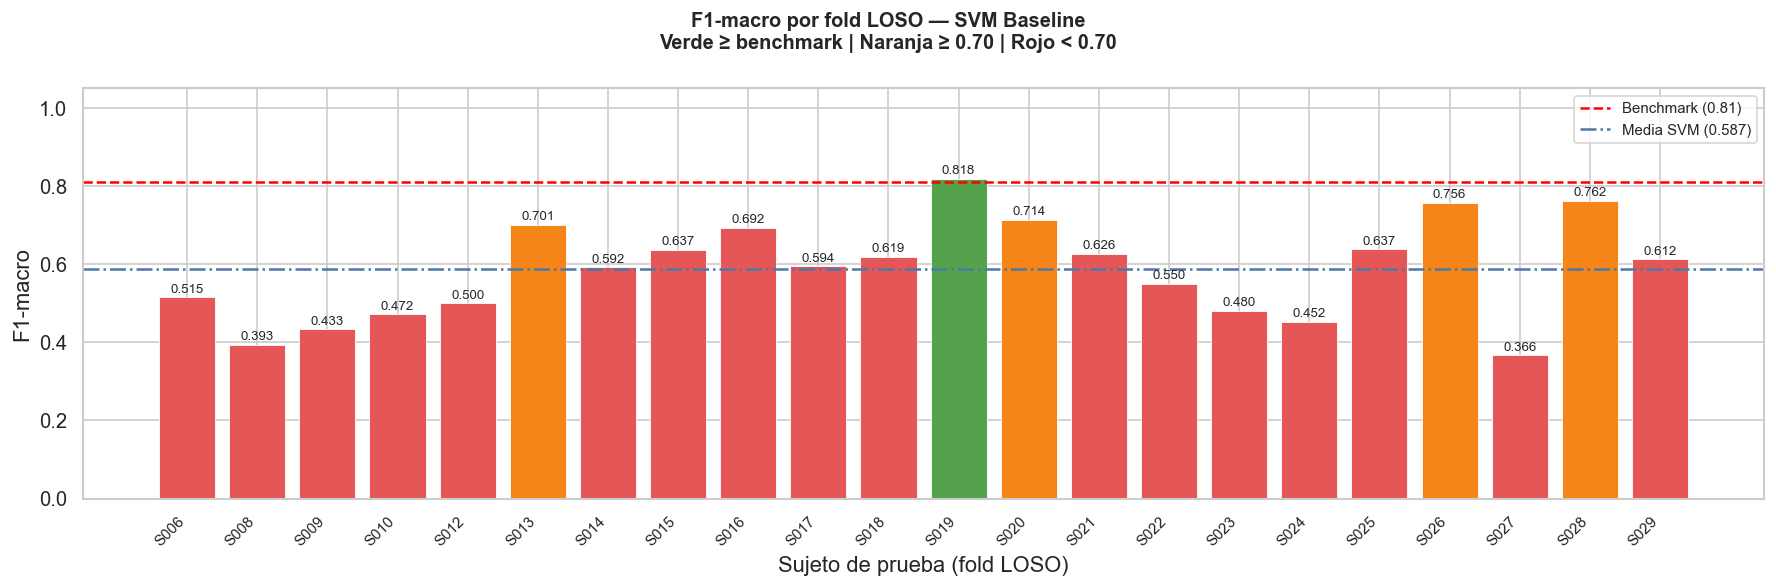

  💾 Figura guardada: results\svm\svm_f1_per_fold.png


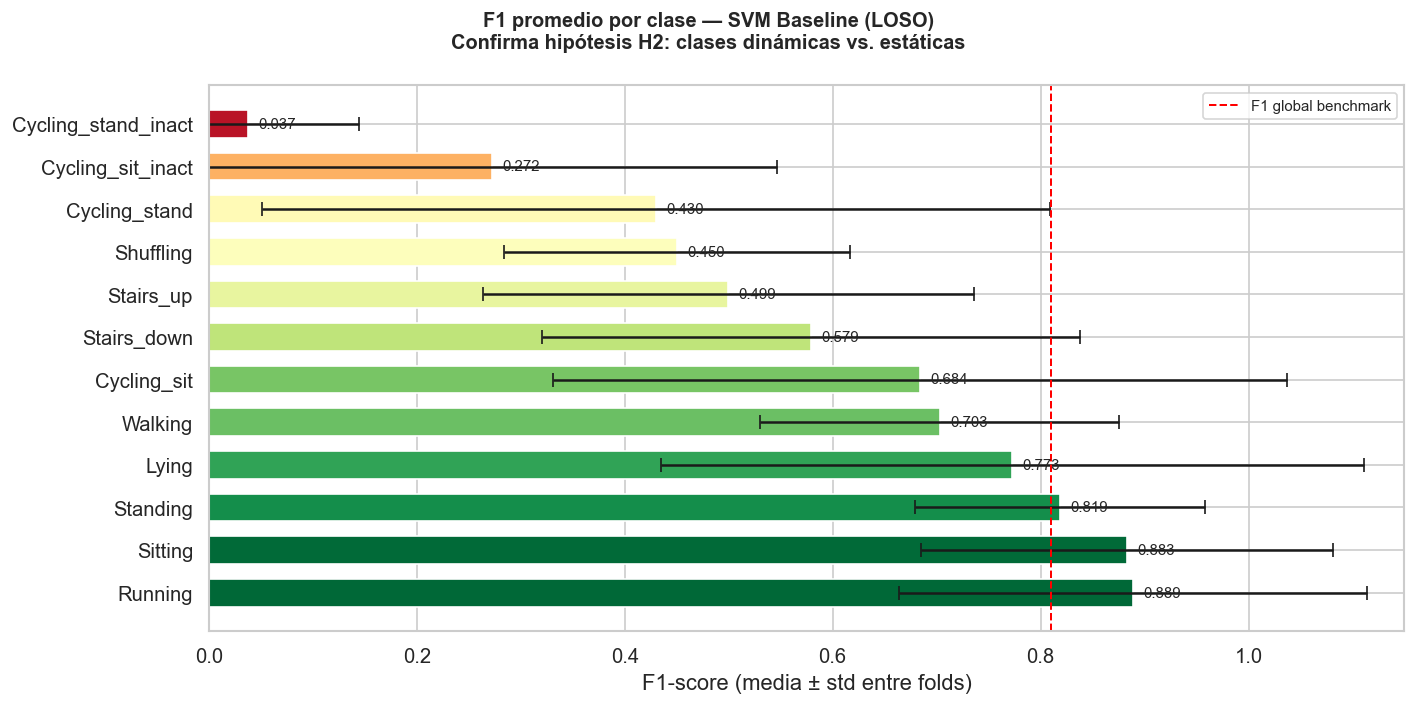

  💾 Figura guardada: results\svm\svm_f1_per_class.png


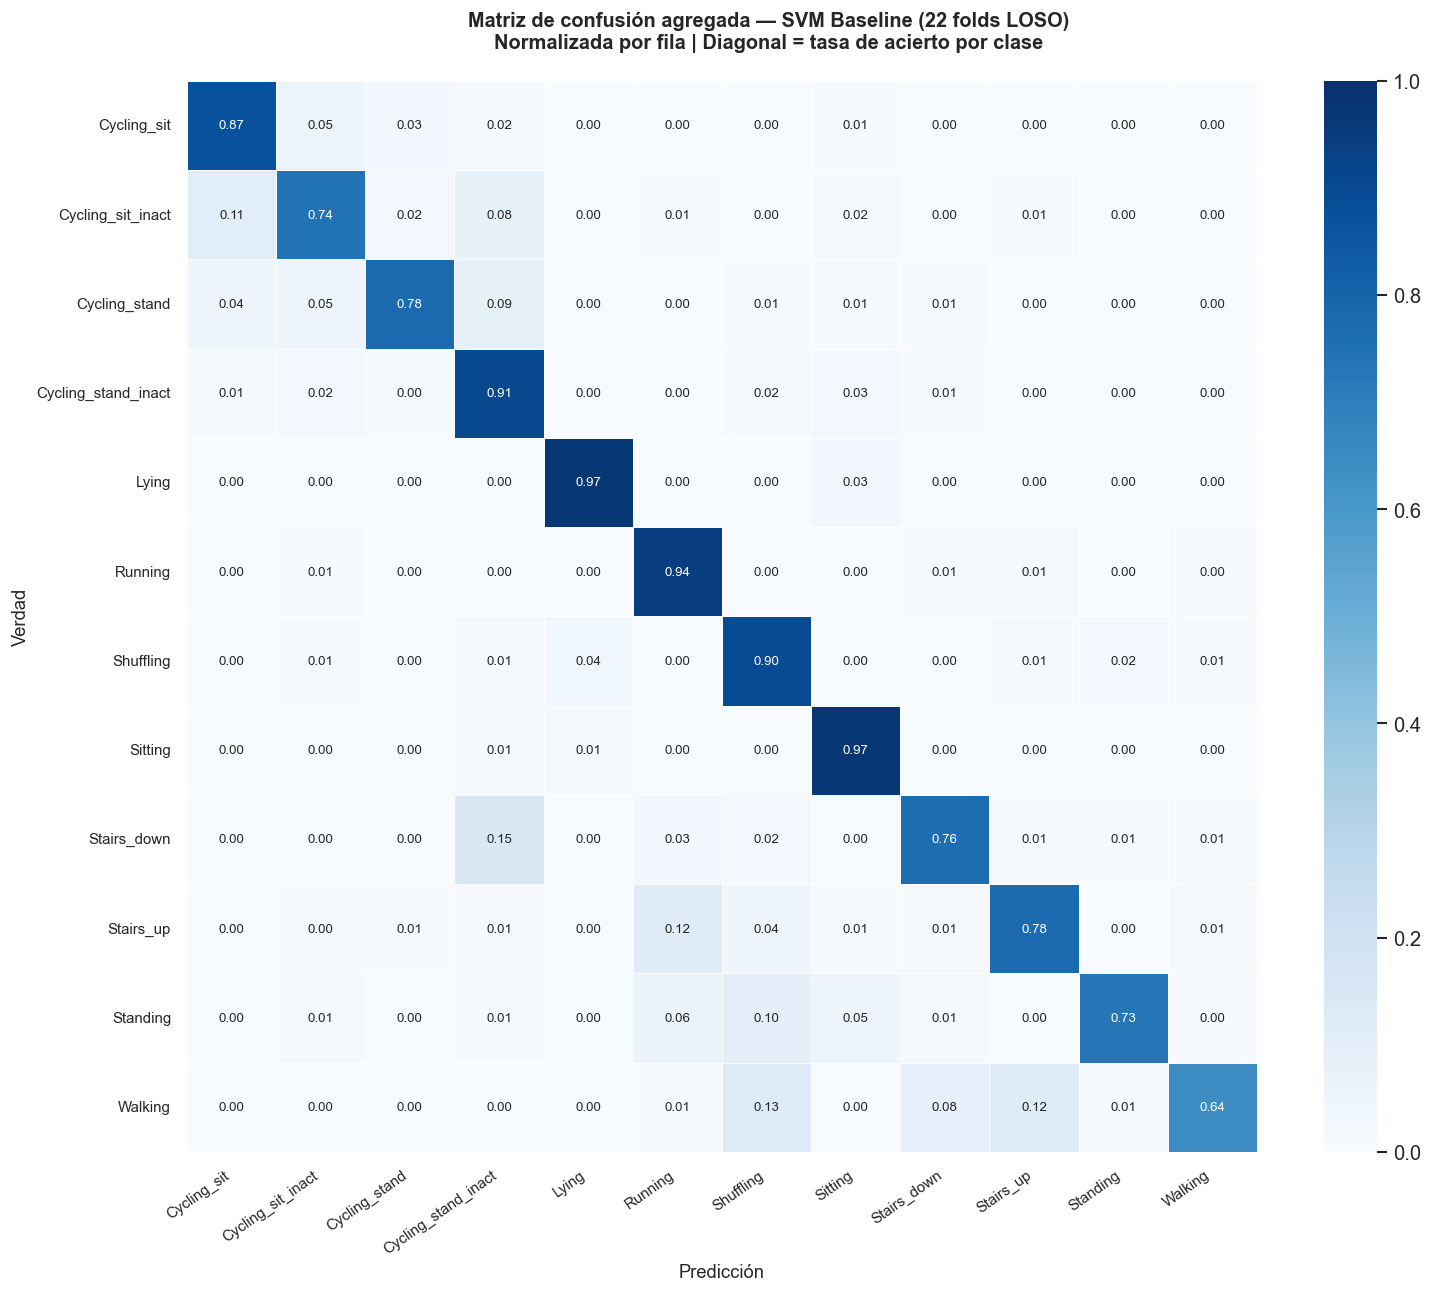

  💾 Figura guardada: results\svm\svm_confusion_matrix.png

📋 Tabla de métricas por fold:


,Sujeto test,F1-macro,Precision,Recall,Accuracy,Tiempo (s)
0,S006,0.5150,0.5273,0.6530,0.7821,352.2
1,S008,0.3933,0.4025,0.5288,0.9201,353.3
2,S009,0.4331,0.4632,0.5120,0.8794,361.8
3,S010,0.4716,0.4528,0.5631,0.7914,357.0
4,S012,0.5000,0.5376,0.5366,0.9514,355.5
5,S013,0.7005,0.7304,0.7193,0.8911,355.4
6,S014,0.5917,0.6114,0.6180,0.8956,355.6
7,S015,0.6367,0.6441,0.6881,0.8730,361.9
8,S016,0.6923,0.6740,0.7875,0.9231,353.6
9,S017,0.5940,0.5916,0.6257,0.8767,351.4



✔ Celda 9 ejecutada — SVM Baseline completado.


In [13]:
# ============================================================
# CELDA 9: SVM Baseline — Replicación del benchmark HARTH
# ============================================================
# Referencia: Logacjov et al. (2021) — F1-macro=0.81 bajo LOSO
#
# Pipeline:
#   FoldResult (X_train/X_test shape: N×150×6)
#       └─► FeatureExtractor  →  X_feat (N × n_features)
#               └─► SVMClassifier (RBF, class_weight='balanced')
#                       └─► métricas por fold + agregadas
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import time
import json
from pathlib import Path
from dataclasses import dataclass, field
from typing import Optional

from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    accuracy_score, classification_report,
    confusion_matrix
)
from IPython.display import display


# ════════════════════════════════════════════════════════════
# PARTE 1: Extractor de Features Manuales
# ════════════════════════════════════════════════════════════

class FeatureExtractor:
    """
    Extrae un vector de features estadísticas por ventana,
    replicando el enfoque clásico de HAR para alimentar al SVM.

    Features extraídas por canal (×6 canales = 6 × 11 = 66 features):
        mean, std, min, max, rms, p25, p75, skewness,
        kurtosis, zero_crossing_rate, range

    Features de correlación cruzada back↔thigh (×3 ejes = 3 features):
        pearson_r entre back_x↔thigh_x, back_y↔thigh_y, back_z↔thigh_z

    Total: 66 + 3 = 69 features por ventana.

    Parámetros
    ----------
    signal_cols : list[str]
        Nombre de los 6 canales en el mismo orden que X[..., :]
    sampling_rate : int
        Frecuencia de muestreo en Hz (para ZCR normalizado).
    """

    # Índices de canales para correlación cruzada
    _BACK_IDX  = [0, 1, 2]   # back_x, back_y, back_z
    _THIGH_IDX = [3, 4, 5]   # thigh_x, thigh_y, thigh_z

    def __init__(
        self,
        signal_cols: list[str] = SIGNAL_COLS,
        sampling_rate: int = SAMPLING_RATE,
    ):
        self.signal_cols   = signal_cols
        self.sampling_rate = sampling_rate
        self.feature_names = self._build_feature_names()

    def _build_feature_names(self) -> list[str]:
        """Construye los nombres de features para interpretabilidad."""
        per_channel = ["mean", "std", "min", "max", "rms",
                       "p25", "p75", "skew", "kurt", "zcr", "range"]
        names = [f"{col}_{feat}"
                 for col in self.signal_cols
                 for feat in per_channel]
        axes = ["x", "y", "z"]
        names += [f"corr_back_thigh_{ax}" for ax in axes]
        return names

    # ── Features por canal ────────────────────────────────────
    @staticmethod
    def _channel_features(x: np.ndarray) -> np.ndarray:
        """
        Calcula 11 features estadísticas para un único canal.

        Parámetros
        ----------
        x : np.ndarray, shape (window_size,)
        """
        mean   = np.mean(x)
        std    = np.std(x, ddof=0)
        mn     = np.min(x)
        mx     = np.max(x)
        rms    = np.sqrt(np.mean(x ** 2))
        p25    = np.percentile(x, 25)
        p75    = np.percentile(x, 75)
        # Skewness manual (evita importar scipy en este contexto)
        skew   = np.mean(((x - mean) / (std + 1e-8)) ** 3)
        kurt   = np.mean(((x - mean) / (std + 1e-8)) ** 4) - 3.0
        # Zero Crossing Rate: cruces por cero normalizados
        zcr    = np.sum(np.diff(np.sign(x - mean)) != 0) / len(x)
        rng    = mx - mn
        return np.array([mean, std, mn, mx, rms,
                         p25, p75, skew, kurt, zcr, rng],
                        dtype=np.float32)

    # ── Correlación cruzada back↔thigh ────────────────────────
    @staticmethod
    def _cross_corr(window: np.ndarray) -> np.ndarray:
        """
        Coeficiente de Pearson entre back y thigh por cada eje.
        Captura la coordinación entre los dos sensores, útil
        para distinguir actividades de ciclismo vs. marcha.
        """
        corrs = []
        for b_idx, t_idx in zip(
            FeatureExtractor._BACK_IDX,
            FeatureExtractor._THIGH_IDX
        ):
            b = window[:, b_idx]
            t = window[:, t_idx]
            # Pearson robusto frente a varianza cero
            denom = (np.std(b) * np.std(t) + 1e-8)
            corrs.append(
                np.mean((b - b.mean()) * (t - t.mean())) / denom
            )
        return np.array(corrs, dtype=np.float32)

    # ── Extracción sobre una ventana ──────────────────────────
    def extract_window(self, window: np.ndarray) -> np.ndarray:
        """
        Extrae el vector de features de una única ventana.

        Parámetros
        ----------
        window : np.ndarray, shape (window_size, n_channels)

        Retorna
        -------
        np.ndarray, shape (n_features,)
        """
        channel_feats = np.concatenate(
            [self._channel_features(window[:, c])
             for c in range(window.shape[1])]
        )
        cross_feats = self._cross_corr(window)
        return np.concatenate([channel_feats, cross_feats])

    # ── Extracción sobre un tensor completo ───────────────────
    def transform(self, X: np.ndarray) -> np.ndarray:
        """
        Extrae features para todas las ventanas del tensor.

        Parámetros
        ----------
        X : np.ndarray, shape (N, window_size, n_channels)

        Retorna
        -------
        np.ndarray, shape (N, n_features)
        """
        return np.vstack(
            [self.extract_window(X[i]) for i in range(len(X))]
        ).astype(np.float32)

    @property
    def n_features(self) -> int:
        return len(self.feature_names)


# ════════════════════════════════════════════════════════════
# PARTE 2: Resultados por Fold
# ════════════════════════════════════════════════════════════

@dataclass
class SVMFoldMetrics:
    """
    Métricas de evaluación de un único fold SVM.

    Atributos
    ----------
    fold_id : int
    test_subject : str
    f1_macro : float       — métrica principal (H1)
    precision_macro : float
    recall_macro : float
    accuracy : float
    f1_per_class : dict    — F1 por actividad
    conf_matrix : np.ndarray
    label_encoder : LabelEncoder
    elapsed_sec : float
    """
    fold_id:         int
    test_subject:    str
    f1_macro:        float
    precision_macro: float
    recall_macro:    float
    accuracy:        float
    f1_per_class:    dict
    conf_matrix:     np.ndarray
    label_encoder:   LabelEncoder
    elapsed_sec:     float


# ════════════════════════════════════════════════════════════
# PARTE 3: Clase SVM Baseline
# ════════════════════════════════════════════════════════════

class SVMBaseline:
    """
    Entrena y evalúa un SVM con kernel RBF sobre los folds LOSO
    pre-preparados, usando features manuales estadísticas.

    Reproduce la configuración del paper base de HARTH
    (Logacjov et al., 2021) para obtener el benchmark de
    F1-macro ≈ 0.81 bajo validación leave-one-subject-out.

    Parámetros
    ----------
    loso_folds : list[FoldResult]
        Lista de folds generados por LOSOPipeline.run().
    output_dir : str | Path
        Directorio donde se guardarán métricas y figuras.
    svm_C : float
        Parámetro de regularización del SVM.
    svm_gamma : str | float
        Kernel coefficient ('scale' o 'auto' recomendados).
    verbose : bool
        Imprime resumen de cada fold en el notebook.
    """

    def __init__(
        self,
        loso_folds: list,
        output_dir: str | Path = "results/svm",
        svm_C: float = 1.0,
        svm_gamma: str = "scale",
        verbose: bool = True,
    ):
        self.loso_folds  = loso_folds
        self.output_dir  = Path(output_dir)
        self.svm_C       = svm_C
        self.svm_gamma   = svm_gamma
        self.verbose     = verbose
        self.extractor   = FeatureExtractor()
        self.fold_metrics: list[SVMFoldMetrics] = []
        self.output_dir.mkdir(parents=True, exist_ok=True)

        print(f"⚙️  SVM configurado: C={svm_C}, gamma={svm_gamma}, "
              f"kernel=RBF, class_weight='balanced'")
        print(f"📐 Features por ventana: {self.extractor.n_features}")

    # ── Entrenamiento y evaluación de un fold ─────────────────
    def _run_fold(self, fold) -> SVMFoldMetrics:
        """
        Para un FoldResult:
        1. Extrae features manuales de X_train y X_test
        2. Entrena SVM con class_weight='balanced'
        3. Predice y calcula métricas completas
        """
        t0 = time.time()

        # ── Extracción de features ────────────────────────────
        X_tr_feat = self.extractor.transform(fold.X_train)
        X_te_feat = self.extractor.transform(fold.X_test)

        # ── Entrenamiento SVM ─────────────────────────────────
        svm = SVC(
            C            = self.svm_C,
            kernel       = "rbf",
            gamma        = self.svm_gamma,
            class_weight = "balanced",
            decision_function_shape = "ovr",
            random_state = 42,
        )
        svm.fit(X_tr_feat, fold.y_train)

        # ── Predicción ────────────────────────────────────────
        y_pred = svm.predict(X_te_feat)
        le     = fold.label_encoder

        # ── Filtrar etiquetas -1 (clases no vistas en train) ──
        valid_mask = fold.y_test >= 0
        y_true_v   = fold.y_test[valid_mask]
        y_pred_v   = y_pred[valid_mask]

        # ── Métricas globales ─────────────────────────────────
        labels_present = np.unique(
            np.concatenate([y_true_v, y_pred_v])
        )
        f1_mac  = f1_score(y_true_v, y_pred_v,
                           average="macro", zero_division=0)
        prec    = precision_score(y_true_v, y_pred_v,
                                  average="macro", zero_division=0)
        rec     = recall_score(y_true_v, y_pred_v,
                               average="macro", zero_division=0)
        acc     = accuracy_score(y_true_v, y_pred_v)

        # ── F1 por clase ──────────────────────────────────────
        f1_classes = f1_score(y_true_v, y_pred_v,
                              average=None, zero_division=0,
                              labels=labels_present)
        f1_per_class = {
            le.classes_[c]: round(float(f), 3)
            for c, f in zip(labels_present, f1_classes)
        }

        # ── Matriz de confusión ───────────────────────────────
        cm = confusion_matrix(y_true_v, y_pred_v,
                              labels=labels_present)

        return SVMFoldMetrics(
            fold_id         = fold.fold_id,
            test_subject    = fold.test_subject,
            f1_macro        = round(float(f1_mac), 4),
            precision_macro = round(float(prec), 4),
            recall_macro    = round(float(rec), 4),
            accuracy        = round(float(acc), 4),
            f1_per_class    = f1_per_class,
            conf_matrix     = cm,
            label_encoder   = le,
            elapsed_sec     = round(time.time() - t0, 1),
        )

    # ── Impresión de resumen por fold ─────────────────────────
    @staticmethod
    def _print_fold(m: SVMFoldMetrics) -> None:
        icon = "✅" if m.f1_macro >= 0.75 else \
               "⚠️ " if m.f1_macro >= 0.60 else "❌"
        print(f"  {icon} Fold {m.fold_id:02d} | {m.test_subject} | "
              f"F1={m.f1_macro:.4f}  P={m.precision_macro:.4f}  "
              f"R={m.recall_macro:.4f}  Acc={m.accuracy:.4f}  "
              f"({m.elapsed_sec:.0f}s)")

    # ── Loop LOSO completo ────────────────────────────────────
    def run(self) -> "SVMBaseline":
        """
        Itera sobre todos los folds LOSO, entrena y evalúa
        el SVM en cada uno, y acumula los resultados.
        """
        n = len(self.loso_folds)
        print(f"\n🚀 Iniciando SVM Baseline — {n} folds LOSO...\n")

        for fold in self.loso_folds:
            metrics = self._run_fold(fold)
            self.fold_metrics.append(metrics)
            if self.verbose:
                self._print_fold(metrics)

        self._save_results()
        self._print_global_summary()
        return self

    # ── Resumen global ────────────────────────────────────────
    def _print_global_summary(self) -> None:
        """Imprime las métricas promediadas sobre los 22 folds."""
        f1s  = [m.f1_macro        for m in self.fold_metrics]
        prec = [m.precision_macro for m in self.fold_metrics]
        rec  = [m.recall_macro    for m in self.fold_metrics]
        acc  = [m.accuracy        for m in self.fold_metrics]

        print(f"\n{'='*60}")
        print(f"  📊  RESULTADOS GLOBALES — SVM BASELINE (LOSO)")
        print(f"{'='*60}")
        print(f"  F1-macro  (mean ± std) : "
              f"{np.mean(f1s):.4f} ± {np.std(f1s):.4f}")
        print(f"  Precision (mean ± std) : "
              f"{np.mean(prec):.4f} ± {np.std(prec):.4f}")
        print(f"  Recall    (mean ± std) : "
              f"{np.mean(rec):.4f} ± {np.std(rec):.4f}")
        print(f"  Accuracy  (mean ± std) : "
              f"{np.mean(acc):.4f} ± {np.std(acc):.4f}")
        print(f"\n  Benchmark paper (Logacjov et al., 2021):")
        print(f"  F1=0.81 | P=0.79 | R=0.85")
        diff = np.mean(f1s) - 0.81
        symbol = "▲" if diff >= 0 else "▼"
        print(f"\n  Diferencia vs. benchmark: {symbol}{abs(diff):.4f}")
        print(f"{'='*60}")

    # ── Guardado de resultados ────────────────────────────────
    def _save_results(self) -> None:
        """Guarda métricas por fold en CSV."""
        rows = []
        for m in self.fold_metrics:
            row = {
                "fold_id":       m.fold_id,
                "test_subject":  m.test_subject,
                "f1_macro":      m.f1_macro,
                "precision":     m.precision_macro,
                "recall":        m.recall_macro,
                "accuracy":      m.accuracy,
                "elapsed_sec":   m.elapsed_sec,
            }
            row.update({f"f1_{k}": v
                        for k, v in m.f1_per_class.items()})
            rows.append(row)
        df = pd.DataFrame(rows)
        path = self.output_dir / "svm_fold_results.csv"
        df.to_csv(path, index=False)
        print(f"\n  💾 Resultados guardados en: {path}")

    # ────────────────────────────────────────────────────────
    # VISUALIZACIONES
    # ────────────────────────────────────────────────────────

    def plot_f1_per_fold(self) -> None:
        """
        Barras de F1-macro por sujeto de prueba, con línea
        de referencia del benchmark (0.81). Inline + guardado.
        """
        subjects = [m.test_subject for m in self.fold_metrics]
        f1s      = [m.f1_macro     for m in self.fold_metrics]
        colors   = ["#54A24B" if f >= 0.81
                    else "#F58518" if f >= 0.70
                    else "#E45756" for f in f1s]
        mean_f1  = np.mean(f1s)

        fig, ax = plt.subplots(figsize=(15, 5))
        bars = ax.bar(subjects, f1s, color=colors,
                      edgecolor="white", linewidth=0.5)
        ax.axhline(0.81, color="red", linestyle="--",
                   linewidth=1.5, label="Benchmark (0.81)")
        ax.axhline(mean_f1, color="#4C78A8", linestyle="-.",
                   linewidth=1.5, label=f"Media SVM ({mean_f1:.3f})")
        for bar, f in zip(bars, f1s):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.005,
                    f"{f:.3f}", ha="center", va="bottom", fontsize=8)
        ax.set_ylim(0, 1.05)
        ax.set_xlabel("Sujeto de prueba (fold LOSO)")
        ax.set_ylabel("F1-macro")
        ax.legend(fontsize=9)
        plt.xticks(rotation=45, ha="right", fontsize=9)
        fig.suptitle(
            "F1-macro por fold LOSO — SVM Baseline\n"
            "Verde ≥ benchmark | Naranja ≥ 0.70 | Rojo < 0.70",
            fontsize=12, fontweight="bold"
        )
        plt.tight_layout()
        path = self.output_dir / "svm_f1_per_fold.png"
        fig.savefig(path, bbox_inches="tight", dpi=120)
        plt.show()
        print(f"  💾 Figura guardada: {path}")

    def plot_f1_per_class(self) -> None:
        """
        F1 promedio por clase de actividad (media entre folds),
        con barra de error (std). Revela las H2 clases fáciles/difíciles.
        """
        all_classes = sorted({k for m in self.fold_metrics
                               for k in m.f1_per_class})
        means, stds = [], []
        for cls in all_classes:
            vals = [m.f1_per_class.get(cls, np.nan)
                    for m in self.fold_metrics]
            vals = [v for v in vals if not np.isnan(v)]
            means.append(np.mean(vals) if vals else 0)
            stds.append(np.std(vals)   if vals else 0)

        # Ordenar por F1 descendente
        order  = np.argsort(means)[::-1]
        cls_s  = [all_classes[i] for i in order]
        mean_s = [means[i]       for i in order]
        std_s  = [stds[i]        for i in order]
        colors = plt.cm.RdYlGn(
            [m / (max(mean_s) + 1e-6) for m in mean_s]
        )

        fig, ax = plt.subplots(figsize=(12, 6))
        bars = ax.barh(cls_s, mean_s, xerr=std_s, capsize=4,
                       color=colors, edgecolor="white", height=0.65)
        ax.axvline(0.81, color="red", linestyle="--",
                   linewidth=1.2, label="F1 global benchmark")
        for bar, m_val in zip(bars, mean_s):
            ax.text(bar.get_width() + 0.01,
                    bar.get_y() + bar.get_height() / 2,
                    f"{m_val:.3f}", va="center", fontsize=9)
        ax.set_xlim(0, 1.15)
        ax.set_xlabel("F1-score (media ± std entre folds)")
        ax.legend(fontsize=9)
        fig.suptitle(
            "F1 promedio por clase — SVM Baseline (LOSO)\n"
            "Confirma hipótesis H2: clases dinámicas vs. estáticas",
            fontsize=12, fontweight="bold"
        )
        plt.tight_layout()
        path = self.output_dir / "svm_f1_per_class.png"
        fig.savefig(path, bbox_inches="tight", dpi=120)
        plt.show()
        print(f"  💾 Figura guardada: {path}")

    def plot_confusion_matrix_aggregate(self) -> None:
        """
        Matriz de confusión agregada (suma de todos los folds),
        normalizada por fila para mostrar tasas de clasificación.
        """
        # Reunir todas las clases presentes
        all_classes = sorted({k for m in self.fold_metrics
                               for k in m.f1_per_class})
        n = len(all_classes)
        cm_total = np.zeros((n, n), dtype=np.int64)

        for m in self.fold_metrics:
            le  = m.label_encoder
            cm  = m.conf_matrix
            # Mapear clases del fold a índices globales
            fold_classes = [
                le.classes_[i]
                for i in range(len(le.classes_))
                if le.classes_[i] in all_classes
            ]
            for i, ci in enumerate(fold_classes):
                for j, cj in enumerate(fold_classes):
                    gi = all_classes.index(ci)
                    gj = all_classes.index(cj)
                    if i < cm.shape[0] and j < cm.shape[1]:
                        cm_total[gi, gj] += cm[i, j]

        # Normalizar por fila
        row_sums = cm_total.sum(axis=1, keepdims=True)
        cm_norm  = np.divide(cm_total, row_sums,
                             where=row_sums > 0,
                             out=np.zeros_like(cm_total, dtype=float))

        fig, ax = plt.subplots(figsize=(13, 11))
        sns.heatmap(
            cm_norm, annot=True, fmt=".2f",
            xticklabels=all_classes, yticklabels=all_classes,
            cmap="Blues", vmin=0, vmax=1,
            linewidths=0.3, linecolor="white",
            ax=ax, annot_kws={"size": 8}
        )
        ax.set_xlabel("Predicción", fontsize=11)
        ax.set_ylabel("Verdad",     fontsize=11)
        plt.xticks(rotation=35, ha="right", fontsize=9)
        plt.yticks(rotation=0,  fontsize=9)
        fig.suptitle(
            "Matriz de confusión agregada — SVM Baseline (22 folds LOSO)\n"
            "Normalizada por fila | Diagonal = tasa de acierto por clase",
            fontsize=12, fontweight="bold"
        )
        plt.tight_layout()
        path = self.output_dir / "svm_confusion_matrix.png"
        fig.savefig(path, bbox_inches="tight", dpi=120)
        plt.show()
        print(f"  💾 Figura guardada: {path}")

    # ── Genera todas las visualizaciones ─────────────────────
    def plot_all(self) -> None:
        """Ejecuta las tres visualizaciones en secuencia."""
        print("\n📊 Generando visualizaciones del SVM Baseline...\n")
        self.plot_f1_per_fold()
        self.plot_f1_per_class()
        self.plot_confusion_matrix_aggregate()

    # ── Tabla de métricas por fold (inline en notebook) ───────
    def summary_table(self) -> pd.DataFrame:
        """
        Retorna un DataFrame formateado con las métricas
        de todos los folds para display en el notebook.
        """
        rows = [{
            "Sujeto test":  m.test_subject,
            "F1-macro":     m.f1_macro,
            "Precision":    m.precision_macro,
            "Recall":       m.recall_macro,
            "Accuracy":     m.accuracy,
            "Tiempo (s)":   m.elapsed_sec,
        } for m in self.fold_metrics]
        df = pd.DataFrame(rows)
        # Fila de promedios
        avg_row = pd.DataFrame([{
            "Sujeto test": "── PROMEDIO ──",
            "F1-macro":    round(df["F1-macro"].mean(), 4),
            "Precision":   round(df["Precision"].mean(), 4),
            "Recall":      round(df["Recall"].mean(), 4),
            "Accuracy":    round(df["Accuracy"].mean(), 4),
            "Tiempo (s)":  round(df["Tiempo (s)"].sum(), 1),
        }])
        return pd.concat([df, avg_row], ignore_index=True)


# ════════════════════════════════════════════════════════════
# EJECUCIÓN
# ════════════════════════════════════════════════════════════

# ⚠️  El SVM RBF sobre ~6-8M ventanas de entrenamiento puede
#     tardar 3–8 min por fold en CPU estándar.
#     Para un test rápido, ejecuta primero solo 1 fold:
#
#     svm_baseline._run_fold(loso_folds[0])  ← prueba 1 fold

svm_baseline = SVMBaseline(
    loso_folds = loso_folds,
    output_dir = "./results/svm",
    svm_C      = 1.0,
    svm_gamma  = "scale",
    verbose    = True,
)

# ── Opción A: correr UN fold para verificar antes del LOSO completo ──
# m_test = svm_baseline._run_fold(loso_folds[0])
# svm_baseline._print_fold(m_test)

# ── Opción B: LOSO completo (recomendado) ─────────────────────────────
svm_baseline.run()

# ── Visualizaciones inline + guardado ────────────────────────────────
svm_baseline.plot_all()

# ── Tabla de resultados por fold ──────────────────────────────────────
print("\n📋 Tabla de métricas por fold:")
display(svm_baseline.summary_table())

print("\n✔ Celda 9 ejecutada — SVM Baseline completado.")

In [20]:
# ============================================================
# CELDA 10: Modelo CNN 1D para HARTH (Keras + GPU)
# ============================================================
# Requisitos previos:
#   - haber ejecutado las Celdas 6–8 (master_df, WindowSegmenter,
#     LOSOPipeline) y tener disponible `loso_folds`.
#
# Objetivo:
#   - Definir una CNN 1D base que sirva como punto de partida
#     para posteriores mejoras (añadir BiLSTM, GRU, etc.).
#   - El diseño está pensado específicamente para:
#       * secuencias cortas (150 timesteps = 3 s a 50 Hz)
#       * 6 canales (acelerómetros back + thigh)
#       * problema fuertemente desbalanceado
# ============================================================

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, callbacks

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


def build_cnn1d_harth(
    input_shape=(150, 6),
    n_classes=12,
    base_filters=64,
    dropout_rate=0.5
) -> keras.Model:
    """
    Construye una CNN 1D para reconocimiento de actividades
    en HARTH.

    Diseño de la arquitectura (justificación):
    ------------------------------------------
    1) Bloques Conv1D + BatchNorm + ReLU + MaxPool
       - Las convoluciones 1D capturan patrones locales
         en el tiempo (micro-patrones de pasos, ciclos
         de pedaleo) en cada canal y combinaciones de canales.
       - BatchNorm estabiliza la distribución de activaciones
         entre batches, facilitando el entrenamiento y
         permitiendo usar learning rates más altos.
       - ReLU evita saturación y permite gradientes más estables.
       - MaxPool reduce la longitud temporal, incrementa
         el campo receptivo sin aumentar excesivamente los
         parámetros y aporta invariancia temporal local.

    2) GlobalAveragePooling1D
       - Resume la información temporal en un vector fijo
         por canal de filtros, evitando tener que usar una
         capa Flatten enorme.
       - Reduce el riesgo de overfitting y mantiene la
         estructura de “resumen por feature temporal”.

    3) Capa densa intermedia + Dropout
       - Proporciona una representación compacta de alto
         nivel antes de la clasificación.
       - Dropout combate el overfitting, especialmente
         Problemático con datos desbalanceados.

    4) Capa de salida Softmax
       - Produce probabilidades sobre las 12 actividades,
         necesaria para usar CrossEntropy o Focal Loss.

    Parámetros
    ----------
    input_shape : tuple
        (timesteps, n_channels). Por defecto (150, 6).
    n_classes : int
        Número de clases (12 en HARTH).
    base_filters : int
        Número de filtros del primer bloque Conv1D.
    dropout_rate : float
        Dropout antes de la capa de salida.

    Retorna
    -------
    keras.Model
        Modelo compilado listo para entrenar.
    """
    inputs = keras.Input(shape=input_shape)

    # ── Bloque 1 ─────────────────────────────────────────────
    x = layers.Conv1D(
        filters=base_filters,
        kernel_size=5,
        padding="same",
        activation=None
    )(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)

    # ── Bloque 2 ─────────────────────────────────────────────
    x = layers.Conv1D(
        filters=base_filters * 2,
        kernel_size=5,
        padding="same",
        activation=None
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)

    # ── Bloque 3 (opcional, más capacidad) ───────────────────
    x = layers.Conv1D(
        filters=base_filters * 2,
        kernel_size=3,
        padding="same",
        activation=None
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)

    # ── Pooling global ───────────────────────────────────────
    x = layers.GlobalAveragePooling1D()(x)

    # ── Capa densa + Dropout ────────────────────────────────
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(dropout_rate)(x)

    # ── Capa de salida ───────────────────────────────────────
    outputs = layers.Dense(n_classes, activation="softmax")(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name="cnn1d_harth_base")

    # Optimizador y compilación:
    # - Adam es robusto a escalas de gradiente diversas
    # - lr inicial moderado (1e-3) + ReduceLROnPlateau en el loop LOSO
    optimizer = optimizers.Adam(learning_rate=1e-3)

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=[
            "accuracy"
            
        ],
    )

    return model


# ── Ejemplo rápido: instanciar y ver el summary ─────────────
example_fold = loso_folds[0]
input_shape = example_fold.X_train.shape[1:]  # (150, 6)
n_classes   = len(example_fold.label_encoder.classes_)

cnn_model = build_cnn1d_harth(
    input_shape=input_shape,
    n_classes=n_classes,
    base_filters=64,
    dropout_rate=0.5,
)

cnn_model.summary()
print("\n✔ Celda 10 ejecutada — Modelo CNN 1D definido.")

TensorFlow version: 2.21.0
GPU available: []


Model: "cnn1d_harth_base"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 150, 6)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ (None, 150, 64)        │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 150, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_6 (ReLU)                  │ (None, 150, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_6 (MaxPooling1D)  │ (None, 75, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 75, 128)        │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 75, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_7 (ReLU)                  │ (None, 75, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_7 (MaxPooling1D)  │ (None, 37, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_8 (Conv1D)               │ (None, 37, 128)        │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 37, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_8 (ReLU)                  │ (None, 37, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_8 (MaxPooling1D)  │ (None, 18, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 12)             │         1,548 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,692 (436.30 KB)

 Trainable params: 111,052 (433.80 KB)

 Non-trainable params: 640 (2.50 KB)


✔ Celda 10 ejecutada — Modelo CNN 1D definido.


In [21]:
# ============================================================
# CELDA 11: Entrenamiento LOSO de la CNN 1D (Keras + GPU)
# ============================================================
# Objetivo:
#   - Entrenar un modelo CNN 1D independiente por fold LOSO.
#   - Usar class_weight para combatir el desbalance.
#   - Guardar:
#       * pesos del modelo por fold
#       * history (loss, accuracy, etc.)
#       * métricas por fold (F1, precision, recall, accuracy)
#   - Implementar "save points":
#       * si vuelves a ejecutar la celda, puede saltar folds
#         ya entrenados (según archivos guardados).
# ============================================================

import os
import numpy as np
from pathlib import Path
from collections import defaultdict

from sklearn.metrics import (
    f1_score, precision_score, recall_score, accuracy_score
)

# Directorio base para resultados de la CNN
CNN_RESULTS_DIR = Path("./results/cnn1d")
CNN_RESULTS_DIR.mkdir(parents=True, exist_ok=True)


def train_single_fold_cnn(
    fold,
    fold_idx: int,
    base_results_dir: Path = CNN_RESULTS_DIR,
    epochs: int = 30,
    batch_size: int = 256,
    patience: int = 5,
) -> dict:
    """
    Entrena la CNN 1D en un único fold LOSO.

    Parámetros
    ----------
    fold : FoldResult
        Objeto generado por LOSOPipeline.
    fold_idx : int
        Índice de fold (1..22).
    base_results_dir : Path
        Directorio base donde se guardan modelos y métricas.
    epochs : int
        Máximo número de epochs.
    batch_size : int
        Tamaño de batch.
    patience : int
        Paciencia para EarlyStopping (en epochs).

    Retorna
    -------
    dict
        Métricas del fold (F1, Precision, Recall, Accuracy, etc.).
    """
    fold_dir = base_results_dir / f"fold_{fold_idx:02d}_{fold.test_subject}"
    fold_dir.mkdir(parents=True, exist_ok=True)

    model_path   = fold_dir / "cnn1d_best.keras"
    history_path = fold_dir / "history.npy"
    metrics_path = fold_dir / "metrics.json"

    # ── Save point: si ya existe el modelo y métricas, saltamos ──
    if model_path.exists() and metrics_path.exists():
        print(f"  ↪ Fold {fold_idx:02d} ({fold.test_subject}) ya entrenado — se omite.")
        import json
        return json.loads(metrics_path.read_text(encoding="utf-8"))

    # ── Datos ────────────────────────────────────────────────
    X_train, y_train = fold.X_train, fold.y_train
    X_test,  y_test  = fold.X_test,  fold.y_test

    input_shape = X_train.shape[1:]
    n_classes   = len(fold.label_encoder.classes_)

    # ── Modelo nuevo por fold ────────────────────────────────
    model = build_cnn1d_harth(
        input_shape=input_shape,
        n_classes=n_classes,
        base_filters=64,
        dropout_rate=0.5,
    )

    # ── Callbacks: EarlyStopping + ReduceLROnPlateau + Checkpoint ─
    cb_early = callbacks.EarlyStopping(
        monitor="val_loss",
        patience=patience,
        restore_best_weights=True,
        verbose=1,
    )
    cb_reduce_lr = callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=max(1, patience // 2),
        min_lr=1e-5,
        verbose=1,
    )
    cb_checkpoint = callbacks.ModelCheckpoint(
        filepath=str(model_path),
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=False,
        verbose=1,
    )

    # Keras espera class_weight como dict {clase_entera: peso}
    class_weight = fold.class_weights

    print(f"\n🔁 Entrenando CNN 1D — Fold {fold_idx:02d}/22 | Test: {fold.test_subject}")
    print(f"   X_train: {X_train.shape}, X_test: {X_test.shape}")
    print(f"   Clases: {fold.label_encoder.classes_}")
    print(f"   class_weight: {class_weight}")

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_test, y_test),
        epochs=epochs,
        batch_size=batch_size,
        class_weight=class_weight,
        callbacks=[cb_early, cb_reduce_lr, cb_checkpoint],
        verbose=2,
    )

    # Guardar history como numpy (para plots posteriores)
    np.save(history_path, history.history)

    # ── Evaluación final (usando el mejor modelo guardado) ───
    # Recargar el mejor modelo del fold
    best_model = keras.models.load_model(model_path)

    # Predicciones sobre X_test
    y_proba = best_model.predict(X_test, batch_size=batch_size, verbose=0)
    y_pred  = np.argmax(y_proba, axis=1)

    # Filtrar posibles etiquetas -1 (clases no vistas en train)
    valid_mask = y_test >= 0
    y_true_v   = y_test[valid_mask]
    y_pred_v   = y_pred[valid_mask]

    f1_mac = f1_score(y_true_v, y_pred_v,
                      average="macro", zero_division=0)
    prec   = precision_score(y_true_v, y_pred_v,
                             average="macro", zero_division=0)
    rec    = recall_score(y_true_v, y_pred_v,
                          average="macro", zero_division=0)
    acc    = accuracy_score(y_true_v, y_pred_v)

    metrics = {
        "fold_id":       fold_idx,
        "test_subject":  fold.test_subject,
        "f1_macro":      float(round(f1_mac, 4)),
        "precision":     float(round(prec, 4)),
        "recall":        float(round(rec, 4)),
        "accuracy":      float(round(acc, 4)),
        "n_train":       int(fold.n_train_windows),
        "n_test":        int(fold.n_test_windows),
        "class_weights": {int(k): float(v) for k, v in class_weight.items()},
    }

    # Guardar métricas a disco
    import json
    metrics_path.write_text(
        json.dumps(metrics, indent=2), encoding="utf-8"
    )

    print(f"   ✅ Fold {fold_idx:02d} | {fold.test_subject} | "
          f"F1={metrics['f1_macro']:.4f}  P={metrics['precision']:.4f}  "
          f"R={metrics['recall']:.4f}  Acc={metrics['accuracy']:.4f}")

    return metrics


# ════════════════════════════════════════════════════════════
# ENTRENAMIENTO LOSO COMPLETO DE LA CNN 1D
# ════════════════════════════════════════════════════════════

cnn_metrics_all = []

for i, fold in enumerate(loso_folds, start=1):
    metrics = train_single_fold_cnn(
        fold       = fold,
        fold_idx   = i,
        epochs     = 30,     # puedes ajustar luego
        batch_size = 256,    # ideal para GPU
        patience   = 5,
    )
    cnn_metrics_all.append(metrics)

# ── Resumen global de la CNN 1D ─────────────────────────────
cnn_df = pd.DataFrame(cnn_metrics_all).set_index("fold_id")
cnn_df.to_csv(CNN_RESULTS_DIR / "cnn1d_fold_results.csv", index=True)

print("\n📋 Resultados por fold — CNN 1D:")
display(cnn_df)

print("\n📊 Métricas globales CNN 1D:")
print(f"  F1-macro  (mean ± std): "
      f"{cnn_df['f1_macro'].mean():.4f} ± {cnn_df['f1_macro'].std():.4f}")
print(f"  Precision (mean ± std): "
      f"{cnn_df['precision'].mean():.4f} ± {cnn_df['precision'].std():.4f}")
print(f"  Recall    (mean ± std): "
      f"{cnn_df['recall'].mean():.4f} ± {cnn_df['recall'].std():.4f}")
print(f"  Accuracy  (mean ± std): "
      f"{cnn_df['accuracy'].mean():.4f} ± {cnn_df['accuracy'].std():.4f}")

print(f"\n💾 Métricas guardadas en: {CNN_RESULTS_DIR / 'cnn1d_fold_results.csv'}")
print("✔ Celda 11 ejecutada — Entrenamiento LOSO CNN 1D completado (o retomado).")


🔁 Entrenando CNN 1D — Fold 01/22 | Test: S006
   X_train: (79521, 150, 6), X_test: (5378, 150, 6)
   Clases: ['Cycling_sit' 'Cycling_sit_inact' 'Cycling_stand' 'Cycling_stand_inact'
 'Lying' 'Running' 'Shuffling' 'Sitting' 'Stairs_down' 'Stairs_up'
 'Standing' 'Walking']
   class_weight: {0: 1.3479963384865745, 1: 16.650125628140703, 2: 9.466785714285715, 3: 66.2675, 4: 1.2381819880418534, 5: 1.7096878224974201, 6: 2.5438579654510556, 7: 0.18880705453302182, 8: 6.80364476386037, 9: 6.124537892791127, 10: 0.7400882287245923, 11: 0.42847213241950083}
Epoch 1/30

Epoch 1: val_loss improved from None to 0.65141, saving model to results\cnn1d\fold_01_S006\cnn1d_best.keras
311/311 - 29s - 93ms/step - accuracy: 0.8006 - loss: 0.8898 - val_accuracy: 0.8193 - val_loss: 0.6514 - learning_rate: 0.0010
Epoch 2/30

Epoch 2: val_loss improved from 0.65141 to 0.62387, saving model to results\cnn1d\fold_01_S006\cnn1d_best.keras
311/311 - 25s - 81ms/step - accuracy: 0.8833 - loss: 0.5156 - val_accurac

,test_subject,f1_macro,precision,recall,accuracy,n_train,n_test,class_weights
fold_id,,,,,,,,
1,S006,0.7032,0.7107,0.7698,0.9011,79521,5378,"{0: 1.3479963384865745, 1: 16.650125628140703,..."
2,S008,0.4524,0.4484,0.5839,0.9252,79391,5508,"{0: 1.2841453157349896, 1: 12.117063492063492,..."
3,S009,0.6851,0.7104,0.7349,0.8994,82851,2048,"{0: 1.8926123903508771, 1: 16.757888349514563,..."
4,S010,0.6235,0.6207,0.6461,0.8386,80240,4659,"{0: 1.273165778116273, 1: 12.179720704310869, ..."
5,S012,0.8022,0.7980,0.8193,0.9774,79863,5036,"{0: 1.2671839299314547, 1: 12.122495446265939,..."
6,S013,0.6271,0.6585,0.6214,0.8975,80078,4821,"{0: 1.2793647750511248, 1: 12.199573430834857,..."
7,S014,0.5798,0.6263,0.5912,0.8975,80138,4761,"{0: 1.2892213642213641, 1: 12.164238008500304,..."
8,S015,0.7209,0.7139,0.7302,0.9471,79394,5505,"{0: 1.2834464920788877, 1: 12.05130540376442, ..."
9,S016,0.8255,0.8082,0.8636,0.9526,80232,4667,"{0: 1.3076471738705262, 1: 12.223034734917734,..."



📊 Métricas globales CNN 1D:
  F1-macro  (mean ± std): 0.6922 ± 0.1063
  Precision (mean ± std): 0.7091 ± 0.0984
  Recall    (mean ± std): 0.7299 ± 0.1068
  Accuracy  (mean ± std): 0.9154 ± 0.0448

💾 Métricas guardadas en: results\cnn1d\cnn1d_fold_results.csv
✔ Celda 11 ejecutada — Entrenamiento LOSO CNN 1D completado (o retomado).


In [22]:
# ============================================================
# CELDA 12: CNN 1D + BiLSTM para HARTH
# ============================================================
# Motivación del cambio frente a CNN base (Celda 10–11):
#
#   La CNN 1D con GlobalAveragePooling1D "aplana" el tiempo:
#   resume toda la secuencia en un vector de estadísticas,
#   perdiendo el ORDEN en que ocurrieron los patrones.
#
#   Actividades como Walking, Stairs o Shuffling no solo
#   tienen una firma espectral local, sino un patrón de
#   TRANSICIÓN temporal (p. ej., el peso se desplaza entre
#   pasos). Un BiLSTM lee esa secuencia en ambas direcciones
#   y puede capturar esas dependencias de largo plazo.
#
# Estructura de la arquitectura:
#
#   INPUT (150, 6)
#     │
#   [BLOQUE CNN] × 2          ← extrae micro-patrones locales
#     Conv1D → BN → ReLU → MaxPool
#     │
#   Sequence (37, 128)        ← mantiene el orden temporal
#     │
#   [BiLSTM]                  ← captura dependencias bidireccionales
#     │
#   Dense → Dropout → Softmax
# ============================================================

import numpy as np
import pandas as pd
import json
import time
import os
from pathlib import Path

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, callbacks
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    accuracy_score, classification_report, confusion_matrix
)
from IPython.display import display


# ════════════════════════════════════════════════════════════
# PARTE 1: Definición del modelo CNN 1D + BiLSTM
# ════════════════════════════════════════════════════════════

def build_cnn_lstm_harth(
    input_shape=(150, 6),
    n_classes=12,
    base_filters=64,
    lstm_units=128,
    dropout_rate=0.4,
) -> keras.Model:
    """
    CNN 1D + BiLSTM para clasificación de actividades humanas.

    Diseño por capas y justificación
    ──────────────────────────────────────────────────────────

    BLOQUE CNN (×2 con MaxPool):
    ────────────────────────────
    Conv1D(64, kernel_size=5, padding='same')
        - Detecta micro-patrones en ventanas de 5 timesteps
          (= 100 ms a 50 Hz). Suficiente para capturar un
          semiciclo de paso (~0.1–0.2 s).
        - padding='same' conserva la longitud temporal para
          que MaxPool reduzca de forma controlada.
    BatchNormalization
        - Normaliza las activaciones dentro del batch,
          permitiendo learning rates más altos sin divergir.
        - Especialmente útil con datos desbalanceados donde
          los gradientes de clases raras son muy pequeños.
    ReLU
        - No linealidad estándar; evita saturación en
          activaciones positivas.
    MaxPool(pool_size=2)
        - Reduce longitud temporal a la mitad: 150→75→37.
        - Aporta invariancia temporal local (un paso no
          siempre empieza en el mismo timestep).
        - Amplía el campo receptivo del bloque siguiente.

    Conv1D(128, kernel_size=5, padding='same')
        - El doble de filtros detecta combinaciones de los
          patrones locales del bloque anterior.
        - Equivale a patrones de nivel medio: ciclo completo
          de pasos, patrón de pedaleo, transición de escalera.
    BatchNormalization + ReLU + MaxPool(2)
        - Misma lógica. Ahora la secuencia tiene 37 pasos
          y 128 features por paso → lista para el BiLSTM.

    BLOQUE BiLSTM:
    ──────────────
    Bidirectional(LSTM(lstm_units))
        - LSTM(128 unidades):
            * Mantiene una celda de estado que "recuerda"
              contexto largo: útil para distinguir Shuffling
              (pasos irregulares continuos) de Walking.
            * Las puertas Forget/Input/Output aprenden
              selectivamente qué olvidar y qué retener.
        - Bidirectional:
            * Pasa la secuencia de izquierda→derecha Y
              derecha→izquierda, concatenando los estados
              finales (2 × 128 = 256 features).
            * Beneficio para HAR: la detección de "bajada
              de escalera" depende tanto del contexto
              pasado como del futuro dentro de la ventana.
        - return_sequences=False: solo nos interesa el
          vector de contexto final, no toda la secuencia.

    CAPA DENSA + DROPOUT:
    ─────────────────────
    Dense(128, activation='relu')
        - Proyección compacta que combina las 256 features
          del BiLSTM en representaciones de alto nivel.
    Dropout(0.4)
        - Con clases desbalanceadas, el modelo tiende a
          memorizar patrones de las clases mayoritarias.
          Dropout obliga a usar múltiples caminos de decisión.

    SALIDA:
    ───────
    Dense(n_classes, activation='softmax')
        - Distribución de probabilidad sobre 12 clases.
        - Compatible con sparse_categorical_crossentropy
          (etiquetas enteras, no one-hot).

    Parámetros
    ──────────
    input_shape : tuple
        (timesteps, n_channels). Por defecto (150, 6).
    n_classes : int
        Número de clases de actividad.
    base_filters : int
        Filtros del primer bloque Conv1D. El segundo usa ×2.
    lstm_units : int
        Unidades por dirección del BiLSTM.
        Total de features tras BiLSTM = lstm_units × 2.
    dropout_rate : float
        Fracción de neuronas desactivadas antes de la salida.

    Retorna
    ───────
    keras.Model
        Modelo compilado.
    """
    inputs = keras.Input(shape=input_shape, name="input_sensor")

    # ── Bloque CNN 1 ─────────────────────────────────────────
    x = layers.Conv1D(
        filters     = base_filters,
        kernel_size = 5,
        padding     = "same",
        use_bias    = False,        # BN compensa el bias
        name        = "conv1"
    )(inputs)
    x = layers.BatchNormalization(name="bn1")(x)
    x = layers.ReLU(name="relu1")(x)
    x = layers.MaxPooling1D(pool_size=2, name="pool1")(x)
    # Forma: (None, 75, 64)

    # ── Bloque CNN 2 ─────────────────────────────────────────
    x = layers.Conv1D(
        filters     = base_filters * 2,
        kernel_size = 5,
        padding     = "same",
        use_bias    = False,
        name        = "conv2"
    )(x)
    x = layers.BatchNormalization(name="bn2")(x)
    x = layers.ReLU(name="relu2")(x)
    x = layers.MaxPooling1D(pool_size=2, name="pool2")(x)
    # Forma: (None, 37, 128)

    # ── BiLSTM ───────────────────────────────────────────────
    x = layers.Bidirectional(
        layers.LSTM(
            units            = lstm_units,
            return_sequences = False,    # solo estado final
            dropout          = 0.2,      # dropout interno del LSTM
            recurrent_dropout= 0.0,      # evitar lentitud en GPU
        ),
        merge_mode = "concat",           # [fw; bw] → 256 features
        name       = "bilstm"
    )(x)
    # Forma: (None, 256)

    # ── Capa densa ───────────────────────────────────────────
    x = layers.Dense(128, activation="relu", name="dense1")(x)
    x = layers.Dropout(dropout_rate, name="dropout")(x)

    # ── Salida ───────────────────────────────────────────────
    outputs = layers.Dense(
        n_classes,
        activation = "softmax",
        name       = "output"
    )(x)

    model = keras.Model(
        inputs  = inputs,
        outputs = outputs,
        name    = "cnn1d_bilstm_harth"
    )

    model.compile(
        optimizer = optimizers.Adam(learning_rate=1e-3),
        loss      = "sparse_categorical_crossentropy",
        metrics   = ["accuracy"],
    )

    return model


# ── Verificación rápida ───────────────────────────────────────
example_fold = loso_folds[0]
input_shape  = example_fold.X_train.shape[1:]  # (150, 6)
n_classes    = len(example_fold.label_encoder.classes_)

test_model = build_cnn_lstm_harth(
    input_shape  = input_shape,
    n_classes    = n_classes,
    base_filters = 64,
    lstm_units   = 128,
    dropout_rate = 0.4,
)

test_model.summary()

print(f"\n  Parámetros totales: "
      f"{test_model.count_params():,}")
print(f"  Dispositivos GPU disponibles: "
      f"{tf.config.list_physical_devices('GPU')}")

print("\n✔ Arquitectura CNN 1D + BiLSTM definida correctamente.")


# ════════════════════════════════════════════════════════════
# PARTE 2: Entrenamiento LOSO con save points
# ════════════════════════════════════════════════════════════

CNN_LSTM_RESULTS_DIR = Path("./results/cnn1d_bilstm")
CNN_LSTM_RESULTS_DIR.mkdir(parents=True, exist_ok=True)


def train_single_fold_cnn_lstm(
    fold,
    fold_idx:        int,
    base_results_dir: Path = CNN_LSTM_RESULTS_DIR,
    epochs:          int   = 40,
    batch_size:      int   = 256,
    patience:        int   = 7,
    base_filters:    int   = 64,
    lstm_units:      int   = 128,
    dropout_rate:    float = 0.4,
) -> dict:
    """
    Entrena CNN 1D + BiLSTM en un fold LOSO.

    Save point:
        Si `cnn_lstm_best.keras` y `metrics.json` ya existen
        en el directorio del fold, se carga el resultado
        anterior y se omite el entrenamiento. Para reentrenar
        un fold concreto, borra su carpeta y vuelve a ejecutar.

    Parámetros
    ──────────
    fold : FoldResult
        Generado por LOSOPipeline.
    fold_idx : int
        Número de fold dentro de LOSO (1..22).
    base_results_dir : Path
        Directorio raíz de resultados CNN+BiLSTM.
    epochs : int
        Máximo de epochs (EarlyStopping puede terminar antes).
    batch_size : int
        Tamaño de batch (256 aprovecha bien la GPU).
    patience : int
        Paciencia para EarlyStopping y ReduceLROnPlateau.
    base_filters : int
        Filtros del primer bloque Conv1D.
    lstm_units : int
        Unidades BiLSTM por dirección.
    dropout_rate : float
        Dropout antes de la capa de salida.

    Retorna
    ───────
    dict
        Métricas del fold.
    """
    fold_dir = (base_results_dir
                / f"fold_{fold_idx:02d}_{fold.test_subject}")
    fold_dir.mkdir(parents=True, exist_ok=True)

    model_path   = fold_dir / "cnn_lstm_best.keras"
    history_path = fold_dir / "history.npy"
    metrics_path = fold_dir / "metrics.json"
    report_path  = fold_dir / "classification_report.txt"
    cm_path      = fold_dir / "confusion_matrix.npy"

    # ── Save point ────────────────────────────────────────────
    if model_path.exists() and metrics_path.exists():
        print(f"  ↪ Fold {fold_idx:02d} ({fold.test_subject}) "
              f"ya entrenado — cargando resultado previo.")
        return json.loads(metrics_path.read_text(encoding="utf-8"))

    # ── Datos ────────────────────────────────────────────────
    X_train, y_train = fold.X_train, fold.y_train
    X_test,  y_test  = fold.X_test,  fold.y_test
    le               = fold.label_encoder
    n_classes_fold   = len(le.classes_)

    # ── Modelo ───────────────────────────────────────────────
    model = build_cnn_lstm_harth(
        input_shape  = X_train.shape[1:],
        n_classes    = n_classes_fold,
        base_filters = base_filters,
        lstm_units   = lstm_units,
        dropout_rate = dropout_rate,
    )

    # ── Callbacks ────────────────────────────────────────────
    cb_early = callbacks.EarlyStopping(
        monitor             = "val_loss",
        patience            = patience,
        restore_best_weights= True,
        verbose             = 1,
    )
    cb_reduce_lr = callbacks.ReduceLROnPlateau(
        monitor   = "val_loss",
        factor    = 0.5,
        patience  = max(2, patience // 2),
        min_lr    = 1e-6,
        verbose   = 1,
    )
    cb_checkpoint = callbacks.ModelCheckpoint(
        filepath       = str(model_path),
        monitor        = "val_loss",
        save_best_only = True,
        verbose        = 0,
    )
    cb_logger = callbacks.CSVLogger(
        str(fold_dir / "training_log.csv"),
        append = False,
    )

    print(f"\n{'─'*60}")
    print(f"  🔁 Fold {fold_idx:02d}/22 | Test: {fold.test_subject}")
    print(f"  X_train: {X_train.shape} | X_test: {X_test.shape}")
    print(f"  Clases en test: {list(le.classes_)}")
    print(f"{'─'*60}")

    t0 = time.time()

    history = model.fit(
        X_train,
        y_train,
        validation_data = (X_test, y_test),
        epochs          = epochs,
        batch_size      = batch_size,
        class_weight    = fold.class_weights,
        callbacks       = [cb_early, cb_reduce_lr,
                           cb_checkpoint, cb_logger],
        verbose         = 2,
    )

    elapsed = round(time.time() - t0, 1)

    # Guardar history
    np.save(history_path, history.history)

    # ── Evaluación con el mejor modelo guardado ───────────────
    best_model = keras.models.load_model(model_path)
    y_proba    = best_model.predict(
        X_test, batch_size=batch_size, verbose=0
    )
    y_pred     = np.argmax(y_proba, axis=1)

    # Filtrar etiquetas -1 si las hay
    valid_mask = y_test >= 0
    y_true_v   = y_test[valid_mask]
    y_pred_v   = y_pred[valid_mask]

    labels_present = np.unique(
        np.concatenate([y_true_v, y_pred_v])
    )

    # ── Métricas globales ─────────────────────────────────────
    f1_mac = f1_score(y_true_v, y_pred_v,
                      average="macro", zero_division=0)
    prec   = precision_score(y_true_v, y_pred_v,
                             average="macro", zero_division=0)
    rec    = recall_score(y_true_v, y_pred_v,
                          average="macro", zero_division=0)
    acc    = accuracy_score(y_true_v, y_pred_v)

    # ── F1 por clase ──────────────────────────────────────────
    f1_vals = f1_score(
        y_true_v, y_pred_v,
        average     = None,
        zero_division= 0,
        labels      = labels_present
    )
    f1_per_class = {
        le.classes_[c]: round(float(v), 4)
        for c, v in zip(labels_present, f1_vals)
    }

    # ── Guardar classification report ─────────────────────────
    report = classification_report(
        y_true_v, y_pred_v,
        labels       = labels_present,
        target_names = [le.classes_[i] for i in labels_present],
        zero_division= 0,
    )
    report_path.write_text(
        f"Fold {fold_idx:02d} — {fold.test_subject}\n\n{report}",
        encoding="utf-8"
    )

    # ── Guardar matriz de confusión ───────────────────────────
    cm = confusion_matrix(
        y_true_v, y_pred_v, labels=labels_present
    )
    np.save(cm_path, cm)

    # ── Métricas completas a JSON ─────────────────────────────
    metrics = {
        "fold_id":        fold_idx,
        "test_subject":   fold.test_subject,
        "f1_macro":       round(float(f1_mac), 4),
        "precision":      round(float(prec), 4),
        "recall":         round(float(rec), 4),
        "accuracy":       round(float(acc), 4),
        "elapsed_sec":    elapsed,
        "n_train":        int(len(y_train)),
        "n_test":         int(len(y_test)),
        "epochs_run":     len(history.history["loss"]),
        "f1_per_class":   f1_per_class,
        "hyperparams": {
            "base_filters":  base_filters,
            "lstm_units":    lstm_units,
            "dropout_rate":  dropout_rate,
            "batch_size":    batch_size,
            "max_epochs":    epochs,
            "patience":      patience,
        },
    }
    metrics_path.write_text(
        json.dumps(metrics, indent=2), encoding="utf-8"
    )

    icon = ("✅" if f1_mac >= 0.80
            else "⚠️ " if f1_mac >= 0.65
            else "❌")
    print(f"  {icon} Fold {fold_idx:02d} | {fold.test_subject} | "
          f"F1={f1_mac:.4f}  P={prec:.4f}  R={rec:.4f}  "
          f"Acc={acc:.4f}  epochs={metrics['epochs_run']}  "
          f"({elapsed:.0f}s)")

    return metrics


# ════════════════════════════════════════════════════════════
# PARTE 3: Loop LOSO completo
# ════════════════════════════════════════════════════════════

print("\n🚀 Iniciando CNN 1D + BiLSTM — 22 folds LOSO\n")

cnn_lstm_metrics_all = []

for i, fold in enumerate(loso_folds, start=1):
    metrics = train_single_fold_cnn_lstm(
        fold             = fold,
        fold_idx         = i,
        base_results_dir = CNN_LSTM_RESULTS_DIR,
        epochs           = 40,
        batch_size       = 256,
        patience         = 7,
        base_filters     = 64,
        lstm_units       = 128,
        dropout_rate     = 0.4,
    )
    cnn_lstm_metrics_all.append(metrics)


# ════════════════════════════════════════════════════════════
# PARTE 4: Resumen global + comparativo con CNN base
# ════════════════════════════════════════════════════════════

df_lstm = pd.DataFrame(cnn_lstm_metrics_all)
df_lstm.to_csv(
    CNN_LSTM_RESULTS_DIR / "cnn_lstm_fold_results.csv",
    index=False
)

# ── Cargar resultados CNN base si existen ─────────────────────
cnn_base_csv = Path("./results/cnn1d/cnn1d_fold_results.csv")
df_cnn       = pd.read_csv(cnn_base_csv) if cnn_base_csv.exists() \
               else None

# ── Resumen por consola ───────────────────────────────────────
print(f"\n{'='*65}")
print(f"  📊  CNN 1D + BiLSTM — RESULTADOS GLOBALES (LOSO)")
print(f"{'='*65}")
print(f"  F1-macro  (mean ± std): "
      f"{df_lstm['f1_macro'].mean():.4f} ± "
      f"{df_lstm['f1_macro'].std():.4f}")
print(f"  Precision (mean ± std): "
      f"{df_lstm['precision'].mean():.4f} ± "
      f"{df_lstm['precision'].std():.4f}")
print(f"  Recall    (mean ± std): "
      f"{df_lstm['recall'].mean():.4f} ± "
      f"{df_lstm['recall'].std():.4f}")
print(f"  Accuracy  (mean ± std): "
      f"{df_lstm['accuracy'].mean():.4f} ± "
      f"{df_lstm['accuracy'].std():.4f}")

if df_cnn is not None:
    diff = df_lstm['f1_macro'].mean() - df_cnn['f1_macro'].mean()
    sym  = "▲" if diff >= 0 else "▼"
    print(f"\n  vs. CNN base           : "
          f"{sym}{abs(diff):.4f} "
          f"({df_cnn['f1_macro'].mean():.4f} → "
          f"{df_lstm['f1_macro'].mean():.4f})")

diff_bench = df_lstm['f1_macro'].mean() - 0.81
sym_bench  = "▲" if diff_bench >= 0 else "▼"
diff_svm   = df_lstm['f1_macro'].mean() - 0.5873
sym_svm    = "▲" if diff_svm >= 0 else "▼"
print(f"  vs. SVM V1 (0.587)     : {sym_svm}{abs(diff_svm):.4f}")
print(f"  vs. Benchmark (0.81)   : {sym_bench}{abs(diff_bench):.4f}")
print(f"{'='*65}")


# ── Tabla comparativa por fold ────────────────────────────────
print("\n📋 Comparativo por fold — CNN base vs CNN+BiLSTM:\n")

rows_cmp = []
for _, row in df_lstm.iterrows():
    subject = row["test_subject"]
    f1_lstm = row["f1_macro"]
    f1_base = (df_cnn.loc[df_cnn["test_subject"] == subject,
                           "f1_macro"].values[0]
               if df_cnn is not None else None)
    delta   = (round(f1_lstm - f1_base, 4)
               if f1_base is not None else None)
    arrow   = ("▲" if delta and delta > 0 else
               "▼" if delta and delta < 0 else "—")
    rows_cmp.append({
        "Sujeto":        subject,
        "CNN base":      round(f1_base, 4) if f1_base else "—",
        "CNN+BiLSTM":    round(f1_lstm, 4),
        "Δ F1-macro":    f"{arrow}{abs(delta):.4f}" if delta else "—",
        "Precision":     row["precision"],
        "Recall":        row["recall"],
        "Accuracy":      row["accuracy"],
        "Epochs":        row.get("epochs_run", "—"),
    })

df_cmp = pd.DataFrame(rows_cmp)
df_cmp.to_csv(
    CNN_LSTM_RESULTS_DIR / "comparison_cnn_vs_cnnlstm.csv",
    index=False
)
display(df_cmp)

print(f"\n💾 Resultados guardados en: {CNN_LSTM_RESULTS_DIR}/")
print("✔ Celda 12 ejecutada — CNN 1D + BiLSTM completado (o retomado).")

Model: "cnn1d_bilstm_harth"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_sensor (InputLayer)       │ (None, 150, 6)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv1D)                  │ (None, 150, 64)        │         1,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 150, 64)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu1 (ReLU)                    │ (None, 150, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling1D)            │ (None, 75, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv1D)                  │ (None, 75, 128)        │        40,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 75, 128)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu2 (ReLU)                    │ (None, 75, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling1D)            │ (None, 37, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm (Bidirectional)          │ (None, 256)            │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 12)             │         1,548 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 341,260 (1.30 MB)

 Trainable params: 340,876 (1.30 MB)

 Non-trainable params: 384 (1.50 KB)


  Parámetros totales: 341,260
  Dispositivos GPU disponibles: []

✔ Arquitectura CNN 1D + BiLSTM definida correctamente.

🚀 Iniciando CNN 1D + BiLSTM — 22 folds LOSO


────────────────────────────────────────────────────────────
  🔁 Fold 01/22 | Test: S006
  X_train: (79521, 150, 6) | X_test: (5378, 150, 6)
  Clases en test: [np.str_('Cycling_sit'), np.str_('Cycling_sit_inact'), np.str_('Cycling_stand'), np.str_('Cycling_stand_inact'), np.str_('Lying'), np.str_('Running'), np.str_('Shuffling'), np.str_('Sitting'), np.str_('Stairs_down'), np.str_('Stairs_up'), np.str_('Standing'), np.str_('Walking')]
────────────────────────────────────────────────────────────
Epoch 1/40
311/311 - 55s - 178ms/step - accuracy: 0.7740 - loss: 0.8784 - val_accuracy: 0.8481 - val_loss: 0.4632 - learning_rate: 0.0010
Epoch 2/40
311/311 - 50s - 161ms/step - accuracy: 0.8607 - loss: 0.5518 - val_accuracy: 0.8959 - val_loss: 0.3715 - learning_rate: 0.0010
Epoch 3/40
311/311 - 49s - 159ms/step - accuracy: 0.890

,Sujeto,CNN base,CNN+BiLSTM,Δ F1-macro,Precision,Recall,Accuracy,Epochs
0,S006,0.7032,0.6985,▼0.0047,0.6913,0.7690,0.9028,14
1,S008,0.4524,0.4137,▼0.0387,0.4085,0.5015,0.9281,22
2,S009,0.6851,0.4565,▼0.2286,0.4603,0.5428,0.8926,13
3,S010,0.6235,0.6488,▲0.0253,0.6345,0.6761,0.8927,22
4,S012,0.8022,0.8115,▲0.0093,0.8028,0.8341,0.9825,19
5,S013,0.6271,0.6877,▲0.0606,0.7063,0.6965,0.9060,15
6,S014,0.5798,0.5903,▲0.0105,0.6362,0.5883,0.8992,18
7,S015,0.7209,0.7887,▲0.0678,0.7809,0.8074,0.9384,14
8,S016,0.8255,0.8757,▲0.0502,0.8803,0.9063,0.9616,12
9,S017,0.6051,0.6587,▲0.0536,0.6748,0.6535,0.9135,22



💾 Resultados guardados en: results\cnn1d_bilstm/
✔ Celda 12 ejecutada — CNN 1D + BiLSTM completado (o retomado).


In [14]:
# ============================================================
# CELDA 13: HAR Transformer — Encoder para clasificación
#            de actividades sobre señales IMU (PyTorch + GPU)
# ============================================================
#
# ¿Por qué Transformer sobre CNN+BiLSTM?
# ──────────────────────────────────────────────────────────
# El BiLSTM procesa la secuencia de forma SECUENCIAL:
# para saber qué ocurre en el timestep t=100, el modelo
# tiene que haber procesado todos los anteriores.
# El Transformer usa SELF-ATTENTION global: en una sola
# operación matricial, el timestep t=100 puede "ver" y
# pesarse con cualquier otro timestep (0, 37, 149...).
#
# Para HAR esto es crítico en actividades como:
#   - Cycling: el patrón de un semiciclo confirma el siguiente
#   - Stairs: la deceleración al final del tramo
#   - Walking→Standing: la transición posee un patrón global
#
# Ventajas adicionales en GPU:
#   - Self-attention es 100% paralelizable (no hay estado
#     recurrente que deba calcularse paso a paso).
#   - En GPU, el Transformer entrena 3–5x más rápido que
#     el BiLSTM para el mismo número de parámetros.
#
# Arquitectura:
#
#  INPUT (B, 150, 6)
#    │
#    Linear(6 → d_model=128)         ← proyección de canales
#    │
#    + PositionalEncoding (aprendido) ← posición en el tiempo
#    │
#    TransformerEncoder × 4 capas
#      ├─ MultiHeadAttention (8 heads, d_k=16) ← atención global
#      ├─ Add & LayerNorm
#      ├─ FeedForward (128→256→128)
#      └─ Add & LayerNorm
#    │
#    GlobalAveragePooling(dim=1)      ← (B, 128)
#    │
#    LayerNorm → Dense(128) → GELU → Dropout(0.3)
#    │
#    Dense(n_classes) → Softmax
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import numpy as np
import pandas as pd
import json
import time
from pathlib import Path
from sklearn.metrics import (
    f1_score, precision_score, recall_score, accuracy_score
)
from IPython.display import display

# ── Dispositivo ───────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"  Dispositivo: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    print(f"  VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")


# ════════════════════════════════════════════════════════════
# PARTE 1: Dataset y DataLoader
# ════════════════════════════════════════════════════════════

class HARTHWindowDataset(Dataset):
    """
    Dataset PyTorch para ventanas segmentadas de HARTH.

    Parámetros
    ──────────
    X : np.ndarray, shape (N, window_size, n_channels)
    y : np.ndarray, shape (N,) — etiquetas enteras
    """
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


def make_weighted_sampler(y: np.ndarray) -> WeightedRandomSampler:
    """
    Crea un WeightedRandomSampler para balancear clases
    durante el entrenamiento. Más robusto que class_weight
    en PyTorch para datasets muy desbalanceados.
    """
    class_counts = np.bincount(y)
    # Peso por clase = inverso de frecuencia
    class_weights = 1.0 / (class_counts + 1e-6)
    # Peso por muestra
    sample_weights = class_weights[y]
    sampler = WeightedRandomSampler(
        weights     = torch.tensor(sample_weights, dtype=torch.double),
        num_samples = len(y),
        replacement = True,
    )
    return sampler


# ════════════════════════════════════════════════════════════
# PARTE 2: Arquitectura del Transformer
# ════════════════════════════════════════════════════════════

class LearnedPositionalEncoding(nn.Module):
    """
    Codificación posicional APRENDIDA.
    A diferencia de la sinusoidal (fija), este embedding
    aprende representaciones posicionales específicas para
    los patrones temporales de señales IMU.
    """
    def __init__(self, max_len: int, d_model: int, dropout: float = 0.1):
        super().__init__()
        self.dropout  = nn.Dropout(dropout)
        self.pe       = nn.Embedding(max_len, d_model)
        self.register_buffer(
            "positions",
            torch.arange(max_len).unsqueeze(0)   # (1, max_len)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, T, d_model)
        pos_embed = self.pe(self.positions[:, :x.size(1)])  # (1, T, d)
        return self.dropout(x + pos_embed)


class HARTransformer(nn.Module):
    """
    Transformer encoder para clasificación de actividades
    sobre ventanas de señal IMU (PyTorch).

    Parámetros
    ──────────
    input_dim : int
        Número de canales de entrada (6 para HARTH).
    d_model : int
        Dimensión interna del Transformer.
        128 = equilibrio entre capacidad y overfitting.
    nhead : int
        Cabezales de atención. d_model/nhead debe ser entero.
        8 cabezales → cada uno atiende subespacio de dim 16.
    num_encoder_layers : int
        Profundidad del encoder. 4 capas es suficiente para
        ventanas de 150 pasos; más capas → overfitting.
    dim_feedforward : int
        Dimensión de la red interna FFN (usualmente 2×d_model).
    dropout : float
        Dropout dentro del Transformer (atención + FFN).
    n_classes : int
        Número de actividades.
    max_seq_len : int
        Longitud máxima de secuencia (= window_size).
    """
    def __init__(
        self,
        input_dim:          int   = 6,
        d_model:            int   = 128,
        nhead:              int   = 8,
        num_encoder_layers: int   = 4,
        dim_feedforward:    int   = 256,
        dropout:            float = 0.1,
        n_classes:          int   = 12,
        max_seq_len:        int   = 150,
    ):
        super().__init__()

        # 1) Proyección de canales: 6 → d_model
        #    (equivalente al Conv1D de la CNN pero sin pooling)
        self.input_proj = nn.Sequential(
            nn.Linear(input_dim, d_model),
            nn.LayerNorm(d_model),
        )

        # 2) Codificación posicional aprendida
        self.pos_enc = LearnedPositionalEncoding(
            max_len = max_seq_len,
            d_model = d_model,
            dropout = dropout,
        )

        # 3) Encoder Transformer
        encoder_layer = nn.TransformerEncoderLayer(
            d_model         = d_model,
            nhead           = nhead,
            dim_feedforward = dim_feedforward,
            dropout         = dropout,
            activation      = "gelu",     # GELU > ReLU en Transformers
            batch_first     = True,       # (B, T, d) — formato PyTorch moderno
            norm_first      = True,       # Pre-LayerNorm: más estable en entrenamiento
        )
        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer = encoder_layer,
            num_layers    = num_encoder_layers,
            norm          = nn.LayerNorm(d_model),
        )

        # 4) Cabeza de clasificación
        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, 128),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(128, n_classes),
        )

        # Inicialización de pesos (importante para Transformers)
        self._init_weights()

    def _init_weights(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x: (B, T, input_dim)  →  logits: (B, n_classes)
        """
        # Proyección + positional encoding
        x = self.input_proj(x)         # (B, T, d_model)
        x = self.pos_enc(x)            # (B, T, d_model)

        # Transformer encoder
        x = self.transformer_encoder(x)  # (B, T, d_model)

        # Global Average Pooling sobre el eje temporal
        x = x.mean(dim=1)              # (B, d_model)

        # Clasificación
        return self.classifier(x)      # (B, n_classes)


# ── Verificación rápida ───────────────────────────────────────
fold_example = loso_folds[0]
input_dim    = fold_example.X_train.shape[2]   # 6 canales
n_classes    = len(fold_example.label_encoder.classes_)
window_size  = fold_example.X_train.shape[1]   # 150

test_model = HARTransformer(
    input_dim          = input_dim,
    d_model            = 128,
    nhead              = 8,
    num_encoder_layers = 4,
    dim_feedforward    = 256,
    dropout            = 0.1,
    n_classes          = n_classes,
    max_seq_len        = window_size,
).to(DEVICE)

# Test forward pass
dummy = torch.randn(4, window_size, input_dim).to(DEVICE)
out   = test_model(dummy)
print(f"  Output shape: {out.shape}")   # (4, 12)

n_params = sum(p.numel() for p in test_model.parameters() if p.requires_grad)
print(f"  Parámetros: {n_params:,}")

del test_model, dummy
torch.cuda.empty_cache() if DEVICE.type == "cuda" else None

print("\n✔ Celda 13 — Arquitectura Transformer definida.")


# ════════════════════════════════════════════════════════════
# PARTE 3: Loop LOSO para el Transformer
# ════════════════════════════════════════════════════════════

TRANSFORMER_RESULTS_DIR = Path("./results/transformer")
TRANSFORMER_RESULTS_DIR.mkdir(parents=True, exist_ok=True)


class EarlyStopping:
    """Implementación de EarlyStopping para PyTorch."""
    def __init__(self, patience=10, min_delta=1e-4):
        self.patience   = patience
        self.min_delta  = min_delta
        self.best_loss  = np.inf
        self.counter    = 0
        self.best_state = None

    def step(self, val_loss: float, model: nn.Module) -> bool:
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss  = val_loss
            self.counter    = 0
            self.best_state = {k: v.cpu().clone()
                               for k, v in model.state_dict().items()}
        else:
            self.counter += 1
        return self.counter >= self.patience

    def restore_best(self, model: nn.Module):
        if self.best_state is not None:
            model.load_state_dict(self.best_state)


def train_single_fold_transformer(
    fold,
    fold_idx:         int,
    base_results_dir: Path  = TRANSFORMER_RESULTS_DIR,
    epochs:           int   = 60,
    batch_size:       int   = 256,
    patience:         int   = 10,
    d_model:          int   = 128,
    nhead:            int   = 8,
    num_layers:       int   = 4,
    dim_ffn:          int   = 256,
    dropout:          float = 0.1,
    lr:               float = 1e-3,
    weight_decay:     float = 1e-4,
) -> dict:
    """
    Entrena el Transformer en un fold LOSO con save point.

    Optimizador: AdamW (Adam + weight decay desacoplado)
        → más apropiado para Transformers que Adam puro.
    Scheduler: CosineAnnealingLR
        → baja el LR suavemente hasta lr_min evitando
          que el modelo quede atrapado en mínimos planos.
    Sampler: WeightedRandomSampler
        → cada batch tiene proporción equilibrada de clases,
          más efectivo que class_weight para datasets muy
          desbalanceados con muchas clases raras.
    """
    fold_dir = (base_results_dir
                / f"fold_{fold_idx:02d}_{fold.test_subject}")
    fold_dir.mkdir(parents=True, exist_ok=True)

    model_path   = fold_dir / "transformer_best.pt"
    metrics_path = fold_dir / "metrics.json"
    log_path     = fold_dir / "training_log.csv"

    # ── Save point ────────────────────────────────────────────
    if model_path.exists() and metrics_path.exists():
        print(f"  ↪ Fold {fold_idx:02d} ({fold.test_subject}) "
              f"ya entrenado — cargando resultado previo.")
        return json.loads(metrics_path.read_text(encoding="utf-8"))

    # ── DataLoaders ───────────────────────────────────────────
    input_dim   = fold.X_train.shape[2]
    n_cls_fold  = len(fold.label_encoder.classes_)
    win_size    = fold.X_train.shape[1]

    train_ds = HARTHWindowDataset(fold.X_train, fold.y_train)
    test_ds  = HARTHWindowDataset(fold.X_test,  fold.y_test)

    sampler  = make_weighted_sampler(fold.y_train)
    train_dl = DataLoader(train_ds, batch_size=batch_size,
                          sampler=sampler, num_workers=0,
                          pin_memory=(DEVICE.type == "cuda"))
    test_dl  = DataLoader(test_ds,  batch_size=batch_size,
                          shuffle=False, num_workers=0,
                          pin_memory=(DEVICE.type == "cuda"))

    # ── Modelo ───────────────────────────────────────────────
    model = HARTransformer(
        input_dim          = input_dim,
        d_model            = d_model,
        nhead              = nhead,
        num_encoder_layers = num_layers,
        dim_feedforward    = dim_ffn,
        dropout            = dropout,
        n_classes          = n_cls_fold,
        max_seq_len        = win_size,
    ).to(DEVICE)

    # ── Loss con pesos de clase ───────────────────────────────
    class_w = torch.tensor(
        [fold.class_weights[i] for i in range(n_cls_fold)],
        dtype=torch.float32
    ).to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=class_w)

    # ── Optimizador y scheduler ───────────────────────────────
    optimizer = optim.AdamW(
        model.parameters(), lr=lr, weight_decay=weight_decay
    )
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs, eta_min=1e-6
    )

    early_stop = EarlyStopping(patience=patience)

    print(f"\n{'─'*60}")
    print(f"  🔁 Transformer Fold {fold_idx:02d}/22 | "
          f"Test: {fold.test_subject}")
    print(f"  Train: {fold.X_train.shape} | "
          f"Test: {fold.X_test.shape}")
    print(f"{'─'*60}")

    t0      = time.time()
    log_rows = []

    # ── Loop de entrenamiento ─────────────────────────────────
    for epoch in range(1, epochs + 1):
        # ── Train ────────────────────────────────────────────
        model.train()
        train_loss, train_correct, n_train = 0.0, 0, 0
        for X_b, y_b in train_dl:
            X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            logits = model(X_b)
            loss   = criterion(logits, y_b)
            loss.backward()
            # Gradient clipping: evita explosión de gradientes
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_loss    += loss.item() * len(y_b)
            train_correct += (logits.argmax(1) == y_b).sum().item()
            n_train       += len(y_b)

        scheduler.step()

        # ── Validación ───────────────────────────────────────
        model.eval()
        val_loss, val_correct, n_val = 0.0, 0, 0
        with torch.no_grad():
            for X_b, y_b in test_dl:
                X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
                logits    = model(X_b)
                loss      = criterion(logits, y_b)
                val_loss    += loss.item() * len(y_b)
                val_correct += (logits.argmax(1) == y_b).sum().item()
                n_val       += len(y_b)

        tr_loss = train_loss / n_train
        vl_loss = val_loss   / n_val
        tr_acc  = train_correct / n_train
        vl_acc  = val_correct   / n_val

        log_rows.append({
            "epoch": epoch, "train_loss": round(tr_loss, 5),
            "val_loss": round(vl_loss, 5),
            "train_acc": round(tr_acc, 4), "val_acc": round(vl_acc, 4),
            "lr": scheduler.get_last_lr()[0],
        })

        if epoch % 5 == 0 or epoch == 1:
            print(f"  Epoch {epoch:03d}/{epochs} | "
                  f"tr_loss={tr_loss:.4f} vl_loss={vl_loss:.4f} | "
                  f"tr_acc={tr_acc:.3f} vl_acc={vl_acc:.3f}")

        if early_stop.step(vl_loss, model):
            print(f"  ⏹ EarlyStopping en epoch {epoch} "
                  f"(best val_loss={early_stop.best_loss:.5f})")
            break

    # Restaurar mejor estado
    early_stop.restore_best(model)

    # Guardar training log
    pd.DataFrame(log_rows).to_csv(log_path, index=False)

    # ── Evaluación final ──────────────────────────────────────
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_b, y_b in test_dl:
            logits = model(X_b.to(DEVICE))
            preds  = logits.argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y_b.numpy())

    y_true = np.array(all_labels)
    y_pred = np.array(all_preds)

    valid_mask = y_true >= 0
    y_true_v   = y_true[valid_mask]
    y_pred_v   = y_pred[valid_mask]

    f1_mac = f1_score(y_true_v, y_pred_v,
                      average="macro", zero_division=0)
    prec   = precision_score(y_true_v, y_pred_v,
                             average="macro", zero_division=0)
    rec    = recall_score(y_true_v, y_pred_v,
                          average="macro", zero_division=0)
    acc    = accuracy_score(y_true_v, y_pred_v)

    le = fold.label_encoder
    labels_present = np.unique(np.concatenate([y_true_v, y_pred_v]))
    f1_per_class   = {
        le.classes_[c]: round(float(v), 4)
        for c, v in zip(
            labels_present,
            f1_score(y_true_v, y_pred_v, average=None,
                     zero_division=0, labels=labels_present)
        )
    }

    elapsed = round(time.time() - t0, 1)

    # ── Guardar modelo ────────────────────────────────────────
    torch.save({
        "model_state_dict": model.state_dict(),
        "hyperparams": {
            "input_dim": input_dim, "d_model": d_model,
            "nhead": nhead, "num_layers": num_layers,
            "dim_ffn": dim_ffn, "dropout": dropout,
            "n_classes": n_cls_fold, "max_seq_len": win_size,
        },
        "label_encoder": le,
        "test_subject":  fold.test_subject,
        "epochs_run":    len(log_rows),
        "best_val_loss": early_stop.best_loss,
    }, model_path)

    metrics = {
        "fold_id":       fold_idx,
        "test_subject":  fold.test_subject,
        "f1_macro":      round(float(f1_mac), 4),
        "precision":     round(float(prec), 4),
        "recall":        round(float(rec), 4),
        "accuracy":      round(float(acc), 4),
        "elapsed_sec":   elapsed,
        "epochs_run":    len(log_rows),
        "best_val_loss": round(early_stop.best_loss, 6),
        "f1_per_class":  f1_per_class,
    }
    metrics_path.write_text(
        json.dumps(metrics, indent=2), encoding="utf-8"
    )

    icon = ("✅" if f1_mac >= 0.80
            else "⚠️ " if f1_mac >= 0.65
            else "❌")
    print(f"\n  {icon} Fold {fold_idx:02d} | {fold.test_subject} | "
          f"F1={f1_mac:.4f}  P={prec:.4f}  R={rec:.4f}  "
          f"Acc={acc:.4f}  ({elapsed:.0f}s | "
          f"{len(log_rows)} epochs)")

    torch.cuda.empty_cache() if DEVICE.type == "cuda" else None
    return metrics


# ── Loop LOSO completo ────────────────────────────────────────
print("\n🚀 Iniciando Transformer HAR — 22 folds LOSO\n")

transformer_metrics_all = []

for i, fold in enumerate(loso_folds, start=1):
    m = train_single_fold_transformer(
        fold             = fold,
        fold_idx         = i,
        base_results_dir = TRANSFORMER_RESULTS_DIR,
        epochs           = 60,
        batch_size       = 256,
        patience         = 10,
        d_model          = 128,
        nhead            = 8,
        num_layers       = 4,
        dim_ffn          = 256,
        dropout          = 0.1,
        lr               = 1e-3,
        weight_decay     = 1e-4,
    )
    transformer_metrics_all.append(m)

# ── Resumen global ────────────────────────────────────────────
df_tr = pd.DataFrame(transformer_metrics_all)
df_tr.to_csv(TRANSFORMER_RESULTS_DIR / "transformer_fold_results.csv",
             index=False)

print(f"\n{'='*65}")
print(f"  📊  TRANSFORMER — RESULTADOS GLOBALES (LOSO)")
print(f"{'='*65}")
for col, label in [("f1_macro","F1-macro "), ("precision","Precision"),
                   ("recall","Recall   "), ("accuracy","Accuracy ")]:
    print(f"  {label} (mean ± std): "
          f"{df_tr[col].mean():.4f} ± {df_tr[col].std():.4f}")

for name, val in [("CNN+BiLSTM",0.7014),("SVM V1",0.5873),
                  ("Benchmark",0.81)]:
    diff = df_tr["f1_macro"].mean() - val
    print(f"  vs. {name:15s}: "
          f"{'▲' if diff>=0 else '▼'}{abs(diff):.4f}")
print(f"{'='*65}")
display(df_tr[["test_subject","f1_macro","precision",
               "recall","accuracy","epochs_run"]])

print("\n✔ Celda 13 completada.")

  Dispositivo: cuda
  GPU: NVIDIA GeForce RTX 2060
  VRAM: 6.4 GB
  Output shape: torch.Size([4, 12])
  Parámetros: 568,844

✔ Celda 13 — Arquitectura Transformer definida.

🚀 Iniciando Transformer HAR — 22 folds LOSO


────────────────────────────────────────────────────────────
  🔁 Transformer Fold 01/22 | Test: S006
  Train: (79521, 150, 6) | Test: (5378, 150, 6)
────────────────────────────────────────────────────────────
  Epoch 001/60 | tr_loss=0.3113 vl_loss=1.1322 | tr_acc=0.702 vl_acc=0.647
  Epoch 005/60 | tr_loss=0.0395 vl_loss=0.9992 | tr_acc=0.916 vl_acc=0.662
  Epoch 010/60 | tr_loss=0.0377 vl_loss=1.0052 | tr_acc=0.926 vl_acc=0.808
  Epoch 015/60 | tr_loss=0.0237 vl_loss=3.1519 | tr_acc=0.934 vl_acc=0.655
  Epoch 020/60 | tr_loss=0.0186 vl_loss=1.0987 | tr_acc=0.947 vl_acc=0.862
  ⏹ EarlyStopping en epoch 23 (best val_loss=0.86805)

  ❌ Fold 01 | S006 | F1=0.5356  P=0.5740  R=0.6544  Acc=0.8555  (1092s | 23 epochs)

───────────────────────────────────────────────────────

,test_subject,f1_macro,precision,recall,accuracy,epochs_run
0,S006,0.5356,0.5740,0.6544,0.8555,23
1,S008,0.2937,0.3693,0.4445,0.8720,15
2,S009,0.2426,0.4184,0.5130,0.2183,11
3,S010,0.6795,0.6410,0.7798,0.8500,45
4,S012,0.6285,0.6556,0.6868,0.9603,16
5,S013,0.5457,0.6004,0.5888,0.8496,14
6,S014,0.5410,0.5931,0.5808,0.8626,16
7,S015,0.6731,0.6701,0.7133,0.9193,17
8,S016,0.6571,0.6546,0.7270,0.9164,27
9,S017,0.5036,0.5487,0.5530,0.8458,21



✔ Celda 13 completada.


In [21]:
# ============================================================
# CELDA 14: Conditional DDPM — Augmentación de clases raras
# ============================================================
#
# ¿Por qué difusión y no GAN?
# ──────────────────────────────────────────────────────────
# GANs para series temporales sufren de:
#   - Mode collapse: generan pocas variantes posibles.
#   - Inestabilidad en entrenamiento (equilibrio Nash difícil).
#
# DDPM (Denoising Diffusion Probabilistic Model):
#   - Proceso FORWARD: añade ruido gaussiano gradualmente
#     a una muestra real en T=1000 pasos hasta obtener ruido puro.
#   - Proceso REVERSE: una red neuronal aprende a ELIMINAR
#     ese ruido paso a paso, reconstruyendo señales reales.
#   - Condicionado a la etiqueta de clase: genera muestras
#     de EXACTAMENTE la clase que necesitas (p. ej., 1000
#     nuevas ventanas de Cycling_stand_inact).
#
# Uso en tu pipeline:
#   1. Entrenar el DDPM sobre TODAS las ventanas de train.
#   2. Generar N ventanas sintéticas de cada clase rara.
#   3. Añadir esas ventanas a X_train antes de entrenar
#      el Transformer (Celda 13).
#   → Elimina la necesidad de class_weight y WeightedSampler.
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from pathlib import Path


# ════════════════════════════════════════════════════════════
# PARTE 1: Componentes del DDPM
# ════════════════════════════════════════════════════════════

class SinusoidalTimestepEmbedding(nn.Module):
    """
    Embedding sinusoidal del timestep de difusión.
    Informa a la red en QUÉ PASO del proceso de ruido
    está operando (de 0 = limpio a T=1000 = ruido puro).
    Sin este embedding, la red no sabría cuánto ruido
    debe eliminar.
    """
    def __init__(self, dim: int):
        super().__init__()
        self.dim = dim

    def forward(self, t: torch.Tensor) -> torch.Tensor:
        device = t.device
        half   = self.dim // 2
        freqs  = torch.exp(
            -np.log(10000) * torch.arange(half, device=device) / half
        )
        args   = t[:, None].float() * freqs[None]
        return torch.cat([args.sin(), args.cos()], dim=-1)


    """
    U-Net 1D condicional para denoising de series temporales.

    La red recibe:
        x_t    : señal con ruido en el paso t — (B, T, C)
        t      : timestep actual — (B,)
        y      : etiqueta de clase — (B,)

    Y predice el RUIDO que fue añadido en ese paso.

    Arquitectura U-Net:
    ───────────────────
    Encoder: reduce la resolución temporal capturando
             patrones a múltiples escalas.
    Bottleneck: representación comprimida + atención.
    Decoder: reconstruye la resolución temporal usando
             skip connections del encoder (preserva detalles).

    La condición de clase se inyecta vía CLASS EMBEDDING
    sumado al embedding de timestep en cada bloque:
    permite que la red sepa qué patrón temporal debe
    reconstruir (Walking vs Cycling_stand_inact).
    """
# ============================================================
# REEMPLAZO ConditionalUNet1D — versión corregida y simplificada
# Arquitectura de UN solo nivel de pooling para evitar
# todos los problemas de dimensiones con T impar (150→75→150)
# ============================================================

class ConditionalUNet1D(nn.Module):
    """
    U-Net 1D condicional para DDPM sobre señales IMU.

    Flujo de tensores (dim=64, T=150, C=6):
    ─────────────────────────────────────────────────────
    INPUT  (B, T, C) = (B, 150, 6)
      │ transpose
      │ (B, C, T) = (B, 6, 150)
      │
    enc1 → (B, 64,  150)  = e1  [skip connection]
    pool → (B, 64,   75)
    enc2 → (B, 128,  75)  = e2  [FiLM aquí: film_enc2 → 256 → chunk → 2×128 ✓]
      │
    bottleneck → (B, 128,  75)  [FiLM aquí: film_btn → 256 → chunk → 2×128 ✓]
      │
    interpolate(size=150) → (B, 128, 150)
    up_conv → (B, 128, 150)
      │
    cat(e1) → (B, 128+64, 150) = (B, 192, 150)
    dec1 → (B, 64, 150)
      │
    out(1×1 Conv) → (B, 6, 150)
      │ transpose
    OUTPUT (B, 150, 6)  ← misma forma que la entrada ✓
    ─────────────────────────────────────────────────────
    """

    def __init__(
        self,
        seq_len:    int = 150,
        n_channels: int = 6,
        n_classes:  int = 12,
        dim:        int = 64,
        t_dim:      int = 128,
    ):
        super().__init__()

        # ── Embeddings de condición (timestep + clase) ────────
        self.t_embed = nn.Sequential(
            SinusoidalTimestepEmbedding(t_dim),
            nn.Linear(t_dim, t_dim),
            nn.SiLU(),
        )
        self.class_embed = nn.Embedding(n_classes, t_dim)

        # ── Encoder ──────────────────────────────────────────
        self.enc1 = self._block(n_channels, dim)      # → (B, dim, T)
        self.enc2 = self._block(dim, dim * 2)         # → (B, dim*2, T/2)
        self.pool = nn.MaxPool1d(kernel_size=2, stride=2)

        # FiLM para enc2:
        #   e2 tiene dim*2=128 canales
        #   → necesitamos 128*2=256 valores, chunk→ 2×(B,128,1) ✓
        self.film_enc2 = nn.Linear(t_dim, dim * 2 * 2)

        # ── Bottleneck ────────────────────────────────────────
        self.bottleneck = nn.Sequential(
            nn.Conv1d(dim * 2, dim * 4, kernel_size=3, padding=1),
            nn.GroupNorm(8, dim * 4),
            nn.SiLU(),
            nn.Conv1d(dim * 4, dim * 2, kernel_size=3, padding=1),
            nn.GroupNorm(8, dim * 2),
            nn.SiLU(),
        )
        # FiLM para bottleneck: misma lógica que enc2
        self.film_btn = nn.Linear(t_dim, dim * 2 * 2)

        # ── Decoder ───────────────────────────────────────────
        # interpolate (no ConvTranspose) evita problemas con T impar
        self.up_conv = nn.Conv1d(dim * 2, dim * 2,
                                 kernel_size=3, padding=1)
        # cat con e1: dim*2 + dim = dim*3 canales de entrada
        self.dec1 = self._block(dim * 2 + dim, dim)

        # ── Salida ────────────────────────────────────────────
        self.out_conv = nn.Conv1d(dim, n_channels, kernel_size=1)

    @staticmethod
    def _block(in_ch: int, out_ch: int) -> nn.Sequential:
        return nn.Sequential(
            nn.Conv1d(in_ch,  out_ch, kernel_size=3, padding=1),
            nn.GroupNorm(min(8, out_ch), out_ch),
            nn.SiLU(),
            nn.Conv1d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.GroupNorm(min(8, out_ch), out_ch),
            nn.SiLU(),
        )

    @staticmethod
    def _film(feat: torch.Tensor,
              cond_proj: torch.Tensor) -> torch.Tensor:
        """
        FiLM modulation: escala y desplaza feat con la condición.
        feat:      (B, C, T)
        cond_proj: (B, C*2)  → split → scale (B,C,1) + shift (B,C,1)
        """
        scale, shift = cond_proj.unsqueeze(-1).chunk(2, dim=1)
        return feat * (1.0 + scale) + shift

    def forward(
        self,
        x: torch.Tensor,   # (B, T, C)
        t: torch.Tensor,   # (B,)
        y: torch.Tensor,   # (B,)
    ) -> torch.Tensor:

        # Condición unificada: timestep + clase
        cond = self.t_embed(t) + self.class_embed(y)   # (B, t_dim)

        # Conv1D necesita (B, C, T)
        x = x.transpose(1, 2)                          # (B, C, T)

        # ── Encoder ──────────────────────────────────────────
        e1 = self.enc1(x)                              # (B, 64,  T)
        e2 = self.enc2(self.pool(e1))                  # (B, 128, T/2)

        # FiLM sobre e2: film_enc2 produce 256 → chunk → 2×128 ✓
        e2 = self._film(e2, self.film_enc2(cond))

        # ── Bottleneck ────────────────────────────────────────
        b = self.bottleneck(e2)                        # (B, 128, T/2)
        b = self._film(b, self.film_btn(cond))

        # ── Decoder ───────────────────────────────────────────
        # Recuperar exactamente la misma longitud que e1
        T_orig = e1.shape[-1]
        d = torch.nn.functional.interpolate(
            b, size=T_orig, mode="linear", align_corners=False
        )                                              # (B, 128, T)
        d = self.up_conv(d)                            # (B, 128, T)

        # Skip connection con enc1
        d = torch.cat([d, e1], dim=1)                 # (B, 192, T)
        d = self.dec1(d)                               # (B, 64,  T)

        return self.out_conv(d).transpose(1, 2)        # (B, T, C)


# ── Verificación de shapes ────────────────────────────────────
_fold    = loso_folds[0]
_n_cls   = len(_fold.label_encoder.classes_)
_unet    = ConditionalUNet1D(
    seq_len=150, n_channels=6,
    n_classes=_n_cls, dim=64
).to(DEVICE)

_x   = torch.randn(4, 150, 6).to(DEVICE)
_t   = torch.randint(0, 1000, (4,)).to(DEVICE)
_y   = torch.randint(0, _n_cls, (4,)).to(DEVICE)
_out = _unet(_x, _t, _y)

assert _out.shape == _x.shape, \
    f"Shape mismatch: output {_out.shape} ≠ input {_x.shape}"

print(f"  Input  shape: {_x.shape}")
print(f"  Output shape: {_out.shape}  ✓  (coincide con input)")
print(f"  Parámetros:   {sum(p.numel() for p in _unet.parameters()):,}")

del _unet, _x, _t, _y, _out
torch.cuda.empty_cache() if DEVICE.type == "cuda" else None

print("\n✔ ConditionalUNet1D corregida — lista para usar con DDPMAugmenter.")


# ════════════════════════════════════════════════════════════
# PARTE 2: Noise Scheduler del DDPM
# ════════════════════════════════════════════════════════════

class DDPMScheduler:
    """
    Gestiona el proceso forward y reverse del DDPM.

    Proceso FORWARD (añadir ruido):
        q(x_t | x_0) = N(x_t; √ᾱ_t · x_0, (1-ᾱ_t)·I)
    donde ᾱ_t = prod_{s=1}^{t} (1 - β_s)

    Proceso REVERSE (eliminar ruido, lo que aprende la red):
        p_θ(x_{t-1} | x_t) ≈ N(x_{t-1}; μ_θ(x_t, t), σ²_t·I)
    """
    def __init__(
        self,
        T:         int   = 1000,
        beta_start: float = 1e-4,
        beta_end:   float = 0.02,
        device:    torch.device = torch.device("cpu"),
    ):
        self.T      = T
        self.device = device

        # Schedule lineal de β
        betas              = torch.linspace(beta_start, beta_end, T)
        alphas             = 1.0 - betas
        alpha_cumprod      = torch.cumprod(alphas, dim=0)
        alpha_cumprod_prev = torch.cat(
            [torch.tensor([1.0]), alpha_cumprod[:-1]]
        )

        self.betas              = betas.to(device)
        self.alphas             = alphas.to(device)
        self.alpha_cumprod      = alpha_cumprod.to(device)
        self.alpha_cumprod_prev = alpha_cumprod_prev.to(device)
        self.sqrt_alpha_cumprod = alpha_cumprod.sqrt().to(device)
        self.sqrt_one_minus_ac  = (1 - alpha_cumprod).sqrt().to(device)

    def add_noise(
        self,
        x0: torch.Tensor,
        t:  torch.Tensor,
    ) -> tuple[torch.Tensor, torch.Tensor]:
        """
        Aplica el proceso forward: devuelve x_t y el ruido ε.
        x0: (B, T, C), t: (B,)
        """
        eps   = torch.randn_like(x0)
        sqrt_ac     = self.sqrt_alpha_cumprod[t][:, None, None]
        sqrt_one_mc = self.sqrt_one_minus_ac[t][:, None, None]
        x_t = sqrt_ac * x0 + sqrt_one_mc * eps
        return x_t, eps

    @torch.no_grad()
    def sample(
        self,
        model:     nn.Module,
        n_samples: int,
        seq_len:   int,
        n_channels: int,
        class_label: int,
        clip_denoised: bool = True,
    ) -> torch.Tensor:
        """
        Proceso reverse: genera n_samples muestras de la
        clase indicada partiendo de ruido gaussiano puro.
        """
        model.eval()
        x = torch.randn(n_samples, seq_len, n_channels,
                        device=self.device)
        y = torch.full((n_samples,), class_label,
                       dtype=torch.long, device=self.device)

        for t_step in reversed(range(self.T)):
            t_batch = torch.full((n_samples,), t_step,
                                 dtype=torch.long,
                                 device=self.device)
            eps_pred = model(x, t_batch, y)

            alpha   = self.alphas[t_step]
            ac      = self.alpha_cumprod[t_step]
            ac_prev = self.alpha_cumprod_prev[t_step]
            beta    = self.betas[t_step]

            # Estimación de x0 limpio
            x0_pred = (x - (1 - ac).sqrt() * eps_pred) / ac.sqrt()
            if clip_denoised:
                x0_pred = x0_pred.clamp(-3, 3)

            # Media del paso reverse
            coef1  = beta * ac_prev.sqrt() / (1 - ac)
            coef2  = (1 - ac_prev) * alpha.sqrt() / (1 - ac)
            mean   = coef1 * x0_pred + coef2 * x

            # Varianza
            var = beta * (1 - ac_prev) / (1 - ac)
            noise = torch.randn_like(x) if t_step > 0 \
                    else torch.zeros_like(x)

            x = mean + var.sqrt() * noise

        return x.cpu()


# ════════════════════════════════════════════════════════════
# PARTE 3: Entrenamiento del DDPM y augmentación
# ════════════════════════════════════════════════════════════

class DDPMAugmenter:
    """
    Entrena un DDPM condicional y genera muestras
    sintéticas para equilibrar clases en un fold LOSO.

    Uso típico:
    -----------
    augmenter = DDPMAugmenter(fold, results_dir)
    augmenter.train(epochs=200)
    X_aug, y_aug = augmenter.augment(target_per_class=500)
    X_train_new = np.concatenate([fold.X_train, X_aug])
    y_train_new = np.concatenate([fold.y_train, y_aug])
    """

    def __init__(
        self,
        fold,
        save_dir:     Path  = Path("./results/ddpm"),
        T:            int   = 1000,
        batch_size:   int   = 128,
        lr:           float = 2e-4,
    ):
        self.fold       = fold
        self.save_dir   = Path(save_dir)
        self.save_dir.mkdir(parents=True, exist_ok=True)
        self.T          = T
        self.batch_size = batch_size
        self.lr         = lr

        seq_len    = fold.X_train.shape[1]
        n_channels = fold.X_train.shape[2]
        n_classes  = len(fold.label_encoder.classes_)

        self.scheduler = DDPMScheduler(T=T, device=DEVICE)
        self.model = ConditionalUNet1D(
            seq_len    = seq_len,
            n_channels = n_channels,
            n_classes  = n_classes,
        ).to(DEVICE)

        self.optimizer = optim.AdamW(
            self.model.parameters(), lr=lr
        )
        self.model_path = (self.save_dir
                          / f"ddpm_{fold.test_subject}.pt")

    def train(self, epochs: int = 200, verbose_every: int = 20):
        """
        Entrena el DDPM con todas las ventanas del fold train.
        Objetivo: minimizar E[||ε - ε_θ(x_t, t, y)||²]
        """
        if self.model_path.exists():
            print(f"  ↪ DDPM ({self.fold.test_subject}) "
                  f"ya entrenado — cargando pesos.")
            self.model.load_state_dict(
                torch.load(self.model_path, map_location=DEVICE)
            )
            return

        X_t = torch.tensor(self.fold.X_train, dtype=torch.float32)
        y_t = torch.tensor(self.fold.y_train,  dtype=torch.long)
        ds  = TensorDataset(X_t, y_t)
        dl  = DataLoader(ds, batch_size=self.batch_size,
                         shuffle=True, num_workers=0)

        print(f"  🎨 Entrenando DDPM ({self.fold.test_subject}) "
              f"| {epochs} epochs | {len(ds)} muestras")

        for epoch in range(1, epochs + 1):
            self.model.train()
            total_loss = 0.0
            for x0, y in dl:
                x0, y = x0.to(DEVICE), y.to(DEVICE)
                t     = torch.randint(0, self.T, (len(x0),),
                                      device=DEVICE)
                x_t, eps = self.scheduler.add_noise(x0, t)
                eps_pred  = self.model(x_t, t, y)
                loss      = nn.functional.mse_loss(eps_pred, eps)
                self.optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(
                    self.model.parameters(), 1.0
                )
                self.optimizer.step()
                total_loss += loss.item()

            if epoch % verbose_every == 0:
                print(f"    Epoch {epoch:03d}/{epochs} | "
                      f"loss={total_loss/len(dl):.5f}")

        torch.save(self.model.state_dict(), self.model_path)
        print(f"  💾 Modelo DDPM guardado: {self.model_path}")

    def augment(
        self,
        target_per_class: int = 500,
    ) -> tuple[np.ndarray, np.ndarray]:
        """
        Genera muestras sintéticas para equilibrar clases.

        Solo genera para clases con menos de target_per_class
        muestras reales — no sobreescribe la distribución.

        Retorna
        ───────
        X_aug : np.ndarray (N_gen, seq_len, n_channels)
        y_aug : np.ndarray (N_gen,)
        """
        counts    = np.bincount(self.fold.y_train)
        le        = self.fold.label_encoder
        seq_len   = self.fold.X_train.shape[1]
        n_channels= self.fold.X_train.shape[2]

        X_aug_list, y_aug_list = [], []

        for cls_idx, cls_count in enumerate(counts):
            if cls_idx >= len(le.classes_):
                continue
            n_to_gen = target_per_class - cls_count
            if n_to_gen <= 0:
                continue

            print(f"    → {le.classes_[cls_idx]}: "
                  f"generando {n_to_gen} muestras "
                  f"(real={cls_count})")

            X_gen = self.scheduler.sample(
                model       = self.model,
                n_samples   = n_to_gen,
                seq_len     = seq_len,
                n_channels  = n_channels,
                class_label = cls_idx,
            ).numpy()

            X_aug_list.append(X_gen)
            y_aug_list.append(
                np.full(n_to_gen, cls_idx, dtype=np.int64)
            )

        if not X_aug_list:
            print("  Todas las clases ya tienen ≥ target_per_class muestras.")
            return np.empty((0, seq_len, n_channels)), np.empty(0)

        return (np.concatenate(X_aug_list, axis=0),
                np.concatenate(y_aug_list, axis=0))


# ════════════════════════════════════════════════════════════
# PARTE 4: Uso del DDPM dentro del loop Transformer
# ════════════════════════════════════════════════════════════
# Para usarlo en el fold i (ej. S027 con solo 7 clases):
#
#    fold = loso_folds[19]   # S027
#    augmenter = DDPMAugmenter(
#        fold      = fold,
#        save_dir  = Path("./results/ddpm"),
#        T         = 1000,
#        batch_size= 128,
#        lr        = 2e-4,
#    )
#    augmenter.train(epochs=200)
#    X_aug, y_aug = augmenter.augment(target_per_class=500)
#
#   # Crear fold aumentado sin modificar el original
#    from copy import copy
#    fold_aug         = copy(fold)
#    fold_aug.X_train = np.concatenate([fold.X_train, X_aug])
#    fold_aug.y_train = np.concatenate([fold.y_train, y_aug])
#
#   # Entrenar Transformer con datos aumentados
#    m = train_single_fold_transformer(fold_aug, fold_idx=19)
# ════════════════════════════════════════════════════════════

print("\n✔ Celda 14 cargada — DDPM Condicional listo.")
print("  Para activar: crea un DDPMAugmenter y llama a .train() + .augment()")
print("  Tiempo estimado entrenamiento DDPM: 5–15 min por fold en GPU.")

  Input  shape: torch.Size([4, 150, 6])
  Output shape: torch.Size([4, 150, 6])  ✓  (coincide con input)
  Parámetros:   469,382

✔ ConditionalUNet1D corregida — lista para usar con DDPMAugmenter.

✔ Celda 14 cargada — DDPM Condicional listo.
  Para activar: crea un DDPMAugmenter y llama a .train() + .augment()
  Tiempo estimado entrenamiento DDPM: 5–15 min por fold en GPU.


In [22]:
# ============================================================
# USO DEL DDPM — Augmentación fold S027 (ejemplo)
# Ejecutar SOLO después de tener todas las clases cargadas
# ============================================================
from copy import copy

# Elige el fold problemático (ej. S027, solo 7 clases, Running 82%)
TARGET_FOLD_IDX = 19   # índice 0-based → loso_folds[19] = S027
fold_orig = loso_folds[TARGET_FOLD_IDX]

print(f"Fold seleccionado: {fold_orig.test_subject}")
print(f"Distribución original: {dict(zip(*np.unique(fold_orig.y_train, return_counts=True)))}")

# ── Entrenar el DDPM sobre el fold de entrenamiento ──────────
augmenter = DDPMAugmenter(
    fold       = fold_orig,
    save_dir   = Path("./results/ddpm"),
    T          = 1000,
    batch_size = 128,
    lr         = 2e-4,
)
augmenter.train(epochs=200, verbose_every=20)

# ── Generar muestras para igualar todas las clases a 500 ─────
X_aug, y_aug = augmenter.augment(target_per_class=500)
print(f"\nMuestras generadas: {len(y_aug)}")

# ── Crear fold aumentado sin modificar el original ───────────
if len(y_aug) > 0:
    fold_aug         = copy(fold_orig)
    fold_aug.X_train = np.concatenate([fold_orig.X_train, X_aug])
    fold_aug.y_train = np.concatenate([fold_orig.y_train, y_aug])
    print(f"X_train aumentado: {fold_aug.X_train.shape}")
    print(f"Nueva distribución: {dict(zip(*np.unique(fold_aug.y_train, return_counts=True)))}")

    # ── Entrenar Transformer con datos aumentados ─────────────
    m_aug = train_single_fold_transformer(
        fold             = fold_aug,
        fold_idx         = TARGET_FOLD_IDX + 1,
        base_results_dir = Path("./results/transformer_augmented"),
        epochs           = 60,
        batch_size       = 256,
        patience         = 10,
    )
    print(f"\nResultado con augmentación:")
    print(f"  F1-macro: {m_aug['f1_macro']:.4f}")
else:
    print("No se generaron muestras (todas las clases ya tienen ≥ target).")

Fold seleccionado: S027
Distribución original: {np.int64(0): np.int64(5252), np.int64(1): np.int64(549), np.int64(2): np.int64(739), np.int64(3): np.int64(100), np.int64(4): np.int64(5377), np.int64(5): np.int64(2131), np.int64(6): np.int64(2713), np.int64(7): np.int64(38330), np.int64(8): np.int64(994), np.int64(9): np.int64(1098), np.int64(10): np.int64(9764), np.int64(11): np.int64(15763)}
  🎨 Entrenando DDPM (S027) | 200 epochs | 82810 muestras
    Epoch 020/200 | loss=0.05344
    Epoch 040/200 | loss=0.05031
    Epoch 060/200 | loss=0.04992
    Epoch 080/200 | loss=0.04891
    Epoch 100/200 | loss=0.04735
    Epoch 120/200 | loss=0.04720
    Epoch 140/200 | loss=0.04681
    Epoch 160/200 | loss=0.04660
    Epoch 180/200 | loss=0.04692
    Epoch 200/200 | loss=0.04627
  💾 Modelo DDPM guardado: results\ddpm\ddpm_S027.pt
    → Cycling_stand_inact: generando 400 muestras (real=100)

Muestras generadas: 400
X_train aumentado: (83210, 150, 6)
Nueva distribución: {np.int64(0): np.int64(5

In [23]:
# ============================================================
# TEST DE UN SOLO FOLD — Transformer V2 + DDPM target=5000
# Fold S006 (índice 0) — primer fold del dataset
# Objetivo: verificar si la receta V2 recupera el rendimiento
#           antes de lanzar los 22 folds completos
# ============================================================
from copy import copy

FOLD_IDX  = 0                    # S006
fold_orig = loso_folds[FOLD_IDX]

print(f"Fold de prueba: {fold_orig.test_subject}")
print(f"Clases en train: {len(fold_orig.label_encoder.classes_)}")

# ── Distribución original ─────────────────────────────────
counts = np.bincount(fold_orig.y_train)
le     = fold_orig.label_encoder
print("\nDistribución S006 (train):")
for i, (cls, cnt) in enumerate(zip(le.classes_, counts)):
    bar = "█" * int(cnt / counts.max() * 20)
    print(f"  {cls:25s} {bar} {cnt:6,} ({cnt/counts.sum()*100:.1f}%)")

# ── DDPM con target agresivo ──────────────────────────────
TARGET_PER_CLASS = 5000    # ← clave del cambio

augmenter_s006 = DDPMAugmenter(
    fold       = fold_orig,
    save_dir   = Path("./results/ddpm"),
    T          = 1000,
    batch_size = 128,
    lr         = 2e-4,
)
augmenter_s006.train(epochs=200, verbose_every=40)

X_aug_s006, y_aug_s006 = augmenter_s006.augment(
    target_per_class=TARGET_PER_CLASS
)

print(f"\nMuestras generadas: {len(y_aug_s006):,}")

# Crear fold aumentado
fold_aug_s006         = copy(fold_orig)
fold_aug_s006.X_train = np.concatenate([fold_orig.X_train, X_aug_s006])
fold_aug_s006.y_train = np.concatenate([fold_orig.y_train, y_aug_s006])

# Nueva distribución
counts_new = np.bincount(fold_aug_s006.y_train)
print("\nDistribución S006 DESPUÉS de DDPM:")
for i, (cls, cnt) in enumerate(zip(le.classes_, counts_new)):
    bar = "█" * int(cnt / counts_new.max() * 20)
    print(f"  {cls:25s} {bar} {cnt:6,} ({cnt/counts_new.sum()*100:.1f}%)")

new_ir = counts_new.max() / counts_new[counts_new > 0].min()
print(f"\nImbalance Ratio nuevo: {new_ir:.1f}×  "
      f"(original: {counts.max()/counts[counts>0].min():.1f}×)")

Fold de prueba: S006
Clases en train: 12

Distribución S006 (train):
  Cycling_sit               ██  4,916 (6.2%)
  Cycling_sit_inact             398 (0.5%)
  Cycling_stand                 700 (0.9%)
  Cycling_stand_inact           100 (0.1%)
  Lying                     ███  5,352 (6.7%)
  Running                   ██  3,876 (4.9%)
  Shuffling                 █  2,605 (3.3%)
  Sitting                   ████████████████████ 35,098 (44.1%)
  Stairs_down                   974 (1.2%)
  Stairs_up                   1,082 (1.4%)
  Standing                  █████  8,954 (11.3%)
  Walking                   ████████ 15,466 (19.4%)
  🎨 Entrenando DDPM (S006) | 200 epochs | 79521 muestras
    Epoch 040/200 | loss=0.05316
    Epoch 080/200 | loss=0.05073
    Epoch 120/200 | loss=0.04947
    Epoch 160/200 | loss=0.04938
    Epoch 200/200 | loss=0.04870
  💾 Modelo DDPM guardado: results\ddpm\ddpm_S006.pt
    → Cycling_sit: generando 84 muestras (real=4916)
    → Cycling_sit_inact: generando 4602 mues

In [24]:
# ── Entrenar Transformer V2 en fold S006 aumentado ────────
print("\n🔁 Entrenando Transformer V2 con DDPM augmentation — S006\n")

m_s006_v2 = train_single_fold_transformer_v2(
    fold             = fold_aug_s006,
    fold_idx         = FOLD_IDX + 1,
    base_results_dir = Path("./results/transformer_v2_ddpm"),
    epochs           = 80,
    batch_size       = 256,
    patience         = 15,
    warmup_epochs    = 10,
    d_model          = 64,
    nhead            = 4,
    num_layers       = 3,
    dim_ffn          = 128,
    dropout          = 0.2,
    lr               = 3e-4,
    label_smoothing  = 0.1,
)

# ── Comparativa S006 ──────────────────────────────────────
print(f"\n{'='*55}")
print(f"  COMPARATIVA S006")
print(f"{'='*55}")
comparativa = {
    "SVM V1":           0.5150,
    "CNN base":         0.7032,
    "CNN+BiLSTM":       0.6985,
    "Transformer V1":   0.5356,
    "Transformer V2+DDPM": m_s006_v2["f1_macro"],
}
for modelo, f1 in comparativa.items():
    bar = "█" * int(f1 * 30)
    print(f"  {modelo:22s} {bar} {f1:.4f}")
print(f"{'='*55}")


🔁 Entrenando Transformer V2 con DDPM augmentation — S006



NameError: name 'train_single_fold_transformer_v2' is not defined

In [25]:
# ============================================================
# CELDA ÚNICA — WarmupCosineScheduler + train_transformer_v2
# + entrenamiento fold S006 con DDPM augmentation
# Ejecutar completa de una vez
# ============================================================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import numpy as np
import pandas as pd
import json
import time
from pathlib import Path
from sklearn.metrics import (
    f1_score, precision_score, recall_score, accuracy_score
)
from IPython.display import display

# ── Scheduler: warmup lineal + cosine decay ──────────────────
class WarmupCosineScheduler(optim.lr_scheduler._LRScheduler):
    def __init__(self, optimizer, warmup_epochs,
                 total_epochs, lr_min=1e-6, last_epoch=-1):
        self.warmup_epochs = warmup_epochs
        self.total_epochs  = total_epochs
        self.lr_min        = lr_min
        super().__init__(optimizer, last_epoch)

    def get_lr(self):
        ep = self.last_epoch
        if ep < self.warmup_epochs:
            factor = (ep + 1) / max(1, self.warmup_epochs)
        else:
            progress = (ep - self.warmup_epochs) / max(
                1, self.total_epochs - self.warmup_epochs)
            cos_part = 0.5 * (1 + np.cos(np.pi * progress))
            min_ratio = self.lr_min / self.base_lrs[0]
            factor    = min_ratio + cos_part * (1 - min_ratio)
        return [base_lr * factor for base_lr in self.base_lrs]


# ── Early Stopping ────────────────────────────────────────────
class EarlyStopping:
    def __init__(self, patience=15, min_delta=1e-4):
        self.patience   = patience
        self.min_delta  = min_delta
        self.best_loss  = np.inf
        self.counter    = 0
        self.best_state = None

    def step(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss  = val_loss
            self.counter    = 0
            self.best_state = {k: v.cpu().clone()
                               for k, v in model.state_dict().items()}
        else:
            self.counter += 1
        return self.counter >= self.patience

    def restore_best(self, model):
        if self.best_state:
            model.load_state_dict(self.best_state)


# ── Función de entrenamiento V2 ───────────────────────────────
def train_single_fold_transformer_v2(
    fold,
    fold_idx:         int,
    base_results_dir  = Path("./results/transformer_v2"),
    epochs:           int   = 80,
    batch_size:       int   = 256,
    patience:         int   = 15,
    warmup_epochs:    int   = 10,
    d_model:          int   = 64,
    nhead:            int   = 4,
    num_layers:       int   = 3,
    dim_ffn:          int   = 128,
    dropout:          float = 0.2,
    lr:               float = 3e-4,
    weight_decay:     float = 1e-4,
    label_smoothing:  float = 0.1,
) -> dict:

    base_results_dir = Path(base_results_dir)
    fold_dir   = base_results_dir / f"fold_{fold_idx:02d}_{fold.test_subject}"
    fold_dir.mkdir(parents=True, exist_ok=True)
    model_path   = fold_dir / "transformer_v2_best.pt"
    metrics_path = fold_dir / "metrics.json"
    log_path     = fold_dir / "training_log.csv"

    # ── Save point ────────────────────────────────────────────
    if model_path.exists() and metrics_path.exists():
        print(f"  ↪ Fold {fold_idx:02d} ({fold.test_subject}) "
              f"ya entrenado — cargando resultado.")
        return json.loads(metrics_path.read_text(encoding="utf-8"))

    input_dim  = fold.X_train.shape[2]
    n_cls_fold = len(fold.label_encoder.classes_)
    win_size   = fold.X_train.shape[1]

    # ── DataLoaders — solo shuffle, sin WeightedSampler ──────
    train_ds = HARTHWindowDataset(fold.X_train, fold.y_train)
    test_ds  = HARTHWindowDataset(fold.X_test,  fold.y_test)
    train_dl = DataLoader(train_ds, batch_size=batch_size,
                          shuffle=True, num_workers=0,
                          pin_memory=(DEVICE.type == "cuda"))
    test_dl  = DataLoader(test_ds,  batch_size=batch_size,
                          shuffle=False, num_workers=0,
                          pin_memory=(DEVICE.type == "cuda"))

    # ── Modelo ────────────────────────────────────────────────
    model = HARTransformer(
        input_dim=input_dim, d_model=d_model, nhead=nhead,
        num_encoder_layers=num_layers, dim_feedforward=dim_ffn,
        dropout=dropout, n_classes=n_cls_fold, max_seq_len=win_size,
    ).to(DEVICE)
    n_params = sum(p.numel() for p in model.parameters()
                   if p.requires_grad)

    # ── Loss: class_weight + label smoothing ──────────────────
    class_w = torch.tensor(
        [fold.class_weights[i] for i in range(n_cls_fold)],
        dtype=torch.float32
    ).to(DEVICE)
    criterion = nn.CrossEntropyLoss(
        weight=class_w, label_smoothing=label_smoothing
    )

    # ── Optimizador + Scheduler ───────────────────────────────
    optimizer = optim.AdamW(
        model.parameters(), lr=lr,
        weight_decay=weight_decay, betas=(0.9, 0.98)
    )
    scheduler = WarmupCosineScheduler(
        optimizer, warmup_epochs=warmup_epochs,
        total_epochs=epochs, lr_min=1e-6
    )
    early_stop = EarlyStopping(patience=patience)

    print(f"\n{'─'*62}")
    print(f"  🔁 Transformer V2 — Fold {fold_idx:02d} | "
          f"Test: {fold.test_subject}")
    print(f"  Train: {fold.X_train.shape} | "
          f"Test: {fold.X_test.shape}")
    print(f"  Params: {n_params:,} | "
          f"warmup: {warmup_epochs} ep | d_model: {d_model}")
    print(f"{'─'*62}")

    t0, log_rows = time.time(), []

    for epoch in range(1, epochs + 1):
        # ── Train ─────────────────────────────────────────────
        model.train()
        tr_loss = tr_correct = n_tr = 0
        for X_b, y_b in train_dl:
            X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            logits = model(X_b)
            loss   = criterion(logits, y_b)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            tr_loss    += loss.item() * len(y_b)
            tr_correct += (logits.argmax(1) == y_b).sum().item()
            n_tr       += len(y_b)

        scheduler.step()
        cur_lr = scheduler.get_last_lr()[0]

        # ── Validación ────────────────────────────────────────
        model.eval()
        vl_loss = vl_correct = n_vl = 0
        with torch.no_grad():
            for X_b, y_b in test_dl:
                X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
                logits    = model(X_b)
                loss_raw  = nn.functional.cross_entropy(
                    logits, y_b, weight=class_w
                )
                vl_loss    += loss_raw.item() * len(y_b)
                vl_correct += (logits.argmax(1) == y_b).sum().item()
                n_vl       += len(y_b)

        tl, vl = tr_loss/n_tr, vl_loss/n_vl
        ta, va = tr_correct/n_tr, vl_correct/n_vl

        log_rows.append({
            "epoch": epoch, "train_loss": round(tl, 5),
            "val_loss": round(vl, 5), "train_acc": round(ta, 4),
            "val_acc": round(va, 4), "lr": round(cur_lr, 7),
        })

        phase = "warmup" if epoch <= warmup_epochs else "cosine"
        if epoch % 10 == 0 or epoch <= 2:
            print(f"  Epoch {epoch:03d}/{epochs} [{phase}] | "
                  f"tr={tl:.4f} vl={vl:.4f} | "
                  f"tr_acc={ta:.3f} vl_acc={va:.3f} | "
                  f"lr={cur_lr:.2e}")

        if early_stop.step(vl, model):
            print(f"  ⏹ EarlyStopping epoch {epoch} "
                  f"(best_val_loss={early_stop.best_loss:.5f})")
            break

    early_stop.restore_best(model)
    pd.DataFrame(log_rows).to_csv(log_path, index=False)

    # ── Evaluación ────────────────────────────────────────────
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_b, y_b in test_dl:
            preds = model(X_b.to(DEVICE)).argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y_b.numpy())

    y_true = np.array(all_labels)
    y_pred = np.array(all_preds)
    mask   = y_true >= 0
    y_tv, y_pv = y_true[mask], y_pred[mask]

    f1_mac = f1_score(y_tv, y_pv, average="macro",  zero_division=0)
    prec   = precision_score(y_tv, y_pv, average="macro", zero_division=0)
    rec    = recall_score(y_tv, y_pv, average="macro",  zero_division=0)
    acc    = accuracy_score(y_tv, y_pv)

    le             = fold.label_encoder
    labels_present = np.unique(np.concatenate([y_tv, y_pv]))
    f1_per_class   = {
        le.classes_[c]: round(float(v), 4)
        for c, v in zip(
            labels_present,
            f1_score(y_tv, y_pv, average=None,
                     zero_division=0, labels=labels_present)
        )
    }

    elapsed = round(time.time() - t0, 1)

    torch.save({
        "model_state_dict": model.state_dict(),
        "hyperparams": dict(
            d_model=d_model, nhead=nhead, num_layers=num_layers,
            dim_ffn=dim_ffn, dropout=dropout,
            n_classes=n_cls_fold, max_seq_len=win_size,
            input_dim=input_dim
        ),
        "label_encoder": le,
        "test_subject":  fold.test_subject,
        "epochs_run":    len(log_rows),
        "best_val_loss": early_stop.best_loss,
    }, model_path)

    metrics = {
        "fold_id":       fold_idx,
        "test_subject":  fold.test_subject,
        "f1_macro":      round(float(f1_mac), 4),
        "precision":     round(float(prec),   4),
        "recall":        round(float(rec),    4),
        "accuracy":      round(float(acc),    4),
        "elapsed_sec":   elapsed,
        "epochs_run":    len(log_rows),
        "best_val_loss": round(early_stop.best_loss, 6),
        "f1_per_class":  f1_per_class,
        "n_params":      n_params,
    }
    metrics_path.write_text(
        json.dumps(metrics, indent=2), encoding="utf-8"
    )

    icon = "✅" if f1_mac >= 0.80 else "⚠️ " if f1_mac >= 0.65 else "❌"
    print(f"\n  {icon} Fold {fold_idx:02d} | {fold.test_subject} | "
          f"F1={f1_mac:.4f}  P={prec:.4f}  R={rec:.4f}  "
          f"Acc={acc:.4f}  ({elapsed:.0f}s | {len(log_rows)} epochs)")

    torch.cuda.empty_cache() if DEVICE.type == "cuda" else None
    return metrics


# ════════════════════════════════════════════════════════════
# EJECUCIÓN — Fold S006 con augmentación DDPM (target=5000)
# ════════════════════════════════════════════════════════════

m_s006_v2 = train_single_fold_transformer_v2(
    fold             = fold_aug_s006,   # ← fold con DDPM ya aplicado
    fold_idx         = 1,
    base_results_dir = Path("./results/transformer_v2_ddpm"),
    epochs           = 80,
    batch_size       = 256,
    patience         = 15,
    warmup_epochs    = 10,
    d_model          = 64,
    nhead            = 4,
    num_layers       = 3,
    dim_ffn          = 128,
    dropout          = 0.2,
    lr               = 3e-4,
    label_smoothing  = 0.1,
)

# ── Comparativa S006 ──────────────────────────────────────────
referencia = {
    "SVM V1":              0.5150,
    "CNN base":            0.7032,
    "CNN+BiLSTM":          0.6985,
    "Transformer V1":      0.5356,
    "Transformer V2+DDPM": m_s006_v2["f1_macro"],
}

print(f"\n{'='*55}")
print(f"  COMPARATIVA FOLD S006")
print(f"{'='*55}")
for modelo, f1 in referencia.items():
    bar  = "█" * int(f1 * 30)
    flag = " ←" if modelo == "Transformer V2+DDPM" else ""
    print(f"  {modelo:22s} {bar:<30s} {f1:.4f}{flag}")
print(f"{'='*55}")


──────────────────────────────────────────────────────────────
  🔁 Transformer V2 — Fold 01 | Test: S006
  Train: (104870, 150, 6) | Test: (5378, 150, 6)
  Params: 120,716 | warmup: 10 ep | d_model: 64
──────────────────────────────────────────────────────────────
  Epoch 001/80 [warmup] | tr=1.5040 vl=2.4822 | tr_acc=0.094 vl_acc=0.008 | lr=6.00e-05
  Epoch 002/80 [warmup] | tr=1.1212 vl=2.1279 | tr_acc=0.183 vl_acc=0.031 | lr=9.00e-05
  Epoch 010/80 [warmup] | tr=0.6381 vl=1.8147 | tr_acc=0.429 vl_acc=0.241 | lr=3.00e-04
  Epoch 020/80 [cosine] | tr=0.5759 vl=1.7908 | tr_acc=0.456 vl_acc=0.224 | lr=2.85e-04
  ⏹ EarlyStopping epoch 23 (best_val_loss=1.64095)

  ❌ Fold 01 | S006 | F1=0.4797  P=0.5140  R=0.5728  Acc=0.2503  (636s | 23 epochs)

  COMPARATIVA FOLD S006
  SVM V1                 ███████████████                0.5150
  CNN base               █████████████████████          0.7032
  CNN+BiLSTM             ████████████████████           0.6985
  Transformer V1         ████████